# News recommender system.

Group Members:

Davina Zeng	z5522700,
Hang Pan 	z5598515,
Hengwei Zhang	z5490612,
Raymond Li	z5360323,

# Baseline - Content Based

Three news recommendation systems were constructed and evaluated, using the dataset MIND. The adopted methods include content-based filtering (using TF-IDF/ Bert/SBert) and collaborative filtering (based on the embedding model of pytorch). The evaluation methods are Precision@K, MRR@K, NDGC@K, Recall@K, The proportion of the number of news items actually clicked by users to the total number of news items actually clicked by users.

## 1. Load data

In [1]:
import os
import ast
from collections import defaultdict
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity, linear_kernel
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from scipy.sparse import csr_matrix

from itertools import product
from tqdm.std import tqdm

import tensorflow as tf
from tensorflow.python.keras import layers

pd.set_option('display.max_columns', None)
import warnings

warnings.filterwarnings("ignore", category=RuntimeWarning)
import random
import numpy as np
import tensorflow as tf
import os

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)

set_seed()

2025-08-06 16:43:39.844007: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-08-06 16:43:40.035033: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1754462620.070919   57496 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1754462620.083443   57496 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-08-06 16:43:40.291766: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instr

Get input data

In [2]:
behaviors = pd.read_csv('./kaggle/input/mind-news-dataset/MINDsmall_train/behaviors.tsv', sep='\t', 
                        names=["Impression_ID", "User_ID", "Time", "History", "Impressions"])

news = pd.read_csv('./kaggle/input/mind-news-dataset/MINDsmall_train/news.tsv', sep='\t',
                   names=["News_ID", "Category", "SubCategory", "Title", "Abstract", "URL", "Title_Entities", "Abstract_Entities"])


In [3]:
news.head()

,News_ID,Category,SubCategory,Title,Abstract,URL,Title_Entities,Abstract_Entities
0,N55528,lifestyle,lifestyleroyals,"The Brands Queen Elizabeth, Prince Charles, an...","Shop the notebooks, jackets, and more that the...",https://assets.msn.com/labs/mind/AAGH0ET.html,"[{""Label"": ""Prince Philip, Duke of Edinburgh"",...",[]
1,N19639,health,weightloss,50 Worst Habits For Belly Fat,These seemingly harmless habits are holding yo...,https://assets.msn.com/labs/mind/AAB19MK.html,"[{""Label"": ""Adipose tissue"", ""Type"": ""C"", ""Wik...","[{""Label"": ""Adipose tissue"", ""Type"": ""C"", ""Wik..."
2,N61837,news,newsworld,The Cost of Trump's Aid Freeze in the Trenches...,Lt. Ivan Molchanets peeked over a parapet of s...,https://assets.msn.com/labs/mind/AAJgNsz.html,[],"[{""Label"": ""Ukraine"", ""Type"": ""G"", ""WikidataId..."
3,N53526,health,voices,I Was An NBA Wife. Here's How It Affected My M...,"I felt like I was a fraud, and being an NBA wi...",https://assets.msn.com/labs/mind/AACk2N6.html,[],"[{""Label"": ""National Basketball Association"", ..."
4,N38324,health,medical,"How to Get Rid of Skin Tags, According to a De...","They seem harmless, but there's a very good re...",https://assets.msn.com/labs/mind/AAAKEkt.html,"[{""Label"": ""Skin tag"", ""Type"": ""C"", ""WikidataI...","[{""Label"": ""Skin tag"", ""Type"": ""C"", ""WikidataI..."


In [4]:
behaviors.head()

,Impression_ID,User_ID,Time,History,Impressions
0,1,U13740,11/11/2019 9:05:58 AM,N55189 N42782 N34694 N45794 N18445 N63302 N104...,N55689-1 N35729-0
1,2,U91836,11/12/2019 6:11:30 PM,N31739 N6072 N63045 N23979 N35656 N43353 N8129...,N20678-0 N39317-0 N58114-0 N20495-0 N42977-0 N...
2,3,U73700,11/14/2019 7:01:48 AM,N10732 N25792 N7563 N21087 N41087 N5445 N60384...,N50014-0 N23877-0 N35389-0 N49712-0 N16844-0 N...
3,4,U34670,11/11/2019 5:28:05 AM,N45729 N2203 N871 N53880 N41375 N43142 N33013 ...,N35729-0 N33632-0 N49685-1 N27581-0
4,5,U8125,11/12/2019 4:11:21 PM,N10078 N56514 N14904 N33740,N39985-0 N36050-0 N16096-0 N8400-1 N22407-0 N6...


## 2. Data Preprocessing


### Optionally simulate cold-start situation

restrict the amount of context per user to simulate new community.

In [5]:
import pandas as pd

N = None  # keep at most N items

def pop_front_until_n(history_str, n):
    if pd.isna(history_str):
        return history_str
    items = history_str.strip().split()
    while len(items) > n:
        items.pop(0)  # pop from the front
    return ' '.join(items)

# permanently modify the "History" column
if N is not None:
    behaviors['History'] = behaviors['History'].apply(lambda s: pop_front_until_n(s, N))

### 2.1 Data Cleaning

In [6]:
def parse_impressions(imp_str):
    if pd.isna(imp_str):
        return []
    items = imp_str.strip().split(' ')
    return [(i.split('-')[0], int(i.split('-')[1])) for i in items]

behaviors['Impressions_parsed'] = behaviors['Impressions'].apply(parse_impressions)


In [7]:
def parse_history(history_str):
    if pd.isna(history_str):
        return []
    return history_str.strip().split(' ')

behaviors['History_parsed'] = behaviors['History'].apply(parse_history)


In [8]:
behaviors

,Impression_ID,User_ID,Time,History,Impressions,Impressions_parsed,History_parsed
0,1,U13740,11/11/2019 9:05:58 AM,N55189 N42782 N34694 N45794 N18445 N63302 N104...,N55689-1 N35729-0,"[(N55689, 1), (N35729, 0)]","[N55189, N42782, N34694, N45794, N18445, N6330..."
1,2,U91836,11/12/2019 6:11:30 PM,N31739 N6072 N63045 N23979 N35656 N43353 N8129...,N20678-0 N39317-0 N58114-0 N20495-0 N42977-0 N...,"[(N20678, 0), (N39317, 0), (N58114, 0), (N2049...","[N31739, N6072, N63045, N23979, N35656, N43353..."
2,3,U73700,11/14/2019 7:01:48 AM,N10732 N25792 N7563 N21087 N41087 N5445 N60384...,N50014-0 N23877-0 N35389-0 N49712-0 N16844-0 N...,"[(N50014, 0), (N23877, 0), (N35389, 0), (N4971...","[N10732, N25792, N7563, N21087, N41087, N5445,..."
3,4,U34670,11/11/2019 5:28:05 AM,N45729 N2203 N871 N53880 N41375 N43142 N33013 ...,N35729-0 N33632-0 N49685-1 N27581-0,"[(N35729, 0), (N33632, 0), (N49685, 1), (N2758...","[N45729, N2203, N871, N53880, N41375, N43142, ..."
4,5,U8125,11/12/2019 4:11:21 PM,N10078 N56514 N14904 N33740,N39985-0 N36050-0 N16096-0 N8400-1 N22407-0 N6...,"[(N39985, 0), (N36050, 0), (N16096, 0), (N8400...","[N10078, N56514, N14904, N33740]"
...,...,...,...,...,...,...,...
156960,156961,U21593,11/14/2019 10:24:05 PM,N7432 N58559 N1954 N43353 N14343 N13008 N28833...,N2235-0 N22975-0 N64037-0 N47652-0 N11378-0 N4...,"[(N2235, 0), (N22975, 0), (N64037, 0), (N47652...","[N7432, N58559, N1954, N43353, N14343, N13008,..."
156961,156962,U10123,11/13/2019 6:57:04 AM,N9803 N104 N24462 N57318 N55743 N40526 N31726 ...,N3841-0 N61571-0 N58813-0 N28213-0 N4428-0 N25...,"[(N3841, 0), (N61571, 0), (N58813, 0), (N28213...","[N9803, N104, N24462, N57318, N55743, N40526, ..."
156962,156963,U75630,11/14/2019 10:58:13 AM,N29898 N59704 N4408 N9803 N53644 N26103 N812 N...,N55913-0 N62318-0 N53515-0 N10960-0 N9135-0 N5...,"[(N55913, 0), (N62318, 0), (N53515, 0), (N1096...","[N29898, N59704, N4408, N9803, N53644, N26103,..."
156963,156964,U44625,11/13/2019 2:57:02 PM,N4118 N47297 N3164 N43295 N6056 N38747 N42973 ...,N6219-0 N3663-0 N31147-0 N58363-0 N4107-0 N457...,"[(N6219, 0), (N3663, 0), (N31147, 0), (N58363,...","[N4118, N47297, N3164, N43295, N6056, N38747, ..."


In [9]:
def check_df_shape_and_null(df):
    print("The shape of df:", df.shape)
    df.info()
    
    print("\nThe number of missing values in each column:")
    print(df.isnull().sum())

In [10]:
check_df_shape_and_null(news)
check_df_shape_and_null(behaviors)

The shape of df: (51282, 8)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51282 entries, 0 to 51281
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   News_ID            51282 non-null  object
 1   Category           51282 non-null  object
 2   SubCategory        51282 non-null  object
 3   Title              51282 non-null  object
 4   Abstract           48616 non-null  object
 5   URL                51282 non-null  object
 6   Title_Entities     51279 non-null  object
 7   Abstract_Entities  51278 non-null  object
dtypes: object(8)
memory usage: 3.1+ MB

The number of missing values in each column:
News_ID                 0
Category                0
SubCategory             0
Title                   0
Abstract             2666
URL                     0
Title_Entities          3
Abstract_Entities       4
dtype: int64
The shape of df: (156965, 7)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 156965 e

In [11]:
news_clean = news.dropna()
news_clean.drop_duplicates(subset=['News_ID'], inplace=True)

behaviors_clean = behaviors.dropna()
behaviors_clean.drop_duplicates(subset=['Impression_ID'], inplace=True)

/tmp/ipykernel_57496/676842085.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  news_clean.drop_duplicates(subset=['News_ID'], inplace=True)
/tmp/ipykernel_57496/676842085.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  behaviors_clean.drop_duplicates(subset=['Impression_ID'], inplace=True)


dropna() is used to delete rows containing null values. This is particularly important in columns like Title, Abstract or Impressions, as this information is crucial in the process of content representation and label construction.

drop_duplicates() is used to remove duplicate entries based on News_ID in news.tsv and Impression_ID in drivs.tsv to avoid bias caused by duplicate data.

In [12]:
check_df_shape_and_null(news_clean)
check_df_shape_and_null(behaviors_clean)

The shape of df: (48612, 8)
<class 'pandas.core.frame.DataFrame'>
Index: 48612 entries, 0 to 51280
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   News_ID            48612 non-null  object
 1   Category           48612 non-null  object
 2   SubCategory        48612 non-null  object
 3   Title              48612 non-null  object
 4   Abstract           48612 non-null  object
 5   URL                48612 non-null  object
 6   Title_Entities     48612 non-null  object
 7   Abstract_Entities  48612 non-null  object
dtypes: object(8)
memory usage: 3.3+ MB

The number of missing values in each column:
News_ID              0
Category             0
SubCategory          0
Title                0
Abstract             0
URL                  0
Title_Entities       0
Abstract_Entities    0
dtype: int64
The shape of df: (153727, 7)
<class 'pandas.core.frame.DataFrame'>
Index: 153727 entries, 0 to 156964
Data columns (

### 2.2 Exploratory Data Analysis

The purpose is to better understand the data (the content of the news and user behavior)

So that the most suitable recommendation algorithm can be selected based on these features in the future, such as content recommendation or collaborative filtering, etc.

#### 2.2.1 EDA of News dataset

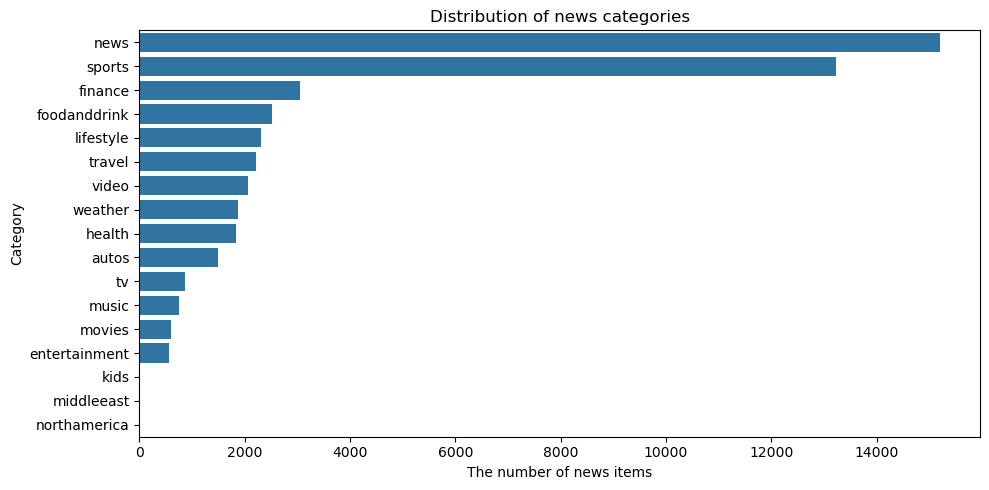

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 5))
sns.countplot(data=news_clean, y='Category', order=news_clean['Category'].value_counts().index)
plt.title('Distribution of news categories')
plt.xlabel('The number of news items')
plt.ylabel('Category')
plt.tight_layout()
plt.show()

/tmp/ipykernel_57496/1120320366.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_subcat.values, y=top_subcat.index, palette='cubehelix')


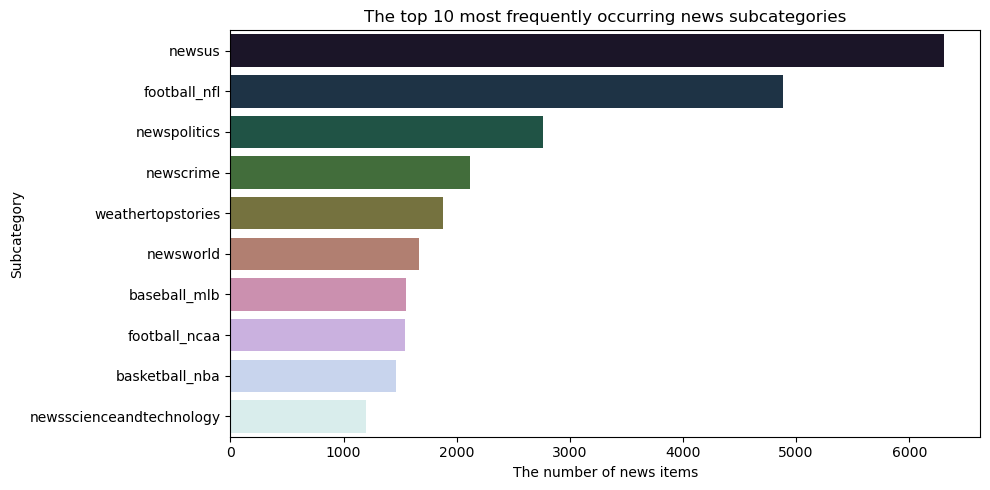

In [14]:
top_subcat = news_clean['SubCategory'].value_counts().head(10)

plt.figure(figsize=(10, 5))
sns.barplot(x=top_subcat.values, y=top_subcat.index, palette='cubehelix')
plt.title('The top 10 most frequently occurring news subcategories')
plt.xlabel('The number of news items')
plt.ylabel('Subcategory')
plt.tight_layout()
plt.show()

/tmp/ipykernel_57496/3542252221.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  news_clean['title_length'] = news_clean['Title'].apply(lambda x: len(str(x).split()))
/tmp/ipykernel_57496/3542252221.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  news_clean['abstract_length'] = news_clean['Abstract'].apply(lambda x: len(str(x).split()))


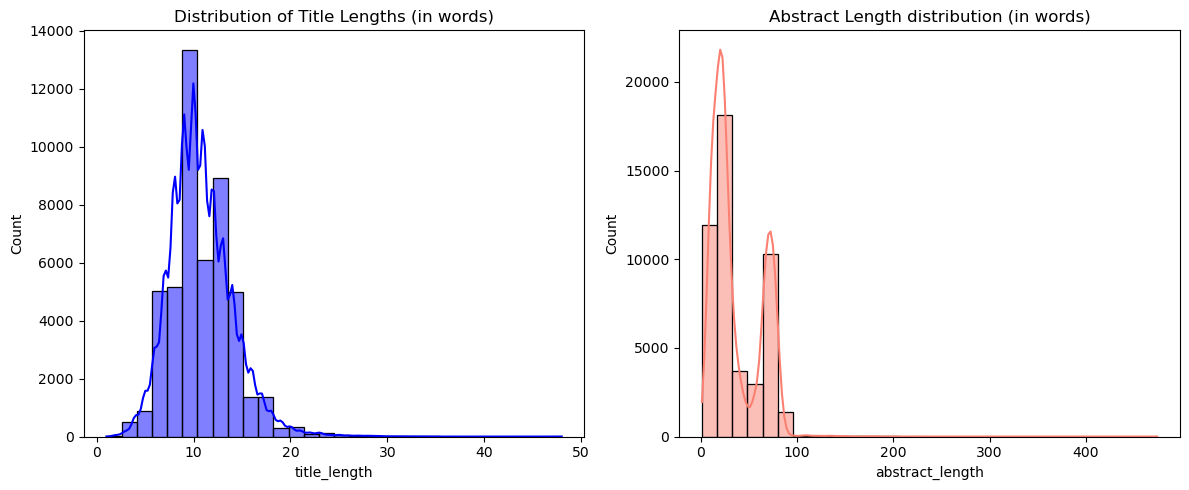

In [15]:
news_clean['title_length'] = news_clean['Title'].apply(lambda x: len(str(x).split()))
news_clean['abstract_length'] = news_clean['Abstract'].apply(lambda x: len(str(x).split()))

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.histplot(news_clean['title_length'], bins=30, kde=True, color='blue')
plt.title('Distribution of Title Lengths (in words)')

plt.subplot(1, 2, 2)
sns.histplot(news_clean['abstract_length'], bins=30, kde=True, color='salmon')
plt.title('Abstract Length distribution (in words)')

plt.tight_layout()
plt.show()

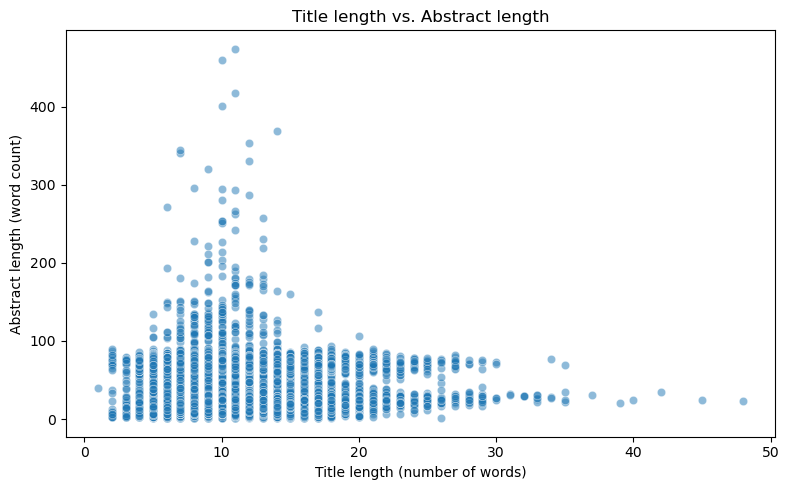

In [16]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=news_clean, x='title_length', y='abstract_length', alpha=0.5)
plt.title('Title length vs. Abstract length')
plt.xlabel('Title length (number of words)')
plt.ylabel('Abstract length (word count)')
plt.tight_layout()
plt.show()

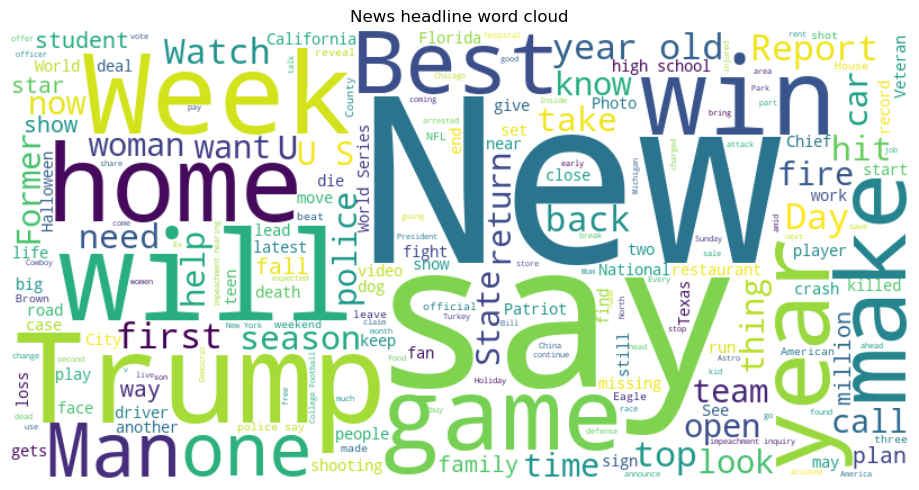

In [17]:
from wordcloud import WordCloud

text_all_titles = ' '.join(news_clean['Title'].dropna())
wordcloud = WordCloud(width=800, height=400, background_color='white', colormap='viridis').generate(text_all_titles)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('News headline word cloud')
plt.tight_layout()
plt.show()

### 2.2.2 EDA of user behaviour data

User's historical click-through count

count    153727.000000
mean         33.225387
std          40.408679
min           1.000000
25%           8.000000
50%          20.000000
75%          43.000000
max         558.000000
Name: history_len, dtype: float64


/tmp/ipykernel_57496/374645258.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  behaviors_clean['history_len'] = behaviors_clean['History'].fillna('').apply(lambda x: len(x.split()) if x else 0)


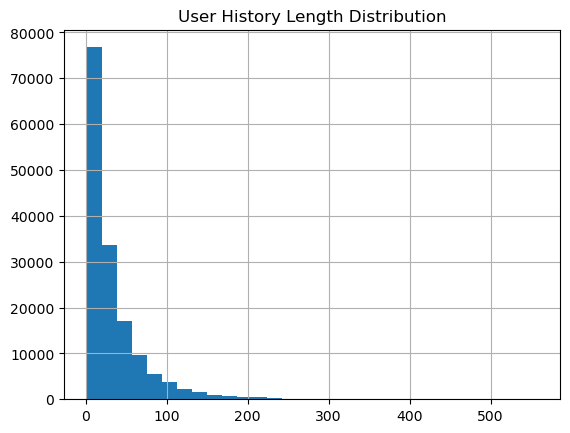

In [18]:
behaviors_clean['history_len'] = behaviors_clean['History'].fillna('').apply(lambda x: len(x.split()) if x else 0)
print(behaviors_clean['history_len'].describe())

behaviors_clean['history_len'].hist(bins=30)
plt.title('User History Length Distribution')
plt.show()


The number of impressions of news each time

count    153727.000000
mean         37.228346
std          38.575186
min           2.000000
25%          10.000000
50%          24.000000
75%          51.000000
max         299.000000
Name: impr_num, dtype: float64


/tmp/ipykernel_57496/1653376557.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  behaviors_clean['impr_num'] = behaviors_clean['Impressions'].apply(lambda x: len(x.split()))


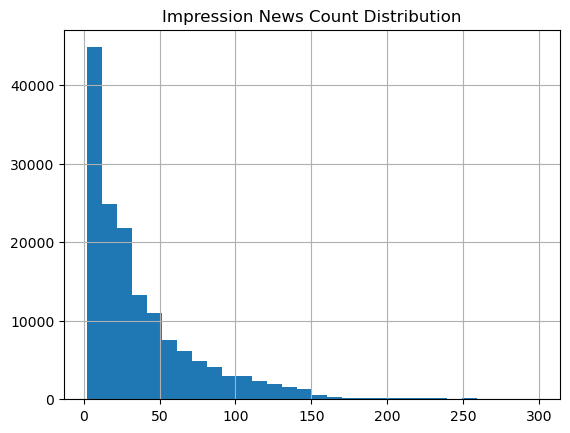

In [19]:
behaviors_clean['impr_num'] = behaviors_clean['Impressions'].apply(lambda x: len(x.split()))
print(behaviors_clean['impr_num'].describe())

behaviors_clean['impr_num'].hist(bins=30)
plt.title('Impression News Count Distribution')
plt.show()


the click-through rate per exposure

In [20]:
def get_ctr(imp_str):
    if pd.isna(imp_str): return 0
    return sum(int(i.split('-')[1]) for i in imp_str.split()) / len(imp_str.split())

behaviors_clean['impr_ctr'] = behaviors_clean['Impressions'].apply(get_ctr)
print(behaviors_clean['impr_ctr'].describe())

count    153727.000000
mean          0.108548
std           0.129526
min           0.003367
25%           0.028571
50%           0.055556
75%           0.125000
max           0.750000
Name: impr_ctr, dtype: float64


/tmp/ipykernel_57496/3929120853.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  behaviors_clean['impr_ctr'] = behaviors_clean['Impressions'].apply(get_ctr)


/tmp/ipykernel_57496/2884965371.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  behaviors_clean['ctr_bin'] = pd.cut(behaviors_clean['impr_ctr'], bins=bins, labels=labels, include_lowest=True)


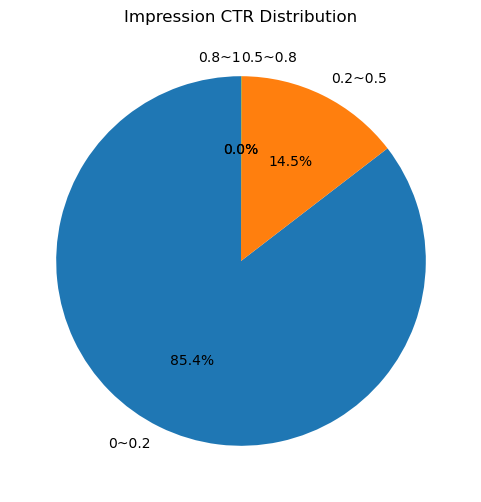

In [21]:
import matplotlib.pyplot as plt

# bin behaviours
bins = [0, 0.2, 0.5, 0.8, 1]
labels = ['0~0.2', '0.2~0.5', '0.5~0.8', '0.8~1']
behaviors_clean['ctr_bin'] = pd.cut(behaviors_clean['impr_ctr'], bins=bins, labels=labels, include_lowest=True)

bin_counts = behaviors_clean['ctr_bin'].value_counts().sort_index()

# plot
plt.figure(figsize=(6, 6))
plt.pie(bin_counts, labels=bin_counts.index, autopct='%1.1f%%', startangle=90)
plt.title('Impression CTR Distribution')
plt.show()


#### explainations

1. **Distribution of News categories**
- Dominant categories: **news** and **sports**
The data distribution is unbalanced
Niche categories (such as *kids*, *middleeast*) belong to the ** long-tail distribution **

2. **Top-10 Subcategories **
The subcategories **newsus**, **football_nfl**, and **baseball_mlb** have the highest occurrence frequency
The *news* category has a high degree of diversity: demonstrating the potential for ** more fine-grained personalized recommendations **

3. Title and Abstract Length
- **Title** : Most are 10 to 15 words
- **Abstract** : Most are 30 to 100 words
For using "TF-IDF" to represent text features, such a length is already quite informative

4. Scatter plot of the lengths of the title and abstract
- No strong correlation: This indicates that the Title and Abstract are complementary information
Support merging the two into 'full_text' as a **joint input feature**

5. "Word Cloud Analysis of News Headlines
- the most common words include: "Trump", "New ", "say", "game", "week"
- The displayed news focuses on politics and sports, which can serve as a basis for themes or entity-level features

## 3. Feature Engineering & Data-preprocessing

### 3.1 Feature Extraction`full_text`

In [22]:
news_clean['full_text'] = news_clean['Title'] + '. ' + news_clean['Abstract']
display(news_clean[['News_ID', 'Category', 'full_text']].head(3))

/tmp/ipykernel_57496/729367934.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  news_clean['full_text'] = news_clean['Title'] + '. ' + news_clean['Abstract']


,News_ID,Category,full_text
0,N55528,lifestyle,"The Brands Queen Elizabeth, Prince Charles, an..."
1,N19639,health,50 Worst Habits For Belly Fat. These seemingly...
2,N61837,news,The Cost of Trump's Aid Freeze in the Trenches...


#### 3.2 data clearning

In [23]:
import nltk
import re
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import PorterStemmer

nltk.download('stopwords')
nltk.download('punkt_tab')
nltk.download('punkt')
ps = PorterStemmer()
stop_words = set(stopwords.words('english'))

def preprocess_text(text):
    text = text.lower()
    text = re.sub(r'\s+', ' ', text)
    text=re.sub(r"[^\w\s'\-]", ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()                # Remove extra spaces
    tokens = word_tokenize(text)
    tokens = [word for word in tokens if word not in stop_words]
    tokens = [ps.stem(word) for word in tokens]
    return ' '.join(tokens)

news_clean['full_text_clean'] = news_clean['full_text'].apply(preprocess_text)

[nltk_data] Downloading package stopwords to /home/raymo/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to /home/raymo/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package punkt to /home/raymo/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
/tmp/ipykernel_57496/139281858.py:23: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  news_clean['full_text_clean'] = news_clean['full_text'].apply(preprocess_text)


In [24]:
selected_columns = ['News_ID', 'Category', 'SubCategory', 'Title', 'Abstract', 'full_text_clean']
df_selected = news_clean[selected_columns]

In [25]:
df_selected

,News_ID,Category,SubCategory,Title,Abstract,full_text_clean
0,N55528,lifestyle,lifestyleroyals,"The Brands Queen Elizabeth, Prince Charles, an...","Shop the notebooks, jackets, and more that the...",brand queen elizabeth princ charl princ philip...
1,N19639,health,weightloss,50 Worst Habits For Belly Fat,These seemingly harmless habits are holding yo...,50 worst habit belli fat seemingli harmless ha...
2,N61837,news,newsworld,The Cost of Trump's Aid Freeze in the Trenches...,Lt. Ivan Molchanets peeked over a parapet of s...,cost trump 's aid freez trench ukrain 's war l...
3,N53526,health,voices,I Was An NBA Wife. Here's How It Affected My M...,"I felt like I was a fraud, and being an NBA wi...",nba wife 's affect mental health felt like fra...
4,N38324,health,medical,"How to Get Rid of Skin Tags, According to a De...","They seem harmless, but there's a very good re...",get rid skin tag accord dermatologist seem har...
...,...,...,...,...,...,...
51275,N17258,news,newsscienceandtechnology,Realme takes chunk of India mobile market as S...,Over 400 percent more phones shipped year-on-year,realm take chunk india mobil market samsung sl...
51276,N23858,sports,golf,Young Northeast Florida fans flock to U.S. wom...,When the U.S. women's national soccer team arr...,young northeast florida fan flock u women 's s...
51277,N16909,weather,weathertopstories,"Adapting, Learning And Soul Searching: Reflect...",Woolsey Fire Anniversary: A community is forev...,adapt learn soul search reflect woolsey fire w...
51279,N7482,sports,more_sports,St. Dominic soccer player tries to kick cancer...,"Sometimes, what happens on the sidelines can b...",st domin soccer player tri kick cancer curb so...


In [26]:
news_clean

,News_ID,Category,SubCategory,Title,Abstract,URL,Title_Entities,Abstract_Entities,title_length,abstract_length,full_text,full_text_clean
0,N55528,lifestyle,lifestyleroyals,"The Brands Queen Elizabeth, Prince Charles, an...","Shop the notebooks, jackets, and more that the...",https://assets.msn.com/labs/mind/AAGH0ET.html,"[{""Label"": ""Prince Philip, Duke of Edinburgh"",...",[],11,12,"The Brands Queen Elizabeth, Prince Charles, an...",brand queen elizabeth princ charl princ philip...
1,N19639,health,weightloss,50 Worst Habits For Belly Fat,These seemingly harmless habits are holding yo...,https://assets.msn.com/labs/mind/AAB19MK.html,"[{""Label"": ""Adipose tissue"", ""Type"": ""C"", ""Wik...","[{""Label"": ""Adipose tissue"", ""Type"": ""C"", ""Wik...",6,19,50 Worst Habits For Belly Fat. These seemingly...,50 worst habit belli fat seemingli harmless ha...
2,N61837,news,newsworld,The Cost of Trump's Aid Freeze in the Trenches...,Lt. Ivan Molchanets peeked over a parapet of s...,https://assets.msn.com/labs/mind/AAJgNsz.html,[],"[{""Label"": ""Ukraine"", ""Type"": ""G"", ""WikidataId...",12,36,The Cost of Trump's Aid Freeze in the Trenches...,cost trump 's aid freez trench ukrain 's war l...
3,N53526,health,voices,I Was An NBA Wife. Here's How It Affected My M...,"I felt like I was a fraud, and being an NBA wi...",https://assets.msn.com/labs/mind/AACk2N6.html,[],"[{""Label"": ""National Basketball Association"", ...",12,21,I Was An NBA Wife. Here's How It Affected My M...,nba wife 's affect mental health felt like fra...
4,N38324,health,medical,"How to Get Rid of Skin Tags, According to a De...","They seem harmless, but there's a very good re...",https://assets.msn.com/labs/mind/AAAKEkt.html,"[{""Label"": ""Skin tag"", ""Type"": ""C"", ""WikidataI...","[{""Label"": ""Skin tag"", ""Type"": ""C"", ""WikidataI...",11,31,"How to Get Rid of Skin Tags, According to a De...",get rid skin tag accord dermatologist seem har...
...,...,...,...,...,...,...,...,...,...,...,...,...
51275,N17258,news,newsscienceandtechnology,Realme takes chunk of India mobile market as S...,Over 400 percent more phones shipped year-on-year,https://assets.msn.com/labs/mind/BBWzDfx.html,"[{""Label"": ""Realme"", ""Type"": ""N"", ""WikidataId""...",[],10,7,Realme takes chunk of India mobile market as S...,realm take chunk india mobil market samsung sl...
51276,N23858,sports,golf,Young Northeast Florida fans flock to U.S. wom...,When the U.S. women's national soccer team arr...,https://assets.msn.com/labs/mind/BBWzQB8.html,"[{""Label"": ""First Coast"", ""Type"": ""G"", ""Wikida...","[{""Label"": ""United States women's national soc...",9,68,Young Northeast Florida fans flock to U.S. wom...,young northeast florida fan flock u women 's s...
51277,N16909,weather,weathertopstories,"Adapting, Learning And Soul Searching: Reflect...",Woolsey Fire Anniversary: A community is forev...,https://assets.msn.com/labs/mind/BBWzQJK.html,"[{""Label"": ""Woolsey Fire"", ""Type"": ""N"", ""Wikid...","[{""Label"": ""Woolsey Fire"", ""Type"": ""N"", ""Wikid...",9,22,"Adapting, Learning And Soul Searching: Reflect...",adapt learn soul search reflect woolsey fire w...
51279,N7482,sports,more_sports,St. Dominic soccer player tries to kick cancer...,"Sometimes, what happens on the sidelines can b...",https://assets.msn.com/labs/mind/BBWzQnK.html,[],[],11,77,St. Dominic soccer player tries to kick cancer...,st domin soccer player tri kick cancer curb so...


The design purpose of this merge operation is to combine the brief information (title) with the more complete information (summary) as the input representation in the TF-IDF model. This step is very common in content-based recommendation systems because it can enhance semantic context (Ramos, 2003).

### 3.2. Create interactive df

For the Collaborative Filtering approach, an explicit data structure is required, consisting of User_ID, News_ID, and Label pairs (1 for clicked, 0 for not clicked).
This data is constructed by parsing the Impressions column from the behaviors_clean dataset.

In [27]:
interactions_flat = []

for row in behaviors_clean.itertuples(index=False):  
    user_id = row.User_ID
    impressions = row.Impressions.split()
    for impression in impressions:
        if '-' in impression:
            news_id, label = impression.rsplit('-', 1)
            interactions_flat.append((user_id, news_id, int(label)))

interactions_df = pd.DataFrame(interactions_flat, columns=['User_ID', 'News_ID', 'Label'])
print("Total interactions:", len(interactions_df))


Total interactions: 5723002


In [28]:
interactions_df

,User_ID,News_ID,Label
0,U13740,N55689,1
1,U13740,N35729,0
2,U91836,N20678,0
3,U91836,N39317,0
4,U91836,N58114,0
...,...,...,...
5722997,U44625,N39317,0
5722998,U64800,N61233,0
5722999,U64800,N33828,1
5723000,U64800,N19661,0


In [29]:
interactions_df.groupby('Label')['Label'].value_counts()

Label
0    5491472
1     231530
Name: count, dtype: int64

In [30]:
news_category = news_clean[['News_ID', 'Category']]
interactions_df = interactions_df.merge(news_category, on='News_ID', how='left')


In [31]:
interactions_df.head()

,User_ID,News_ID,Label,Category
0,U13740,N55689,1,sports
1,U13740,N35729,0,news
2,U91836,N20678,0,sports
3,U91836,N39317,0,news
4,U91836,N58114,0,NaN


### 3.3. TF-IDF Feature Extraction

As a feature for Content-Based Filtering, text representation is extracted using the TF-IDF (Term Frequency–Inverse Document Frequency) method, which considers word importance based on both local and global occurrence.

### 3.4. Label Encoding for Collaborative Filtering

In [32]:
user_encoder = LabelEncoder()
news_encoder = LabelEncoder()

interactions_df['user_encoded'] = user_encoder.fit_transform(interactions_df['User_ID'])
interactions_df['news_encoded'] = news_encoder.fit_transform(interactions_df['News_ID'])

num_users = interactions_df['user_encoded'].nunique()
num_items = interactions_df['news_encoded'].nunique()

print(f"Number of unique users: {num_users}")
print(f"Number of unique news items: {num_items}")

Number of unique users: 49108
Number of unique news items: 20252


In [33]:
interactions_df

,User_ID,News_ID,Label,Category,user_encoded,news_encoded
0,U13740,N55689,1,sports,2201,15659
1,U13740,N35729,0,news,2201,8792
2,U91836,N20678,0,sports,47474,3670
3,U91836,N39317,0,news,47474,10061
4,U91836,N58114,0,NaN,47474,16502
...,...,...,...,...,...,...
5722997,U44625,N39317,0,news,20012,10061
5722998,U64800,N61233,0,weather,31669,17625
5722999,U64800,N33828,1,movies,31669,8140
5723000,U64800,N19661,0,news,31669,3330


#### Notes:
Encoding:
- Specific to the architecture of the Collaborative Filtering model
- Encoding depends on the number and distribution of users and items

### 3.5. Data Splitting for Train-Test (training model)

In [34]:
X = interactions_df[['user_encoded', 'news_encoded']]
y = interactions_df['Label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42)

Stratified sampling is conducted according to the category ratio of y to ensure that the ratio of positive and negative samples (such as clicked and unclicked) in the training set and the test set remains consistent.

In [35]:
X_train, y_train

(         user_encoded  news_encoded
 3096247         36835          8081
 3421183         34182          5319
 4427003          6382         17181
 3083783         21848         15169
 2205544         27269         11868
 ...               ...           ...
 5052751          6796         13639
 2466162          2459          3527
 4767759         26459         12484
 152220          47161          3464
 4509053         15867         15321
 
 [4578401 rows x 2 columns],
 3096247    0
 3421183    0
 4427003    0
 3083783    0
 2205544    0
           ..
 5052751    0
 2466162    0
 4767759    0
 152220     0
 4509053    0
 Name: Label, Length: 4578401, dtype: int64)

## 4. Experiment

### 4.1. Content Based Filtering - TF-IDF

The Content-Based Filtering approach recommends news based on content similarity between articles, without taking into account the behavior of other users.
News content is represented by transforming the combined text of Title + Abstract into a fixed-dimensional TF-IDF vector.
Then, a k-Nearest Neighbors (k-NN) algorithm based on cosine similarity is used to find the most similar news articles.

In [ ]:
import numpy as np
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import roc_auc_score

# Assuming news and behaviors dataframes are loaded as news_clean and behaviors_clean
# Add full_text_clean column by concatenating Title and Abstract
news_clean['full_text_clean'] = news_clean['Title'] + ' ' + news_clean['Abstract']

# Convert Time to datetime
behaviors_clean['Time'] = pd.to_datetime(behaviors_clean['Time'])

# Sort by Time
behaviors_clean = behaviors_clean.sort_values('Time').reset_index(drop=True)

# Get min and max time
min_time = behaviors_clean['Time'].min()
max_time = behaviors_clean['Time'].max()

# Train end: min_time + 4 weeks
train_end = min_time + pd.Timedelta(weeks=4)

# Test start: max_time - 4 weeks
test_start = max_time - pd.Timedelta(weeks=4)

# Train df: Time <= train_end
train_df = behaviors_clean[behaviors_clean['Time'] <= train_end].copy()

# Test df: Time >= test_start
test_df = behaviors_clean[behaviors_clean['Time'] >= test_start].copy()

# Note: If total span < 8 weeks, there may be overlap; if >8 weeks, middle unused

# Hyperparameter range
feature_range = [1000,3000, 5000, 7000]
K = 10
results = []

# newsid2idx for quick lookup
newsid2idx = {nid: i for i, nid in enumerate(news_clean['News_ID'])}

# User profile function
def get_user_profile(history_list, tfidf_matrix):
    indices = [newsid2idx[nid] for nid in history_list if nid in newsid2idx]
    if not indices:
        return np.zeros((tfidf_matrix.shape[1],))
    return tfidf_matrix[indices].mean(axis=0).A1

# Recommend function (now also returns similarities for AUC)
def recommend_for_row(row, K, tfidf_matrix):
    history = row['History'].split() if pd.notna(row['History']) else []
    user_vec = get_user_profile(history, tfidf_matrix).reshape(1, -1)
    impression_items = row['Impressions'].split()
    candidates = [item.split('-')[0] for item in impression_items]
    labels = [1 if item.endswith('-1') else 0 for item in impression_items]  # 0 or 1 labels
    candidate_idxs = [newsid2idx[nid] for nid in candidates if nid in newsid2idx]
    if not candidate_idxs:
        return [], [], []
    candidate_vecs = tfidf_matrix[candidate_idxs]
    sims = cosine_similarity(user_vec, candidate_vecs).flatten()
    topk_idx = np.argsort(sims)[-K:][::-1]
    recs = [candidates[i] for i in topk_idx]
    # Filter labels and sims to match candidates (assuming all candidates are in newsid2idx)
    filtered_labels = [labels[i] for i in range(len(candidates)) if candidates[i] in newsid2idx]
    filtered_sims = sims
    return recs, filtered_sims, filtered_labels

# Evaluation functions
def calc_precision(row, K):
    actual = set([i.split('-')[0] for i in row['Impressions'].split() if i.endswith('-1')])
    recs = row['cb_recommend'][:K] if isinstance(row['cb_recommend'], list) else []
    return sum(1 for nid in recs if nid in actual) / K if recs else 0

def calc_recall(row, K):
    actual = set([i.split('-')[0] for i in row['Impressions'].split() if i.endswith('-1')])
    recs = row['cb_recommend'][:K] if isinstance(row['cb_recommend'], list) else []
    if not actual:
        return 0
    return sum(1 for nid in recs if nid in actual) / len(actual)

def calc_mrr(row, K):
    actual = set([i.split('-')[0] for i in row['Impressions'].split() if i.endswith('-1')])
    recs = row['cb_recommend'][:K] if isinstance(row['cb_recommend'], list) else []
    for idx, nid in enumerate(recs, 1):
        if nid in actual:
            return 1 / idx
    return 0

def calc_ndcg(row, K):
    actual = set([i.split('-')[0] for i in row['Impressions'].split() if i.endswith('-1')])
    recs = row['cb_recommend'][:K] if isinstance(row['cb_recommend'], list) else []
    dcg = sum(1 / np.log2(i + 2) for i, nid in enumerate(recs) if nid in actual)
    idcg = sum(1 / np.log2(i + 2) for i in range(min(len(actual), K)))
    return dcg / idcg if idcg > 0 else 0

def calc_hit_rate(row, K):
    actual = set([i.split('-')[0] for i in row['Impressions'].split() if i.endswith('-1')])
    recs = row['cb_recommend'][:K] if isinstance(row['cb_recommend'], list) else []
    return 1 if any(nid in actual for nid in recs) else 0

def calc_auc(row):
    sims = row['sims']
    labels = row['labels']
    if len(set(labels)) < 2:  # Need both classes for AUC
        return 0.5  
    try:
        return roc_auc_score(labels, sims)
    except:
        return 0.5

# Function to evaluate a dataframe for a given tfidf_matrix
def evaluate_df(df, tfidf_matrix, K):
    # Generate recommendations, sims, labels
    df[['cb_recommend', 'sims', 'labels']] = df.apply(
        lambda row: pd.Series(recommend_for_row(row, K, tfidf_matrix)), axis=1
    )
    
    # Calculate metrics
    df['precision'] = df.apply(lambda row: calc_precision(row, K), axis=1)
    df['recall'] = df.apply(lambda row: calc_recall(row, K), axis=1)
    df['mrr'] = df.apply(lambda row: calc_mrr(row, K), axis=1)
    df['ndcg'] = df.apply(lambda row: calc_ndcg(row, K), axis=1)
    df['hit_rate'] = df.apply(lambda row: calc_hit_rate(row, K), axis=1)
    df['auc'] = df.apply(calc_auc, axis=1)
    
    # Compute means
    results = {
        'precision@10': df['precision'].mean(),
        'recall@10': df['recall'].mean(),
        'mrr@10': df['mrr'].mean(),
        'ndcg@10': df['ndcg'].mean(),
        'hit_rate@10': df['hit_rate'].mean(),
        'auc': df['auc'].mean()
    }
    return results

# Tune on train
for max_f in feature_range:
    print(f"\n Testing max_features = {max_f}")
    
    vectorizer = TfidfVectorizer(max_features=max_f)
    tfidf_matrix = vectorizer.fit_transform(news_clean['full_text_clean'])
    
    train_results = evaluate_df(train_df, tfidf_matrix, K)
    
    results.append({
        'max_features': max_f,
        **train_results
    })

results_df = pd.DataFrame(results)
best_row = results_df.sort_values(by='ndcg@10', ascending=False).iloc[0]

print("\nAll results on train:")
print(results_df)

print(f"\nBest max_features found on train: {best_row['max_features']} with:")
for metric in ['precision@10', 'recall@10', 'mrr@10', 'ndcg@10', 'hit_rate@10', 'auc']:
    print(f" - {metric.capitalize()}: {best_row[metric]:.4f}")

# Evaluate on test with best
best_max_f = int(best_row['max_features'])
print(f"\nEvaluating best max_features ({best_max_f}) on test set")

vectorizer = TfidfVectorizer(max_features=best_max_f)
tfidf_matrix = vectorizer.fit_transform(news_clean['full_text_clean'])

test_results = evaluate_df(test_df, tfidf_matrix, K)

print(f"\nTest set results:")
for metric, value in test_results.items():
    print(f" - {metric.capitalize()}: {value:.4f}")

/tmp/ipykernel_2398/3593379677.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  news_clean['full_text_clean'] = news_clean['Title'] + ' ' + news_clean['Abstract']
/tmp/ipykernel_2398/3593379677.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  behaviors_clean['Time'] = pd.to_datetime(behaviors_clean['Time'])



 Testing max_features = 1000

 Testing max_features = 3000

 Testing max_features = 5000

 Testing max_features = 7000

All results on train:
   max_features  precision@10  recall@10    mrr@10   ndcg@10  hit_rate@10  \
0          1000      0.064507   0.516966  0.247759  0.301090     0.581310   
1          3000      0.065620   0.524174  0.258166  0.310066     0.589675   
2          5000      0.065692   0.524740  0.259183  0.310815     0.590352   
3          7000      0.065777   0.525474  0.260479  0.311919     0.591087   

        auc  
0  0.537427  
1  0.553457  
2  0.554595  
3  0.556844  

Best max_features found on train: 7000.0 with:
 - Precision@10: 0.0658
 - Recall@10: 0.5255
 - Mrr@10: 0.2605
 - Ndcg@10: 0.3119
 - Hit_rate@10: 0.5911
 - Auc: 0.5568

Evaluating best max_features (7000) on test set

Test set results:
 - Precision@10: 0.0658
 - Recall@10: 0.5255
 - Mrr@10: 0.2605
 - Ndcg@10: 0.3119
 - Hit_rate@10: 0.5911
 - Auc: 0.5568


### Content Base - Bert

In [ ]:
import numpy as np
import pandas as pd
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import roc_auc_score
from transformers import BertTokenizer, BertModel
import torch
from tqdm.std import tqdm

# Assuming news and behaviors dataframes are loaded as news_clean and behaviors_clean

# Convert Time to datetime
behaviors_clean['Time'] = pd.to_datetime(behaviors_clean['Time'])

# Sort by Time
behaviors_clean = behaviors_clean.sort_values('Time').reset_index(drop=True)

# Get min and max time
min_time = behaviors_clean['Time'].min()
max_time = behaviors_clean['Time'].max()

# Train end: min_time + 4 weeks
train_end = min_time + pd.Timedelta(weeks=4)

# Test start: max_time - 4 weeks
test_start = max_time - pd.Timedelta(weeks=4)

# Train df: Time <= train_end
train_df = behaviors_clean[behaviors_clean['Time'] <= train_end].copy()

# Test df: Time >= test_start
test_df = behaviors_clean[behaviors_clean['Time'] >= test_start].copy()

# Note: If total span < 8 weeks, there may be overlap; if >8 weeks, middle unused

# Device setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# Load BERT tokenizer and model
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
bert_model = BertModel.from_pretrained('bert-base-uncased')
bert_model.eval()
bert_model.to(device)

# Prepare texts: Title + Abstract
texts = (news_clean['Title'].fillna('') + ' ' + news_clean['Abstract'].fillna('')).tolist()

# Function to get BERT CLS embeddings
def get_bert_cls_embeddings(texts, batch_size=32, max_len=128):
    embeddings = []
    for i in tqdm(range(0, len(texts), batch_size)):
        batch_texts = texts[i:i+batch_size]
        inputs = tokenizer(batch_texts, padding=True, truncation=True, max_length=max_len, return_tensors='pt')
        inputs = {k: v.to(device) for k, v in inputs.items()}  # Use .to(device) instead of .cuda()
        with torch.no_grad():
            outputs = bert_model(**inputs)
            cls_vecs = outputs.last_hidden_state[:, 0, :]  # shape: (batch_size, 768)
        embeddings.append(cls_vecs.cpu().numpy())
    return np.vstack(embeddings)

# Generate BERT embeddings for all news
bert_news_embeddings = get_bert_cls_embeddings(texts)

K = 10

# newsid2idx for quick lookup
newsid2idx = {nid: i for i, nid in enumerate(news_clean['News_ID'])}

# User profile function
def get_user_profile(history_list, embeddings_matrix):
    indices = [newsid2idx[nid] for nid in history_list if nid in newsid2idx]
    if not indices:
        return np.zeros((embeddings_matrix.shape[1],))
    return np.mean(embeddings_matrix[indices], axis=0)

# Recommend function (now also returns similarities for AUC)
def recommend_for_row(row, K, embeddings_matrix):
    history = row['History'].split() if pd.notna(row['History']) else []
    user_vec = get_user_profile(history, embeddings_matrix).reshape(1, -1)
    impression_items = row['Impressions'].split()
    candidates = [item.split('-')[0] for item in impression_items]
    labels = [1 if item.endswith('-1') else 0 for item in impression_items]  # 0 or 1 labels
    candidate_idxs = [newsid2idx[nid] for nid in candidates if nid in newsid2idx]
    if not candidate_idxs:
        return [], [], []
    candidate_vecs = embeddings_matrix[candidate_idxs]
    sims = cosine_similarity(user_vec, candidate_vecs).flatten()
    topk_idx = np.argsort(sims)[-K:][::-1]
    recs = [candidates[i] for i in topk_idx]
    # Filter labels and sims to match candidates (assuming all candidates are in newsid2idx)
    filtered_labels = [labels[i] for i in range(len(candidates)) if candidates[i] in newsid2idx]
    filtered_sims = sims
    return recs, filtered_sims, filtered_labels

# Evaluation functions
def calc_precision(row, K):
    actual = set([i.split('-')[0] for i in row['Impressions'].split() if i.endswith('-1')])
    recs = row['cb_recommend'][:K] if isinstance(row['cb_recommend'], list) else []
    return sum(1 for nid in recs if nid in actual) / K if recs else 0

def calc_recall(row, K):
    actual = set([i.split('-')[0] for i in row['Impressions'].split() if i.endswith('-1')])
    recs = row['cb_recommend'][:K] if isinstance(row['cb_recommend'], list) else []
    if not actual:
        return 0
    return sum(1 for nid in recs if nid in actual) / len(actual)

def calc_mrr(row, K):
    actual = set([i.split('-')[0] for i in row['Impressions'].split() if i.endswith('-1')])
    recs = row['cb_recommend'][:K] if isinstance(row['cb_recommend'], list) else []
    for idx, nid in enumerate(recs, 1):
        if nid in actual:
            return 1 / idx
    return 0

def calc_ndcg(row, K):
    actual = set([i.split('-')[0] for i in row['Impressions'].split() if i.endswith('-1')])
    recs = row['cb_recommend'][:K] if isinstance(row['cb_recommend'], list) else []
    dcg = sum(1 / np.log2(i + 2) for i, nid in enumerate(recs) if nid in actual)
    idcg = sum(1 / np.log2(i + 2) for i in range(min(len(actual), K)))
    return dcg / idcg if idcg > 0 else 0

def calc_hit_rate(row, K):
    actual = set([i.split('-')[0] for i in row['Impressions'].split() if i.endswith('-1')])
    recs = row['cb_recommend'][:K] if isinstance(row['cb_recommend'], list) else []
    return 1 if any(nid in actual for nid in recs) else 0

def calc_auc(row):
    sims = row['sims']
    labels = row['labels']
    if len(set(labels)) < 2:  # Need both classes for AUC
        return 0.5  # Or np.nan, but for averaging, use 0.5
    try:
        return roc_auc_score(labels, sims)
    except:
        return 0.5

# Function to evaluate a dataframe
def evaluate_df(df, embeddings_matrix, K):
    # Generate recommendations, sims, labels
    df[['cb_recommend', 'sims', 'labels']] = df.apply(
        lambda row: pd.Series(recommend_for_row(row, K, embeddings_matrix)), axis=1
    )
    
    # Calculate metrics
    df['precision'] = df.apply(lambda row: calc_precision(row, K), axis=1)
    df['recall'] = df.apply(lambda row: calc_recall(row, K), axis=1)
    df['mrr'] = df.apply(lambda row: calc_mrr(row, K), axis=1)
    df['ndcg'] = df.apply(lambda row: calc_ndcg(row, K), axis=1)
    df['hit_rate'] = df.apply(lambda row: calc_hit_rate(row, K), axis=1)
    df['auc'] = df.apply(calc_auc, axis=1)
    
    # Compute means
    results = {
        'precision@10': df['precision'].mean(),
        'recall@10': df['recall'].mean(),
        'mrr@10': df['mrr'].mean(),
        'ndcg@10': df['ndcg'].mean(),
        'hit_rate@10': df['hit_rate'].mean(),
        'auc': df['auc'].mean()
    }
    return results

# Evaluate on train
print("\nEvaluating BERT on train set")
train_results = evaluate_df(train_df, bert_news_embeddings, K)

print(f"\nTrain set results:")
for metric, value in train_results.items():
    print(f" - {metric.capitalize()}: {value:.4f}")

# Evaluate on test
print("\nEvaluating BERT on test set")
test_results = evaluate_df(test_df, bert_news_embeddings, K)

print(f"\nTest set results:")
for metric, value in test_results.items():
    print(f" - {metric.capitalize()}: {value:.4f}")

Using device: cpu


100%|██████████| 1520/1520 [31:32<00:00,  1.25s/it]



Evaluating BERT on train set

Train set results:
 - Precision@10: 0.0648
 - Recall@10: 0.5190
 - Mrr@10: 0.2543
 - Ndcg@10: 0.3062
 - Hit_rate@10: 0.5840
 - Auc: 0.5478

Evaluating BERT on test set

Test set results:
 - Precision@10: 0.0648
 - Recall@10: 0.5190
 - Mrr@10: 0.2543
 - Ndcg@10: 0.3062
 - Hit_rate@10: 0.5840
 - Auc: 0.5478


### Content Base - sBERT

In [36]:
from sentence_transformers import SentenceTransformer
import numpy as np
import pandas as pd
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import roc_auc_score

# Add full_text_clean column by concatenating Title and Abstract
news_clean['full_text_clean'] = news_clean['Title'] + ' ' + news_clean['Abstract']

# Convert Time to datetime
behaviors_clean['Time'] = pd.to_datetime(behaviors_clean['Time'])

# Sort by Time
behaviors_clean = behaviors_clean.sort_values('Time').reset_index(drop=True)

# Get min and max time
min_time = behaviors_clean['Time'].min()
max_time = behaviors_clean['Time'].max()

# Train end: min_time + 4 weeks
train_end = min_time + pd.Timedelta(weeks=4)

# Test start: max_time - 4 weeks
test_start = max_time - pd.Timedelta(weeks=4)

# Train df: Time <= train_end
train_df = behaviors_clean[behaviors_clean['Time'] <= train_end].copy()

# Test df: Time >= test_start
test_df = behaviors_clean[behaviors_clean['Time'] >= test_start].copy()

# Load SentenceTransformer model
bert_model = SentenceTransformer('all-MiniLM-L6-v2')

# Obtain the vector of each piece of news
news_bert_embeddings = bert_model.encode(news_clean['full_text_clean'].tolist(), show_progress_bar=True)

K = 10

# newsid2idx for quick lookup
newsid2idx = {nid: i for i, nid in enumerate(news_clean['News_ID'])}

# User profile function
def get_user_profile_bert(history_list):
    indices = [newsid2idx[nid] for nid in history_list if nid in newsid2idx]
    if not indices:
        return np.zeros(news_bert_embeddings.shape[1])
    return news_bert_embeddings[indices].mean(axis=0)

# Aggregate history
user2history = behaviors_clean.groupby('User_ID')['History'].apply(lambda x: ' '.join(x.dropna())).to_dict()

# Obtain the user-level bert interest vector
user2profile_bert = {}
for user_id, history_str in user2history.items():
    history_list = history_str.split()
    user2profile_bert[user_id] = get_user_profile_bert(history_list)

# Recommend function (now also returns similarities for AUC)
def recommend_user_profile_bert(row, K=10):
    user_id = row['User_ID']
    user_vec = user2profile_bert.get(user_id, np.zeros(news_bert_embeddings.shape[1])).reshape(1, -1)
    impression_items = row['Impressions'].split()
    candidates = [item.split('-')[0] for item in impression_items]
    labels = [1 if item.endswith('-1') else 0 for item in impression_items]  # 0 or 1 labels
    candidate_idxs = [newsid2idx[nid] for nid in candidates if nid in newsid2idx]
    if not candidate_idxs:
        return [], [], []
    candidate_vecs = news_bert_embeddings[candidate_idxs]
    sims = cosine_similarity(user_vec, candidate_vecs).flatten()
    topk_idx = np.argsort(sims)[-K:][::-1]
    recs = [candidates[i] for i in topk_idx]
    # Filter labels and sims to match candidates
    filtered_labels = [labels[i] for i in range(len(candidates)) if candidates[i] in newsid2idx]
    filtered_sims = sims
    return recs, filtered_sims, filtered_labels

# Evaluation functions
def calc_precision(row, K):
    actual = set([i.split('-')[0] for i in row['Impressions'].split() if i.endswith('-1')])
    recs = row['bert_cb_recommend'][:K] if isinstance(row['bert_cb_recommend'], list) else []
    return sum(1 for nid in recs if nid in actual) / K if recs else 0

def calc_recall(row, K):
    actual = set([i.split('-')[0] for i in row['Impressions'].split() if i.endswith('-1')])
    recs = row['bert_cb_recommend'][:K] if isinstance(row['bert_cb_recommend'], list) else []
    if not actual:
        return 0
    return sum(1 for nid in recs if nid in actual) / len(actual)

def calc_mrr(row, K):
    actual = set([i.split('-')[0] for i in row['Impressions'].split() if i.endswith('-1')])
    recs = row['bert_cb_recommend'][:K] if isinstance(row['bert_cb_recommend'], list) else []
    for idx, nid in enumerate(recs, 1):
        if nid in actual:
            return 1 / idx
    return 0

def calc_ndcg(row, K):
    actual = set([i.split('-')[0] for i in row['Impressions'].split() if i.endswith('-1')])
    recs = row['bert_cb_recommend'][:K] if isinstance(row['bert_cb_recommend'], list) else []
    dcg = sum(1 / np.log2(i + 2) for i, nid in enumerate(recs) if nid in actual)
    idcg = sum(1 / np.log2(i + 2) for i in range(min(len(actual), K)))
    return dcg / idcg if idcg > 0 else 0

def calc_hit_rate(row, K):
    actual = set([i.split('-')[0] for i in row['Impressions'].split() if i.endswith('-1')])
    recs = row['bert_cb_recommend'][:K] if isinstance(row['bert_cb_recommend'], list) else []
    return 1 if any(nid in actual for nid in recs) else 0

def calc_auc(row):
    sims = row['sims']
    labels = row['labels']
    if len(set(labels)) < 2:  # Need both classes for AUC
        return 0.5  # Or np.nan, but for averaging, use 0.5
    try:
        return roc_auc_score(labels, sims)
    except:
        return 0.5

# Function to evaluate a dataframe
def evaluate_df(df, K):
    # Generate recommendations, sims, labels
    df[['bert_cb_recommend', 'sims', 'labels']] = df.apply(
        lambda row: pd.Series(recommend_user_profile_bert(row, K)), axis=1
    )
    
    # Calculate metrics
    df['precision'] = df.apply(lambda row: calc_precision(row, K), axis=1)
    df['recall'] = df.apply(lambda row: calc_recall(row, K), axis=1)
    df['mrr'] = df.apply(lambda row: calc_mrr(row, K), axis=1)
    df['ndcg'] = df.apply(lambda row: calc_ndcg(row, K), axis=1)
    df['hit_rate'] = df.apply(lambda row: calc_hit_rate(row, K), axis=1)
    df['auc'] = df.apply(calc_auc, axis=1)
    
    # Compute means
    results = {
        'precision@10': df['precision'].mean(),
        'recall@10': df['recall'].mean(),
        'mrr@10': df['mrr'].mean(),
        'ndcg@10': df['ndcg'].mean(),
        'hit_rate@10': df['hit_rate'].mean(),
        'auc': df['auc'].mean()
    }
    return results

# Evaluate on train
print("\nEvaluating SentenceBERT on train set")
train_results = evaluate_df(train_df, K)

print(f"\nTrain set results:")
for metric, value in train_results.items():
    print(f" - {metric.capitalize()}: {value:.4f}")

# Evaluate on test
print("\nEvaluating SentenceBERT on test set")
test_results = evaluate_df(test_df, K)

print(f"\nTest set results:")
for metric, value in test_results.items():
    print(f" - {metric.capitalize()}: {value:.4f}")

/tmp/ipykernel_57496/3343234852.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  news_clean['full_text_clean'] = news_clean['Title'] + ' ' + news_clean['Abstract']
/tmp/ipykernel_57496/3343234852.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  behaviors_clean['Time'] = pd.to_datetime(behaviors_clean['Time'])


Batches:   0%|          | 0/1520 [00:00<?, ?it/s]


Evaluating SentenceBERT on train set

Train set results:
 - Precision@10: 0.0698
 - Recall@10: 0.5520
 - Mrr@10: 0.2854
 - Ndcg@10: 0.3368
 - Hit_rate@10: 0.6192
 - Auc: 0.6252

Evaluating SentenceBERT on test set

Test set results:
 - Precision@10: 0.0698
 - Recall@10: 0.5520
 - Mrr@10: 0.2854
 - Ndcg@10: 0.3368
 - Hit_rate@10: 0.6192
 - Auc: 0.6252


### TFIDF+SBert

In [ ]:
import numpy as np
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import roc_auc_score
from tqdm.std import tqdm

# Assume that the two Dataframes, news_clean and behaviors_clean, have been preloaded
# Merge news headlines, summaries, and categories into one text field
news_clean['full_text_clean'] = news_clean['Title'] + '.' + news_clean['Abstract'] + "." + news_clean["Category"]

# Convert the time to the datetime type
behaviors_clean['Time'] = pd.to_datetime(behaviors_clean['Time'])

# Sort by time
behaviors_clean = behaviors_clean.sort_values('Time').reset_index(drop=True)

# Get the earliest and latest times
min_time = behaviors_clean['Time'].min()
max_time = behaviors_clean['Time'].max()

# The end time of the training set is the earliest time plus 5 weeks
train_end = min_time + pd.Timedelta(weeks=5)

# The start time of the test set is at the latest - 5 weeks
test_start = max_time - pd.Timedelta(weeks=5)

# Build the training set and the test set
train_df = behaviors_clean[behaviors_clean['Time'] <= train_end].copy()
test_df = behaviors_clean[behaviors_clean['Time'] >= test_start].copy()


# Define the number of TF-IDF features to be tested
feature_sizes = [100, 300, 500, 1000, 2000, 3000]
K = 10
results = []

# Construct the mapping from News_ID to the index
newsid2idx = {nid: i for i, nid in enumerate(news_clean['News_ID'])}

# Obtain the user profile vector
def get_user_profile(history_list, tfidf_matrix):
    indices = [newsid2idx[nid] for nid in history_list if nid in newsid2idx]
    if not indices:
        return np.zeros(tfidf_matrix.shape[1], dtype=float)
    return np.asarray(tfidf_matrix[indices].mean(axis=0)).ravel()

# Recommendation function (returns recommendation list, similarity, tags)
def recommend_for_row(row, K, tfidf_matrix):
    history = row['History'].split() if pd.notna(row['History']) else []
    user_vec = get_user_profile(history, tfidf_matrix).reshape(1, -1)
    impression_items = row['Impressions'].split()
    candidates = [item.split('-')[0] for item in impression_items]
    labels = [1 if item.endswith('-1') else 0 for item in impression_items]
    candidate_idxs = [newsid2idx[nid] for nid in candidates if nid in newsid2idx]
    if not candidate_idxs:
        return [], [], []
    candidate_vecs = tfidf_matrix[candidate_idxs].toarray()
    sims = cosine_similarity(user_vec, candidate_vecs).flatten()
    topk_idx = np.argsort(sims)[-K:][::-1]
    recs = [candidates[i] for i in topk_idx]
    filtered_labels = [labels[i] for i in range(len(candidates)) if candidates[i] in newsid2idx]
    return recs, sims, filtered_labels


def calc_precision(row, K):
    actual = set([i.split('-')[0] for i in row['Impressions'].split() if i.endswith('-1')])
    recs = row['cb_recommend'][:K] if isinstance(row['cb_recommend'], list) else []
    return sum(1 for nid in recs if nid in actual) / K if recs else 0

def calc_recall(row, K):
    actual = set([i.split('-')[0] for i in row['Impressions'].split() if i.endswith('-1')])
    recs = row['cb_recommend'][:K] if isinstance(row['cb_recommend'], list) else []
    if not actual:
        return 0
    return sum(1 for nid in recs if nid in actual) / len(actual)

def calc_mrr(row, K):
    actual = set([i.split('-')[0] for i in row['Impressions'].split() if i.endswith('-1')])
    recs = row['cb_recommend'][:K] if isinstance(row['cb_recommend'], list) else []
    for idx, nid in enumerate(recs, 1):
        if nid in actual:
            return 1 / idx
    return 0

def calc_ndcg(row, K):
    actual = set([i.split('-')[0] for i in row['Impressions'].split() if i.endswith('-1')])
    recs = row['cb_recommend'][:K] if isinstance(row['cb_recommend'], list) else []
    dcg = sum(1 / np.log2(i + 2) for i, nid in enumerate(recs) if nid in actual)
    idcg = sum(1 / np.log2(i + 2) for i in range(min(len(actual), K)))
    return dcg / idcg if idcg > 0 else 0

def calc_hit_rate(row, K):
    actual = set([i.split('-')[0] for i in row['Impressions'].split() if i.endswith('-1')])
    recs = row['cb_recommend'][:K] if isinstance(row['cb_recommend'], list) else []
    return 1 if any(nid in actual for nid in recs) else 0

def calc_auc(row):
    sims = row['sims']
    labels = row['labels']
    if len(set(labels)) < 2:
        return 0.5
    try:
        return roc_auc_score(labels, sims)
    except:
        return 0.5

def evaluate_df(df, tfidf_matrix, K):
    df[['cb_recommend', 'sims', 'labels']] = df.apply(
        lambda row: pd.Series(recommend_for_row(row, K, tfidf_matrix)), axis=1
    )
    df['precision'] = df.apply(lambda row: calc_precision(row, K), axis=1)
    df['recall'] = df.apply(lambda row: calc_recall(row, K), axis=1)
    df['mrr'] = df.apply(lambda row: calc_mrr(row, K), axis=1)
    df['ndcg'] = df.apply(lambda row: calc_ndcg(row, K), axis=1)
    df['hit_rate'] = df.apply(lambda row: calc_hit_rate(row, K), axis=1)
    df['auc'] = df.apply(calc_auc, axis=1)

    return {
        'precision@10': df['precision'].mean(),
        'recall@10': df['recall'].mean(),
        'mrr@10': df['mrr'].mean(),
        'ndcg@10': df['ndcg'].mean(),
        'hit_rate@10': df['hit_rate'].mean(),
        'auc': df['auc'].mean()
    }

for size in tqdm(feature_sizes):
    print(f"\n max_features = {size}")
    vectorizer = TfidfVectorizer(max_features=size)
    tfidf_matrix = vectorizer.fit_transform(news_clean['full_text_clean'].fillna(''))
    train_results = evaluate_df(train_df, tfidf_matrix, K)
    results.append({'max_features': size, **train_results})

results_df = pd.DataFrame(results)
best_row = results_df.sort_values(by='ndcg@10', ascending=False).iloc[0]

print("\nAll the results of the training set:")
print(results_df)

print(f"\nbest max_features: {best_row['max_features']},Corresponding indicators:")
for metric in ['precision@10', 'recall@10', 'mrr@10', 'ndcg@10', 'hit_rate@10', 'auc']:
    print(f" - {metric.capitalize()}: {best_row[metric]:.4f}")

best_max_f = best_row['max_features']
print(f"\n best max_features({best_max_f})Evaluate on the test set")
vectorizer = TfidfVectorizer(max_features=int(best_max_f))
tfidf_matrix = vectorizer.fit_transform(news_clean['full_text_clean'].fillna(''))
test_results = evaluate_df(test_df, tfidf_matrix, K)

print("\nEvaluation results of the test set:")
for metric, value in test_results.items():
    print(f" - {metric.capitalize()}: {value:.4f}")

news_content_feat = tfidf_matrix

def get_user_profile_fused(history_list):
    indices = [newsid2idx[nid] for nid in history_list if nid in newsid2idx]
    if not indices:
        return np.zeros(news_content_feat.shape[1], dtype=float)
    return np.asarray(news_content_feat[indices].mean(axis=0)).ravel()

def recommend_fused_cb(row, K=10):
    history = row['History'].split() if pd.notna(row['History']) else []
    user_vec = get_user_profile_fused(history).reshape(1, -1)
    impression_items = row['Impressions'].split()
    candidates = [item.split('-')[0] for item in impression_items]
    candidate_idxs = [newsid2idx[nid] for nid in candidates if nid in newsid2idx]
    if not candidate_idxs:
        return []
    candidate_vecs = news_content_feat[candidate_idxs].toarray()
    sims = cosine_similarity(user_vec, candidate_vecs).flatten()
    topk_idx = np.argsort(sims)[-K:][::-1]
    return [candidates[i] for i in topk_idx]

print("\nEvaluate fusion recommendations on the training set")
train_df['cb_recommend_fused'] = train_df.apply(lambda row: recommend_fused_cb(row, K), axis=1)
train_df[['cb_recommend', 'sims', 'labels']] = train_df.apply(
    lambda row: pd.Series(recommend_for_row(row, K, news_content_feat)), axis=1
)
train_df['precision_fused'] = train_df.apply(lambda row: calc_precision(row, K), axis=1)
train_df['recall_fused'] = train_df.apply(lambda row: calc_recall(row, K), axis=1)
train_df['mrr_fused'] = train_df.apply(lambda row: calc_mrr(row, K), axis=1)
train_df['ndcg_fused'] = train_df.apply(lambda row: calc_ndcg(row, K), axis=1)
train_df['hit_rate_fused'] = train_df.apply(lambda row: calc_hit_rate(row, K), axis=1)
train_df['auc_fused'] = train_df.apply(calc_auc, axis=1)

train_fused_results = {
    'precision@10': train_df['precision_fused'].mean(),
    'recall@10': train_df['recall_fused'].mean(),
    'mrr@10': train_df['mrr_fused'].mean(),
    'ndcg@10': train_df['ndcg_fused'].mean(),
    'hit_rate@10': train_df['hit_rate_fused'].mean(),
    'auc': train_df['auc_fused'].mean()
}

print("\nThe training set fuses the recommendation results:")
for metric, value in train_fused_results.items():
    print(f" - {metric.capitalize()}: {value:.4f}")

print("\nEvaluate the fusion recommendation on the test set")
test_df['cb_recommend_fused'] = test_df.apply(lambda row: recommend_fused_cb(row, K), axis=1)
test_df[['cb_recommend', 'sims', 'labels']] = test_df.apply(
    lambda row: pd.Series(recommend_for_row(row, K, news_content_feat)), axis=1
)
test_df['precision_fused'] = test_df.apply(lambda row: calc_precision(row, K), axis=1)
test_df['recall_fused'] = test_df.apply(lambda row: calc_recall(row, K), axis=1)
test_df['mrr_fused'] = test_df.apply(lambda row: calc_mrr(row, K), axis=1)
test_df['ndcg_fused'] = test_df.apply(lambda row: calc_ndcg(row, K), axis=1)
test_df['hit_rate_fused'] = test_df.apply(lambda row: calc_hit_rate(row, K), axis=1)
test_df['auc_fused'] = test_df.apply(calc_auc, axis=1)

test_fused_results = {
    'precision@10': test_df['precision_fused'].mean(),
    'recall@10': test_df['recall_fused'].mean(),
    'mrr@10': test_df['mrr_fused'].mean(),
    'ndcg@10': test_df['ndcg_fused'].mean(),
    'hit_rate@10': test_df['hit_rate_fused'].mean(),
    'auc': test_df['auc_fused'].mean()
}

print("\nThe test set fuses the recommendation results：")
for metric, value in test_fused_results.items():
    print(f" - {metric.capitalize()}: {value:.4f}")


/tmp/ipykernel_1250/2511561479.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  news_clean['full_text_clean'] = news_clean['Title'] + '.' + news_clean['Abstract'] + "." + news_clean["Category"]
  0%|          | 0/6 [00:00<?, ?it/s]


 max_features = 100


 17%|█▋        | 1/6 [03:21<16:46, 201.30s/it]


 max_features = 300


 33%|███▎      | 2/6 [06:45<13:31, 202.77s/it]

...


 max_features = 2000


 83%|████████▎ | 5/6 [17:49<03:39, 219.72s/it]


 max_features = 3000


100%|██████████| 6/6 [21:52<00:00, 218.69s/it]



All the results of the training set:
   max_features  precision@10  recall@10    mrr@10   ndcg@10  hit_rate@10  \
0           100      0.063482   0.509738  0.239282  0.293455     0.572834   
1           300      0.064641   0.517945  0.244314  0.298899     0.582266   
2           500      0.065086   0.520651  0.249559  0.303227     0.585421   
3          1000      0.065450   0.523532  0.253513  0.306816     0.588595   
4          2000      0.066108   0.528084  0.259593  0.312210     0.593481   
5          3000      0.066230   0.528365  0.261850  0.313765     0.594229   

        auc  
0  0.525891  
1  0.537526  
2  0.546102  
3  0.553156  
4  0.562726  
5  0.564812  

best max_features: 3000.0,Corresponding indicators:
 - Precision@10: 0.0662
 - Recall@10: 0.5284
 - Mrr@10: 0.2619
 - Ndcg@10: 0.3138
 - Hit_rate@10: 0.5942
 - Auc: 0.5648

 best max_features(3000.0)Evaluate on the test set

Evaluation results of the test set:
 - Precision@10: 0.0662
 - Recall@10: 0.5284
 - Mrr@10: 0.2619

In [39]:
def calc_precision_at_k(row, K=10):
    actual_clicks = set([i.split('-')[0] for i in row['Impressions'].split() if i.endswith('-1')])
    recs = row['cb_recommend_fused'][:K] if isinstance(row['cb_recommend_fused'], list) else []
    if not recs: return 0
    return sum([1 for r in recs if r in actual_clicks]) / K

def calc_recall_at_k(row, K=10):
    actual_clicks = set([i.split('-')[0] for i in row['Impressions'].split() if i.endswith('-1')])
    recs = row['cb_recommend_fused'][:K] if isinstance(row['cb_recommend_fused'], list) else []
    if not actual_clicks: return 0
    return sum([1 for r in recs if r in actual_clicks]) / len(actual_clicks)

def calc_mrr_at_k(row, K=10):
    actual_clicks = set([i.split('-')[0] for i in row['Impressions'].split() if i.endswith('-1')])
    recs = row['cb_recommend_fused'][:K] if isinstance(row['cb_recommend_fused'], list) else []
    for idx, nid in enumerate(recs, 1):
        if nid in actual_clicks:
            return 1.0 / idx
    return 0

def calc_ndcg_at_k(row, K=10):
    actual_clicks = set([i.split('-')[0] for i in row['Impressions'].split() if i.endswith('-1')])
    recs = row['cb_recommend_fused'][:K] if isinstance(row['cb_recommend_fused'], list) else []
    dcg = 0
    idcg = sum([1.0 / np.log2(i + 2) for i in range(min(len(actual_clicks), K))])
    for i, nid in enumerate(recs):
        if nid in actual_clicks:
            dcg += 1.0 / np.log2(i + 2)
    return dcg / idcg if idcg > 0 else 0

def calc_hit_at_k(row, K=10):
    actual_clicks = set([i.split('-')[0] for i in row['Impressions'].split() if i.endswith('-1')])
    recs = row['cb_recommend_fused'][:K] if isinstance(row['cb_recommend_fused'], list) else []
    return int(any(r in actual_clicks for r in recs))

def calc_auc_at_k(row, K=10):
    from sklearn.metrics import roc_auc_score
    impression_items = row['Impressions'].split()
    y_true = [int(i.endswith('-1')) for i in impression_items]
    item_ids = [i.split('-')[0] for i in impression_items]
    recs = row['cb_recommend_fused'][:K] if isinstance(row['cb_recommend_fused'], list) else []

    scores = [K - recs.index(i) if i in recs else 0 for i in item_ids]
    try:
        return roc_auc_score(y_true, scores)
    except:
        return 0


In [ ]:
behaviors_clean['precision@10_fused'] = behaviors_clean.apply(lambda row: calc_precision_at_k(row, K=10), axis=1)
behaviors_clean['recall@10_fused']   = behaviors_clean.apply(lambda row: calc_recall_at_k(row, K=10), axis=1)
behaviors_clean['mrr@10_fused']      = behaviors_clean.apply(lambda row: calc_mrr_at_k(row, K=10), axis=1)
behaviors_clean['ndcg@10_fused']     = behaviors_clean.apply(lambda row: calc_ndcg_at_k(row, K=10), axis=1)
behaviors_clean['hit@10_fused']      = behaviors_clean.apply(lambda row: calc_hit_at_k(row, K=10), axis=1)
behaviors_clean['auc@10_fused']      = behaviors_clean.apply(lambda row: calc_auc_at_k(row, K=10), axis=1)


print("Fused CB (TF-IDF+SBERT) Content Recommendation Results:")
print("Precision@10:", behaviors_clean['precision@10_fused'].mean())
print("Recall@10:   ", behaviors_clean['recall@10_fused'].mean())
print("MRR@10:      ", behaviors_clean['mrr@10_fused'].mean())
print("NDCG@10:     ", behaviors_clean['ndcg@10_fused'].mean())
print("Hit@10:      ", behaviors_clean['hit@10_fused'].mean())
print("AUC@10:      ", behaviors_clean['auc@10_fused'].mean())


Fused CB (TF-IDF+SBERT) Content Recommendation Results:
Precision@10: 0.06920059586149473
Recall@10:    0.5481638356354751
MRR@10:       0.2845042556888882
NDCG@10:      0.3350934727707562
Hit@10:       0.6151814580392514
AUC@10:       0.557237718128616


In the user-level content recall experiment of news recommendation, the performances of the two feature methods, TF-IDF and BERT, were very close. TF-IDF is slightly better than BERT in Precision@10 and MRR@10, and is roughly on par with Recall@10. This indicates that under the current dataset and recommendation strategy, the traditional keyword-driven TF-IDF still has a strong discrimination ability, especially in short text news and when users' interests are obvious. Although BERT has a stronger semantic modeling ability, its discrimination of news content is limited in unfine-tuned scenarios. Subsequently, the model effect can be further improved through methods such as behavior sequence enhancement and multimodal feature fusion.

### 4.3 Neural Collaborative Filtering

The goal of Collaborative Filtering (CF) is to predict a user's interest in a news item based on the interaction patterns of other users with the same item.
In this project, a Model-Based CF approach is used, employing a Neural Collaborative Filtering architecture built with pytorch.

The model utilizes embedding representations for users and items (news), which are then combined and passed through several dense layers to predict the probability of a click.

In [ ]:
import os, random
import numpy as np
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import roc_auc_score
from torch.utils.data import DataLoader, TensorDataset
import torch
import torch.nn as nn

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)



def explode_impressions(row):
    recs = []
    date = row.Time.date() 
    for item in row.Impressions.strip().split():
        nid, click = item.split('-')
        recs.append((row.User_ID, nid, int(click), date))
    return recs

interactions = pd.DataFrame(
    behaviors_clean.apply(explode_impressions, axis=1).explode().tolist(),
    columns=['User_ID', 'News_ID', 'Label', 'Time']
)
interactions['Time'] = pd.to_datetime(
    interactions['Time'], errors='coerce', infer_datetime_format=True
)
interactions = interactions.dropna(subset=['Time'])
print('Total interactions =', len(interactions))


unique_dates = sorted(interactions['Time'].dt.date.unique())
train_dates = unique_dates[:-2]
val_dates   = [unique_dates[-2]]
test_dates  = [unique_dates[-1]]

train_df = interactions[interactions['Time'].dt.date.isin(train_dates)]
val_df   = interactions[interactions['Time'].dt.date.isin(val_dates)]
test_df  = interactions[interactions['Time'].dt.date.isin(test_dates)]
print(f'train/val/test = {len(train_df)} / {len(val_df)} / {len(test_df)}')


user_le, news_le = LabelEncoder(), LabelEncoder()
user_le.fit(train_df['User_ID'])
news_le.fit(train_df['News_ID'])

def encode(s, le):
    lookup = pd.Series(le.transform(le.classes_), index=le.classes_)
    return s.map(lookup).fillna(0).astype(int)

for df in (train_df, val_df, test_df):
    df['user_encoded'] = encode(df['User_ID'], user_le)
    df['news_encoded'] = encode(df['News_ID'], news_le)

n_users = len(user_le.classes_) + 1   
n_items = len(news_le.classes_) + 1


def make_loader(df, shuffle):
    u = torch.tensor(df['user_encoded'].values, dtype=torch.long)
    i = torch.tensor(df['news_encoded'].values, dtype=torch.long)
    y = torch.tensor(df['Label'].values,        dtype=torch.float32).unsqueeze(1)
    return DataLoader(TensorDataset(u, i, y), batch_size=2048, shuffle=shuffle)

train_loader = make_loader(train_df, True)
val_loader   = make_loader(val_df,   False)
test_loader  = make_loader(test_df,  False)


class NCF(nn.Module):
    def __init__(self, n_users, n_items, k=64):
        super().__init__()
        self.u_emb = nn.Embedding(n_users, k, padding_idx=0)
        self.i_emb = nn.Embedding(n_items, k, padding_idx=0)
        self.mlp   = nn.Sequential(
            nn.Linear(2*k, 128), nn.ReLU(),
            nn.Linear(128, 64),  nn.ReLU()
        )
        self.out = nn.Linear(64, 1)   # raw logits

    def forward(self, u, i):
        x = torch.cat([self.u_emb(u), self.i_emb(i)], dim=1)
        x = self.mlp(x)
        return self.out(x)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model  = NCF(n_users, n_items).to(device)
crit   = nn.BCEWithLogitsLoss()
opt    = torch.optim.Adam(model.parameters(), lr=1e-3)


def eval_auc(loader):
    model.eval()
    ys, ps = [], []
    with torch.no_grad():
        for u,i,y in loader:
            p = torch.sigmoid(model(u.to(device), i.to(device))).cpu().numpy()
            ys.extend(y.numpy()); ps.extend(p)
    return roc_auc_score(ys, ps)

best_auc, wait, patience = 0, 0, 3
for epoch in range(1, 21):
    model.train()
    for u,i,y in train_loader:
        u,i,y = u.to(device), i.to(device), y.to(device)
        opt.zero_grad()
        loss = crit(model(u,i), y)
        loss.backward()
        opt.step()

    auc = eval_auc(val_loader)
    print(f'Epoch {epoch:02d}  val AUC = {auc:.4f}')
    if auc > best_auc:
        best_auc, best_state = auc, model.state_dict()
        wait = 0
    else:
        wait += 1
        if wait >= patience:
            print('Early-stop.')
            break

model.load_state_dict(best_state)


print(f'Final test AUC = {eval_auc(test_loader):.4f}')


user2idx = {u:i+1 for i,u in enumerate(user_le.classes_)}
item2idx = {n:i+1 for i,n in enumerate(news_le.classes_)}

def recommend_row(row, K=10):
    uid = user2idx.get(row.User_ID, 0)
    cands = [x.split('-')[0] for x in row.Impressions.split()]
    cand_idx = [item2idx.get(n, 0) for n in cands]
    if not cand_idx: return []

    model.eval()
    with torch.no_grad():
        u = torch.tensor([uid]*len(cand_idx), dtype=torch.long).to(device)
        i = torch.tensor(cand_idx,          dtype=torch.long).to(device)
        scores = torch.sigmoid(model(u,i)).cpu().numpy().flatten()

    topk = np.argsort(scores)[-K:][::-1]
    return [cands[j] for j in topk]


/tmp/ipykernel_35/1896269619.py:45: UserWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  interactions['Time'] = pd.to_datetime(


Total interactions = 5723002
train/val/test = 3327508 / 1203640 / 1191854


/tmp/ipykernel_35/1896269619.py:72: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['user_encoded'] = encode(df['User_ID'], user_le)
/tmp/ipykernel_35/1896269619.py:73: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['news_encoded'] = encode(df['News_ID'], news_le)
/tmp/ipykernel_35/1896269619.py:72: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata

Epoch 01  val AUC = 0.5660
Epoch 02  val AUC = 0.5748
Epoch 03  val AUC = 0.5761
Epoch 04  val AUC = 0.5760
Epoch 05  val AUC = 0.5742
Epoch 06  val AUC = 0.5700
Early-stop.
Final test AUC = 0.5642


In [ ]:

import numpy as np
from sklearn.metrics import roc_auc_score

K = 10


def parse_impressions(impr_str):
    nids, labels = [], []
    for tok in impr_str.strip().split():
        nid, click = tok.split('-')
        nids.append(nid); labels.append(int(click))
    return nids, labels


def row_metrics(row):
    nids, labels = parse_impressions(row.Impressions)
    pos_set = {nid for nid, lb in zip(nids, labels) if lb == 1}
    if not pos_set:                      
        return None

    recs = recommend_row(row, K=K)        

    hit       = int(any(n in pos_set for n in recs))
    inter     = sum(1 for n in recs if n in pos_set)
    precision = inter / K
    recall    = inter / len(pos_set)

    # MRR
    mrr = 0.0
    for rk, n in enumerate(recs, 1):
        if n in pos_set:
            mrr = 1 / rk; break

    # NDCG
    dcg   = sum(1 / np.log2(rk+1) for rk, n in enumerate(recs, 1) if n in pos_set)
    ideal = sum(1 / np.log2(rk+1) for rk in range(1, min(len(pos_set), K)+1))
    ndcg  = dcg / ideal if ideal else 0.0

    return hit, precision, recall, mrr, ndcg


behaviors['Date'] = pd.to_datetime(
    behaviors['Time'].str.split().str[0], 
    errors='coerce', infer_datetime_format=True
)
test_beh = behaviors[behaviors['Date'].dt.date.isin(test_dates)].reset_index(drop=True)
print('Test-day rows =', len(test_beh))   


hits, precs, recalls, mrrs, ndcgs = [], [], [], [], []
y_true_all, y_pred_all = [], []         

for row in test_beh.itertuples(index=False):

    m = row_metrics(row)
    if m:
        h, p, r, mrr, n = m
        hits.append(h); precs.append(p); recalls.append(r)
        mrrs.append(mrr); ndcgs.append(n)

    nids, labels = parse_impressions(row.Impressions)
    cand_idx = [item2idx.get(n, 0) for n in nids]
    uid_idx  = user2idx.get(row.User_ID, 0)

    model.eval()
    with torch.no_grad():
        u = torch.tensor([uid_idx]*len(cand_idx), dtype=torch.long).to(device)
        i = torch.tensor(cand_idx,          dtype=torch.long).to(device)
        scores = torch.sigmoid(model(u, i)).cpu().numpy().flatten()

    y_true_all.extend(labels)
    y_pred_all.extend(scores)


def safe_mean(arr): 
    return round(float(np.mean(arr)), 6) if arr else np.nan

def safe_auc(y_true, y_score):
    return round(roc_auc_score(y_true, y_score), 6) if y_true else np.nan

metrics_summary = {
    'Hit@10'      : safe_mean(hits),
    'Precision@10': safe_mean(precs),
    'Recall@10'   : safe_mean(recalls),
    'MRR@10'      : safe_mean(mrrs),
    'NDCG@10'     : safe_mean(ndcgs),
    'AUC'         : safe_auc(y_true_all, y_pred_all)
}

print('\n=== Test-Day Metrics ===')
for k, v in metrics_summary.items():
    print(f'{k:>12}: {v}')


/tmp/ipykernel_35/3864803346.py:42: UserWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  behaviors['Date'] = pd.to_datetime(


Test-day rows = 30270

=== Test-Day Metrics ===
      Hit@10: 0.562405
Precision@10: 0.06258
   Recall@10: 0.494718
      MRR@10: 0.217451
     NDCG@10: 0.273027
         AUC: 0.528654


The model architecture consists of:

Embedding Layer: maps user_id and news_id into a 64-dimensional latent space

Concatenation Layer: combines the user and news representations

Dense Layers: two feedforward layers with 128 and 64 units, using ReLU activation

Output Layer: a single neuron with sigmoid activation to predict binary click/no-click

The evaluation of the recommendation system is conducted to assess how relevant the suggested news articles are to the users.
Since this project focuses on implicit feedback (click or no click), the evaluation uses predictive relevance metrics, rather than classic accuracy metrics.

In [ ]:
interactions_df

,User_ID,News_ID,Label,Time,Category,user_encoded,news_encoded
0,U72187,N41881,0,2019-11-09,tv,35970,10960
1,U81000,N24599,0,2019-11-09,autos,41182,4978
2,U81000,N41881,0,2019-11-09,tv,41182,10960
3,U81000,N44679,0,2019-11-09,sports,41182,11861
4,U81000,N39985,0,2019-11-09,finance,41182,10301
...,...,...,...,...,...,...,...
5722997,U61491,N5930,0,2019-11-14,news,29754,16919
5722998,U61491,N8114,0,2019-11-14,news,29754,19618
5722999,U61491,N47020,0,2019-11-14,news,29754,12669
5723000,U29841,N28152,0,2019-11-14,news,11596,6171


## CB+CF

In [ ]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset, random_split
from sklearn.metrics import accuracy_score, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sentence_transformers import SentenceTransformer
from sklearn.preprocessing import StandardScaler

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Assign index-encoded versions for compatibility
news_clean['news_encoded'] = range(len(news_clean))

# Create mappings for later lookup
newsid2index = dict(zip(news_clean['News_ID'], news_clean['news_encoded']))

# TF-IDF Title
tfidf = TfidfVectorizer(max_features=500)
tfidf_feat = tfidf.fit_transform(news_clean['Title'].fillna('')).toarray()

# SBERT Abstract
sbert = SentenceTransformer('all-MiniLM-L6-v2')
sbert_feat = sbert.encode(news_clean['Abstract'].fillna('').tolist(), show_progress_bar=False)
scaler = StandardScaler()
sbert_feat = scaler.fit_transform(sbert_feat)

# Combine CB Features
cb_features = np.concatenate([tfidf_feat, sbert_feat], axis=1)

# Torch Tensor version for index lookup later
cb_tensor = torch.tensor(cb_features, dtype=torch.float32)
cb_tensor = cb_tensor.to(device)  


# Encode user and item
user_encoder = {uid: idx for idx, uid in enumerate(interactions_df['User_ID'].unique())}
item_encoder = newsid2index  # Already encoded earlier

interactions_df['user_encoded'] = interactions_df['User_ID'].map(user_encoder)
interactions_df['news_encoded'] = interactions_df['News_ID'].map(item_encoder)

# Drop rows with invalid news encoding
interactions_df = interactions_df.dropna(subset=['news_encoded'])

# Split
X = interactions_df[['user_encoded', 'news_encoded']].astype(int).values
y = interactions_df['Label'].values

X_train, X_test, y_train, y_test = train_test_split(X, y,stratify=y, test_size=0.2, random_state=42)

# TensorDataset
X_train_tensor = torch.tensor(X_train, dtype=torch.long)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1)
X_test_tensor = torch.tensor(X_test, dtype=torch.long)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32).unsqueeze(1)

train_dataset = TensorDataset(X_train_tensor[:, 0], X_train_tensor[:, 1], y_train_tensor)
test_dataset = TensorDataset(X_test_tensor[:, 0], X_test_tensor[:, 1], y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=16)

# Define CB+CF Hybrid Model
class CB_CF_Hybrid(nn.Module):
    def __init__(self, num_users, num_items, cb_feature_dim, embedding_dim=32):
        super(CB_CF_Hybrid, self).__init__()
        self.user_embedding = nn.Embedding(num_users, embedding_dim)
        self.item_embedding = nn.Embedding(num_items, embedding_dim)
        self.cb_layer = nn.Linear(cb_feature_dim, 64)
        self.fc1 = nn.Linear(embedding_dim * 2 + 64, 128)
        self.fc2 = nn.Linear(128, 64)
        self.output = nn.Linear(64, 1)

    def forward(self, user_input, item_input, item_cb_feat):
        user_vec = self.user_embedding(user_input)
        item_vec = self.item_embedding(item_input)
        cb_vec = F.relu(self.cb_layer(item_cb_feat))
        x = torch.cat([user_vec, item_vec, cb_vec], dim=1)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = torch.sigmoid(self.output(x))
        return x

# Training setup
print("device::",device)
model = CB_CF_Hybrid(num_users=len(user_encoder), num_items=len(news_clean), cb_feature_dim=cb_features.shape[1])
model = model.to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
criterion = nn.BCELoss()

# Train loop
for epoch in range(5):
    model.train()
    total_loss = 0
    for user, item, label in train_loader:
        user, item, label = user.to(device), item.to(device), label.to(device)
        cb_input = cb_tensor[item].to(device)

        optimizer.zero_grad()
        outputs = model(user, item, cb_input)
        loss = criterion(outputs, label)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    print(f"Epoch {epoch+1} - Train Loss: {total_loss/len(train_loader):.4f}")

# Evaluation
model.eval()
all_preds, all_true = [], []
with torch.no_grad():
    for user, item, label in test_loader:
        user, item, label = user.to(device), item.to(device), label.to(device)
        cb_input = cb_tensor[item].to(device)
        outputs = model(user, item, cb_input)
        all_preds.extend(outputs.cpu().numpy())
        all_true.extend(label.cpu().numpy())

# Metrics
all_preds = np.array(all_preds).flatten()
all_true = np.array(all_true).flatten()
auc = roc_auc_score(all_true, all_preds)
accuracy = accuracy_score(all_true, (all_preds > 0.5).astype(int))
auc, accuracy


/tmp/ipykernel_2398/32091204.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  news_clean['news_encoded'] = range(len(news_clean))


device:: cpu


In [ ]:
def precision_at_k(pred_scores, true_labels, k=10):
    top_k = np.argsort(-pred_scores)[:k]
    relevant = np.sum(true_labels[top_k])
    return relevant / k
    
def recall_at_k(pred_scores, true_labels, k=10):
    top_k = np.argsort(-pred_scores)[:k]
    relevant = np.sum(true_labels)
    if relevant == 0:
        return 0
    return np.sum(true_labels[top_k]) / relevant

def mrr_at_k(pred_scores, true_labels, k=10):
    top_k = np.argsort(-pred_scores)[:k]
    for rank, idx in enumerate(top_k, start=1):
        if true_labels[idx] == 1:
            return 1.0 / rank
    return 0.0

def ndcg_at_k(pred_scores, true_labels, k=10):
    top_k = np.argsort(-pred_scores)[:k]
    dcg = 0.0
    for i, idx in enumerate(top_k):
        if true_labels[idx] == 1:
            dcg += 1.0 / np.log2(i + 2)

    ideal_hits = int(min(np.sum(true_labels), k))  
    idcg = sum(1.0 / np.log2(i + 2) for i in range(ideal_hits))

    return dcg / idcg if idcg > 0 else 0.0


def hit_rate_at_k(pred_scores, true_labels, k=10):
    top_k = np.argsort(-pred_scores)[:k]
    return 1.0 if np.any(true_labels[top_k]) else 0.0




In [ ]:
precision_list, recall_list, mrr_list, ndcg_list, hit_list = [], [], [], [], []

# Keep cb_tensor on the device
cb_tensor = torch.tensor(cb_features, dtype=torch.float32).to(device)

for user, item, label in test_loader:
    user = user.to(device)
    item = item.to(device)
    label = label.to(device)

    # Extract the content feature vector corresponding to the news
    cb_input = cb_tensor[item]

    with torch.no_grad():
        scores = model(user, item, cb_input).cpu().numpy().flatten()
        labels = label.cpu().numpy().flatten()

        # Calculate the indicators of each group
        precision_list.append(precision_at_k(scores, labels, k=10))
        recall_list.append(recall_at_k(scores, labels, k=10))
        mrr_list.append(mrr_at_k(scores, labels, k=10))
        ndcg_list.append(ndcg_at_k(scores, labels, k=10))
        hit_list.append(hit_rate_at_k(scores, labels, k=10))

# Output average index
print(f"Precision@10: {np.mean(precision_list):.4f}")
print(f"Recall@10:    {np.mean(recall_list):.4f}")
print(f"MRR@10:       {np.mean(mrr_list):.4f}")
print(f"NDCG@10:      {np.mean(ndcg_list):.4f}")
print(f"Hit@10:       {np.mean(hit_list):.4f}")

Precision@10: 0.0550
Recall@10:    0.4130
MRR@10:       0.2216
NDCG@10:      0.2577
Hit@10:       0.4318


In [ ]:
from sklearn.metrics import roc_auc_score

# Use after test_loop ends
all_scores = []
all_labels = []

for user, item, label in test_loader:
    user = user.to(device)
    item = item.to(device)
    label = label.to(device)

    cb_input = cb_tensor[item]

    with torch.no_grad():
        scores = model(user, item, cb_input).cpu().numpy().flatten()
        labels = label.cpu().numpy().flatten()

        all_scores.extend(scores)
        all_labels.extend(labels)

# Calculate the AUC
auc_score = roc_auc_score(all_labels, all_scores)
print(f"AUC: {auc_score:.4f}")


AUC: 0.7159


###  Comparison of evaluation results of recommendation systems

| Indicator             | CB TFIDF | BERT-based CB | SBERT-based CB (Top-10) | TF-IDF + SBERT CB | Neural CF | TF-IDF + SBERT + NCF |
|-------------------|----------|----------------|---------------------------|--------------------|-----------|------------------------|
| **Precision@10**  | 0.0657   | 0.0648         | 0.0698                    | 0.0662             | 0.0692    | 0.0550                 |
| **Recall@10**     | 0.5252   | 0.5190         | 0.5520                    | 0.5283             | 0.5482    | 0.4130                 |
| **MRR@10**        | 0.2596   | 0.2543         | 0.2854                    | 0.2618             | 0.2845    | 0.2216                 |
| **NDCG@10**       | 0.3112   | 0.3062         | 0.3368                    | 0.3137             | 0.3351    | 0.2577                 |
| **Hit Rate@10**   | 0.5909   | 0.5840         | 0.6191                    | 0.5942             | 0.6152    | 0.4318                 |
| **AUC**           | 0.5545   | 0.5478         | 0.6252                    | 0.5648             | 0.5572    | 0.7159                 |


Coldstart results

TF-IDF
| User History Max Size | hit\_rate\@N | precision\@N  | recall\@N    | MRR\@N       | NDCG\@N |
| --------------------- | ------------ | ------------- | ------------ | ------------ | ------- |
| 1                     | 0.5714       | 0.06324653444 | 0.5079472616 | 0.2411195852 | 0.2941  |
| 3                     | 0.5819       | 0.06456510567 | 0.5171040696 | 0.2527968257 | 0.3045  |
| 5                     | 0.5877       | 0.06535611831 | 0.5223629489 | 0.2597274611 | 0.3107  |
| 7                     | 0.5921       | 0.065899289   | 0.5260664235 | 0.2635919055 | 0.3143  |
| Unlimited             | 0.6038       | 0.0676        | 0.5369       | 0.2761       | 0.3259  |


BERT
| User History Max Size | hit\_rate\@N | precision\@N | recall\@N | MRR\@N | NDCG\@N |
| --------------------- | ------------ | ------------ | --------- | ------ | ------- |
| 1                     | 0.5762       | 0.0638       | 0.5124    | 0.2441 | 0.2976  |
| 3                     | 0.5798       | 0.0643       | 0.5154    | 0.2499 | 0.3025  |
| 5                     | 0.5821       | 0.0645       | 0.5171    | 0.2521 | 0.3043  |
| 7                     | 0.5824       | 0.0646       | 0.5173    | 0.2531 | 0.3051  |
| Unlimited             | 0.5840       | 0.0648       | 0.5190    | 0.2543 | 0.3062  |


SBERT
| User History Max Size | hit\_rate\@N | precision\@N  | recall\@N    | MRR\@N       | NDCG\@N |
| --------------------- | ------------ | ------------- | ------------ | ------------ | ------- |
| 1                     | 0.5790       | 0.0643        | 0.5152       | 0.2456       | 0.2994  |
| 3                     | 0.5897       | 0.0656        | 0.5246       | 0.2546       | 0.3080  |
| 5                     | 0.5943       | 0.06611655727 | 0.5288212472 | 0.2573481221 | 0.3111  |
| 7                     | 0.5957       | 0.0663        | 0.5303       | 0.2586       | 0.3123  |
| Unlimited             | 0.5997       | 0.0669        | 0.5344       | 0.2617       | 0.3156  |


TF-IDF + SBERT
| User History Max Size | hit\_rate\@N | precision\@N  | recall\@N    | MRR\@N       | NDCG\@N      |
| --------------------- | ------------ | ------------- | ------------ | ------------ | ------------ |
| 1                     | 0.5814723503 | 0.06445647154 | 0.5168406286 | 0.2491630004 | 0.3020698813 |
| 3                     | 0.5941376596 | 0.06623885199 | 0.5288510511 | 0.2612510365 | 0.3137656025 |
| 5                     | 0.6004215265 | 0.06707279788 | 0.5344633842 | 0.2682273828 | 0.3200471920 |
| 7                     | 0.6039537622 | 0.06755482121 | 0.5376784280 | 0.2720729290 | 0.3236589387 |
| Unlimited             | 0.6152       | 0.0692        | 0.5481       | 0.2845       | 0.3351       |


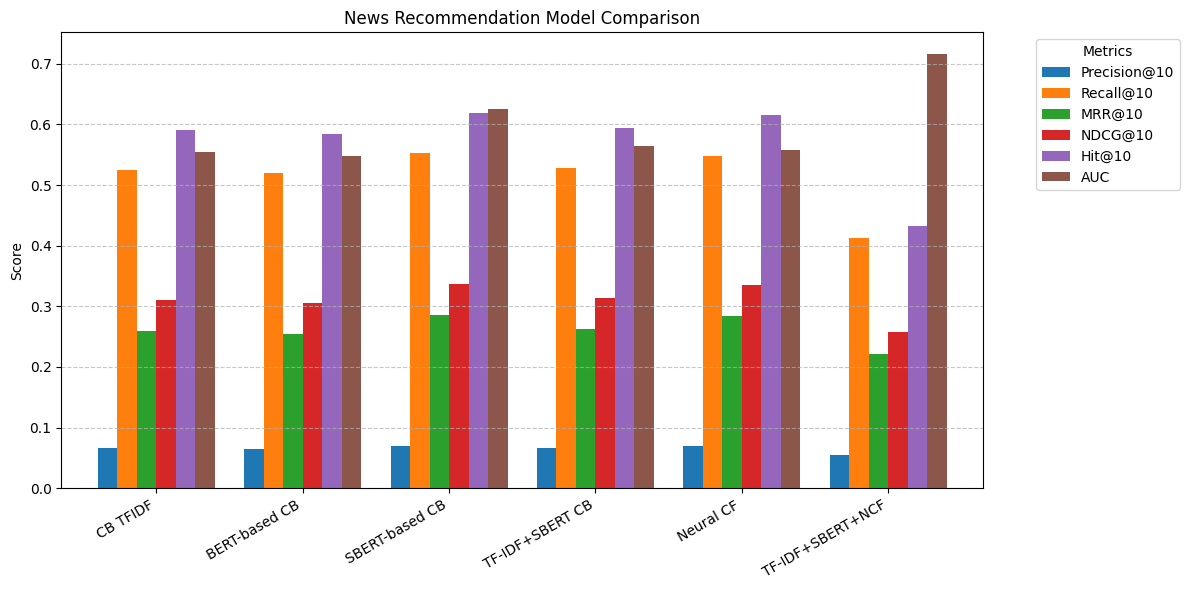

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# DataFrame
data = {
    "CB TFIDF":              [0.0657, 0.5252, 0.2596, 0.3112, 0.5909, 0.5545],
    "BERT-based CB":         [0.0648, 0.5190, 0.2543, 0.3062, 0.5840, 0.5478],
    "SBERT-based CB":        [0.0698, 0.5520, 0.2854, 0.3368, 0.6191, 0.6252],
    "TF-IDF+SBERT CB":       [0.0662, 0.5283, 0.2618, 0.3137, 0.5942, 0.5648],
    "Neural CF":             [0.0692, 0.5482, 0.2845, 0.3351, 0.6152, 0.5572],
    "TF-IDF+SBERT+NCF":      [0.0550, 0.4130, 0.2216, 0.2577, 0.4318, 0.7159],
}
metrics = ["Precision@10", "Recall@10", "MRR@10", "NDCG@10", "Hit@10", "AUC"]

df = pd.DataFrame(data, index=metrics)

#
ax = df.T.plot(kind='bar', figsize=(12, 6), width=0.8)
plt.title("News Recommendation Model Comparison")
plt.ylabel("Score")
plt.xticks(rotation=30, ha='right')
plt.legend(title="Metrics", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


restrict the amount of context per user to simulate new community.

This project presents a comparative evaluation of various models applied to a personalized news recommendation system. The key objective is to predict user preferences effectively and deliver relevant news articles in real-time.

We evaluated six models based on different feature representations and architectures:

Content-Based (CB) using TF-IDF

CB using BERT and SBERT embeddings

Hybrid CB with TF-IDF + SBERT

Neural Collaborative Filtering (NCF)

Fully Hybrid model (TF-IDF + SBERT + NCF)

Across all evaluation metrics—including Precision@10, Recall@10, MRR@10, NDCG@10, Hit@10, and AUC—the SBERT-based content model showed strong performance, especially in ranking-based metrics (MRR and NDCG). The TF-IDF+SBERT+NCF hybrid model, despite having slightly lower Precision and Recall, achieved the highest AUC score (0.7159), indicating superior ability to distinguish between clicked and non-clicked items.

This suggests that combining collaborative signals with deep semantic content features (TF-IDF + SBERT) can effectively enhance user preference modeling. However, in some cases, simpler SBERT-based models without collaborative signals still perform competitively, highlighting the robustness of high-quality textual embeddings in content-based recommendations.

These findings support the use of hybrid architectures in news recommendation systems, balancing content understanding with user interaction modeling for optimal performance.



User Case Study

In [ ]:
def recommend_for_user(user_id, top_n=5, return_json=False):
    print("---GENERATING NEWS RECOMMENDATIONS FOR USER---")
    print(f"User ID: {user_id}")
    print(f"\n---TOP {top_n} RECOMMENDED NEWS ARTICLES ---")

    # Encode user ID
    user_idx = user_encoder.transform([user_id])[0]
    all_item_indices = np.arange(num_items)

    # Find already clicked items (Label == 1)
    seen_news_ids = interactions_df[
        (interactions_df['User_ID'] == user_id) & 
        (interactions_df['Label'] == 1)
    ]['News_ID'].unique()

    seen_indices = news_encoder.transform(seen_news_ids)
    
    # Filter out seen items
    unseen_mask = ~np.isin(all_item_indices, seen_indices)
    unseen_items = all_item_indices[unseen_mask]

    # Skip if nothing to recommend
    if len(unseen_items) == 0:
        print("No unseen items to recommend.")
        return pd.DataFrame()

    # Prepare input tensors
    user_tensor = torch.tensor([user_idx] * len(unseen_items), dtype=torch.long).to(device)
    item_tensor = torch.tensor(unseen_items, dtype=torch.long).to(device)

    # Predict scores
    model.eval()
    with torch.no_grad():
        scores = model(user_tensor, item_tensor).cpu().numpy().flatten()

    # Get top-N
    top_indices = np.argsort(-scores)[:top_n]
    top_item_ids = news_encoder.inverse_transform(unseen_items[top_indices])

    # Retrieve actual news info
    recommended = news[news['News_ID'].isin(top_item_ids)][['News_ID', 'Title', 'Category', 'SubCategory']]

    # Optional JSON return
    if return_json:
        return recommended.to_dict(orient='records')
    
    return recommended


In [ ]:
recommend_for_user("U64800", top_n=10)

---GENERATING NEWS RECOMMENDATIONS FOR USER---
User ID: U64800

---TOP 10 RECOMMENDED NEWS ARTICLES ---


,News_ID,Title,Category,SubCategory
33198,N50165,"CMA Awards 2019: How did Dolly Parton, Reba Mc...",music,cma-awards
41552,N63970,Dean Foods files for bankruptcy,finance,finance-companies
42756,N22696,Free Fight! Blachowicz Flatlines Rockhold In V...,sports,mma
43121,N35915,Four car chiefs ejected after pre-qualifying i...,sports,racing
44541,N25791,Opinions | We thought Trump was the biggest co...,news,newsopinion
45974,N53585,"Rip Taylor's Cause of Death Revealed, Memorial...",tv,tvnews
49398,N13825,Motorcyclist Dies After Falling 90 Feet Off Fo...,news,newsus
50365,N49279,Broadway Actress Laurel Griggs Dies at Age 13,music,musicnews
50688,N35729,Porsche launches into second story of New Jers...,news,newsus
50714,N49685,Broadway Star Laurel Griggs Suffered Asthma At...,music,music-celebrity


# Temporal Integration (content-based + GRU/LSTM)

In [2]:
# imports
import os, random, time
import numpy as np, pandas as pd, torch
import torch.nn as nn, torch.nn.functional as F
from torch.utils.data import DataLoader
from sklearn.metrics import roc_auc_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler
from sentence_transformers import SentenceTransformer
from textblob import TextBlob

# Reproducibility & Device
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.backends.cudnn.deterministic = True
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using {DEVICE}")

def parse_impr(s):
    return [(p.split('-')[0], int(p.split('-')[1])) for p in str(s).split()]

def parse_hist(h):
    return str(h).split()

def split_by_impression(df, test_ratio=0.2):
    df_sorted = df.sort_values("Time")
    cut = int(len(df_sorted) * (1 - test_ratio))
    return df_sorted.iloc[:cut], df_sorted.iloc[cut:]

def generate_balanced_samples(df, uid2idx, news2idx, neg_ratio=4):
    pos_u, pos_n, neg_u, neg_n = [], [], [], []
    all_ids = list(news2idx.values())
    for _, row in df.iterrows():
        uidx = uid2idx[row.User_ID]
        hist_ids = [news2idx[n] for n in row.History_parsed if n in news2idx]
        for hid in hist_ids:
            pos_u.append(uidx); pos_n.append(hid)
        im_pos, im_neg = [], []
        for nid, lbl in row.Impressions_parsed:
            if nid in news2idx:
                (im_pos if lbl==1 else im_neg).append(news2idx[nid])
        for nid in im_pos:
            pos_u.append(uidx); pos_n.append(nid)
        pool = [n for n in im_neg if n not in hist_ids]
        for _ in range(len(im_pos)*neg_ratio):
            if pool:
                choice = random.choice(pool)
            else:
                candidates = set(all_ids) - set(im_pos) - set(hist_ids)
                if not candidates: break
                choice = random.choice(list(candidates))
            neg_u.append(uidx); neg_n.append(choice)
    return pos_u, pos_n, neg_u, neg_n

#import dataset
news = pd.read_csv(
    './kaggle/input/mind-news-dataset/MINDsmall_train/news.tsv', sep='\t',
    names=["News_ID","Category","SubCategory","Title","Abstract",
           "URL","Title_Entities","Abstract_Entities"]
)
beh = pd.read_csv(
    './kaggle/input/mind-news-dataset/MINDsmall_train/behaviors.tsv', sep='\t',
    names=["Impression_ID","User_ID","Time","History","Impressions"]
)
beh = beh.sample(frac=0.20, random_state=SEED).reset_index(drop=True)
print(f"Sampled behaviors: {len(beh):,} rows")

# parse dataset
beh["Impressions_parsed"] = beh["Impressions"].apply(parse_impr)
beh["History_parsed"] = beh["History"].apply(parse_hist)

# organise to users
used_nids = set(nid for lst in beh["Impressions_parsed"] for nid,_ in lst)
used_nids |= set(n for lst in beh["History_parsed"] for n in lst)
news = news[news["News_ID"].isin(used_nids)].reset_index(drop=True)
print(f"Retained news: {len(news):,} articles")

# train/val split
df_train, df_val = split_by_impression(beh, test_ratio=0.2)

#sentiment analysis
news["sent"] = news["Title"].apply(lambda t: TextBlob(str(t)).sentiment.polarity)

# split to one-hot categories
cats = news.Category.unique().tolist()
cat2idx = {c:i for i,c in enumerate(cats)}
news_cat = np.zeros((len(news), len(cats)))
for i,c in enumerate(news.Category):
    news_cat[i, cat2idx[c]] = 1

# TF-IDF
train_nids = set(n for lst in df_train.Impressions_parsed for n,_ in lst) | set(n for lst in df_train.History_parsed     for n   in lst)
train_mask = news.News_ID.isin(train_nids)
val_mask   = ~train_mask

tfv = TfidfVectorizer(max_features=100)
tfidf_train = tfv.fit_transform(
    news.loc[train_mask, "Title"].fillna("")
).toarray()
tfidf_val = tfv.transform(
    news.loc[val_mask, "Title"].fillna("")
).toarray()
# 合并
tfidf = np.zeros((len(news), tfidf_train.shape[1]))
tfidf[train_mask] = tfidf_train
tfidf[val_mask]   = tfidf_val

# 4.4 SBERT
sbert = SentenceTransformer("paraphrase-MiniLM-L6-v2")
txt_train = (
    news.loc[train_mask, ["Title","Abstract"]]
        .fillna("")
        .apply(lambda x: " ".join(x), axis=1)
        .tolist()
)
bt = sbert.encode(txt_train, batch_size=128)
scaler = StandardScaler().fit(bt)
bert_train = scaler.transform(bt)
bert_val   = scaler.transform(
    sbert.encode(
        news.loc[val_mask,["Title","Abstract"]]
            .fillna("")
            .apply(lambda x: " ".join(x), axis=1)
            .tolist(),
        batch_size=128
    )
)

bert = np.zeros((len(news), bert_train.shape[1]))
bert[train_mask] = bert_train
bert[val_mask]   = bert_val
news_x = torch.tensor(
    np.hstack([news.sent.values.reshape(-1,1), news_cat, tfidf, bert]),
    dtype=torch.float
)
print(f"news_x shape: {news_x.shape}")


# 5. organise user and news
news2idx = {nid:i for i,nid in enumerate(news.News_ID)}
uid2idx  = {uid:i for i,uid in enumerate(beh.User_ID.unique())}

Using cuda
Sampled behaviors: 31,393 rows
Retained news: 39,673 articles
news_x shape: torch.Size([39673, 502])


In [3]:
# 6. DataLoader
MAX_LEN = 50

class HistDataset(torch.utils.data.Dataset):
    def __init__(self, user_idx, news_idx, labels):
        self.u, self.n, self.y = user_idx, news_idx, labels
    def __len__(self): return len(self.y)
    def __getitem__(self, i):
        uid = self.u[i].item()
        raw = user_hist.get(uid, [])
        hids = [hid for hid in raw if 0<=hid<news_x.size(0)] or [self.n[i].item()]
        seq = torch.tensor(hids, dtype=torch.long)
        return news_x[seq], news_x[self.n[i].item()], self.y[i], uid

def collate(batch):
    h, c, y, u = zip(*batch)
    lengths = torch.tensor([x.size(0) for x in h])
    return (
        nn.utils.rnn.pad_sequence(h, batch_first=True),
        torch.stack(c), torch.stack(y), lengths, torch.tensor(u)
    )

def build_loaders(df_train, df_val, neg_ratio=4):
    global user_hist
    user_hist = {}
    for row in df_train.itertuples(index=False):
        uid = uid2idx[row.User_ID]
        user_hist.setdefault(uid, []).extend(
            [news2idx[n] for n in row.History_parsed if n in news2idx]
        )
        user_hist[uid] = user_hist[uid][-MAX_LEN:]
    pu,pn,nu,nn = generate_balanced_samples(df_train, uid2idx, news2idx, neg_ratio)
    tr = (
        torch.tensor(pu+nu), torch.tensor(pn+nn),
        torch.tensor([1]*len(pu)+[0]*len(nu), dtype=torch.float)
    )
    va_u,va_n,va_l = [],[],[]
    for row in df_val.itertuples(index=False):
        uidx = uid2idx[row.User_ID]
        for nid,lbl in row.Impressions_parsed:
            if nid in news2idx:
                va_u.append(uidx); va_n.append(news2idx[nid]); va_l.append(lbl)
    va = (
        torch.tensor(va_u), torch.tensor(va_n),
        torch.tensor(va_l, dtype=torch.float)
    )
    return (
        DataLoader(HistDataset(*tr), batch_size=256, shuffle=True, collate_fn=collate),
        DataLoader(HistDataset(*va), batch_size=2048, shuffle=False, collate_fn=collate)
    )


# 7. RNN model

class NewsRNN(nn.Module):
    def __init__(self, in_dim, hidden_size=128, cell="GRU"):
        super().__init__()
        Cell = {"RNN":nn.RNN, "GRU":nn.GRU, "LSTM":nn.LSTM}[cell]
        self.rnn = Cell(input_size=in_dim, hidden_size=hidden_size, batch_first=True)
        self.proj = nn.Linear(in_dim, hidden_size)
        self.cell = cell
        self.rnn.flatten_parameters()
    def forward(self, seq, lens, cand):
        seq = seq.contiguous(); self.rnn.flatten_parameters()
        packed = nn.utils.rnn.pack_padded_sequence(seq, lens, batch_first=True, enforce_sorted=False)
        h = self.rnn(packed)[1]
        if self.cell=="LSTM": h = h[0]
        u = h.squeeze(0); v = self.proj(cand)
        return (u*v).sum(-1)

# metrics
def calc_metrics(y_true, y_pred, users, k: int=10):
    auc = roc_auc_score(y_true, y_pred)
    df = pd.DataFrame({"u":users, "y":y_true, "p":y_pred})
    hits,prec,rec,mrr,ndcg = [],[],[],[],[]
    def ndcg_k(r,k):
        r = np.asarray(r)[:k]
        dcg = (r/np.log2(np.arange(2,len(r)+2))).sum()
        idcg= (1/np.log2(np.arange(2,int(r.sum())+2))).sum()
        return dcg/idcg if idcg>0 else 0
    for _,g in df.groupby("u"):
        y = g.sort_values("p",ascending=False).y.values
        if y.sum()==0: continue
        hits.append(int(y[:k].sum()>0))
        prec.append(y[:k].mean())
        rec.append(y[:k].sum()/y.sum())
        mrr.append(1/(np.argmax(y==1)+1))
        ndcg.append(ndcg_k(y,k))
    return {"hit_rate":np.mean(hits),"precision":np.mean(prec),"recall":np.mean(rec),"MRR":np.mean(mrr),"NDCG":np.mean(ndcg),"AUC":auc}


# train & eval function
def train_eval(cell, train_loader, val_loader, n_epochs=10):
    model = NewsRNN(news_x.size(1), hidden_size=128, cell=cell).to(DEVICE)
    opt = torch.optim.Adam(model.parameters(), lr=1e-3)
    for epoch in range(n_epochs):
        total = len(train_loader); interval = max(1,total//10)
        print(f"[{cell}] Epoch {epoch+1}/{n_epochs} started")
        model.train(); rloss=0
        for i,(seq,cand,y,lens,_) in enumerate(train_loader,1):
            seq,cand,y=seq.to(DEVICE),cand.to(DEVICE),y.to(DEVICE)
            opt.zero_grad(); loss = F.binary_cross_entropy_with_logits(model(seq,lens,cand),y)
            loss.backward(); opt.step(); rloss+=loss.item()
            if i%interval==0 or i==total:
                print(f"  : {100*i/total:.1f}% avg_loss={rloss/i:.4f}")
        print(f"[{cell}] Epoch {epoch+1} done avg_loss={rloss/total:.4f}")
    model.eval(); Y,P,U=[],[],[]
    with torch.no_grad():
        for seq,cand,y,lens,uid in val_loader:
            seq,cand=seq.to(DEVICE),cand.to(DEVICE)
            logits=torch.sigmoid(model(seq,lens,cand)).cpu()
            Y.append(y);P.append(logits);U.append(uid)
    return calc_metrics(torch.cat(Y).numpy(), torch.cat(P).numpy(), torch.cat(U).numpy())


train_loader,val_loader = build_loaders(df_train, df_val)
results = {}
for cell in ["GRU","LSTM"]:
    print(f"\n Training {cell} ...")
    results[cell] = train_eval(cell,train_loader,val_loader)
    print(results[cell])
print("\n===== Summary =====")
for c,m in results.items(): print(f"{c}: {m}")


 Training GRU ...
[GRU] Epoch 1/10 started
  : 10.0% avg_loss=0.5147
  : 20.0% avg_loss=0.4477
  : 30.0% avg_loss=0.4141
  : 40.0% avg_loss=0.3937
  : 50.0% avg_loss=0.3789
  : 60.0% avg_loss=0.3689
  : 69.9% avg_loss=0.3604
  : 79.9% avg_loss=0.3539
  : 89.9% avg_loss=0.3480
  : 99.9% avg_loss=0.3430
  : 100.0% avg_loss=0.3430
[GRU] Epoch 1 done avg_loss=0.3430
[GRU] Epoch 2/10 started
  : 10.0% avg_loss=0.2770
  : 20.0% avg_loss=0.2791
  : 30.0% avg_loss=0.2780
  : 40.0% avg_loss=0.2786
  : 50.0% avg_loss=0.2785
  : 60.0% avg_loss=0.2783
  : 69.9% avg_loss=0.2777
  : 79.9% avg_loss=0.2772
  : 89.9% avg_loss=0.2759
  : 99.9% avg_loss=0.2754
  : 100.0% avg_loss=0.2755
[GRU] Epoch 2 done avg_loss=0.2755
[GRU] Epoch 3/10 started
  : 10.0% avg_loss=0.2410
  : 20.0% avg_loss=0.2441
  : 30.0% avg_loss=0.2449
  : 40.0% avg_loss=0.2469
  : 50.0% avg_loss=0.2479
  : 60.0% avg_loss=0.2493
  : 69.9% avg_loss=0.2498
  : 79.9% avg_loss=0.2506
  : 89.9% avg_loss=0.2511
  : 99.9% avg_loss=0.2513
  

# Knowledge Graph / GNN Integration - sentiSBERT-KG-GNN

### Load Data

In [1]:
import random
import numpy as np
import torch
import os
import pandas as pd
from textblob import TextBlob
import ast
import networkx as nx
from torch_geometric.data import HeteroData
from sklearn.feature_extraction.text import TfidfVectorizer
from sentence_transformers import SentenceTransformer
from sklearn.preprocessing import StandardScaler
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import HANConv
from torch.utils.data import DataLoader, TensorDataset, Dataset
from tqdm.std import tqdm
import time
import matplotlib.pyplot as plt
from collections import Counter
from datetime import datetime

In [2]:
def set_random_seed(seed=42):
    # Python random
    random.seed(seed)
    
    # NumPy
    np.random.seed(seed)
    
    # PyTorch
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    
    # Ensure CUDA operations are deterministic
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    
    # Python hash seed
    os.environ['PYTHONHASHSEED'] = str(seed)
    
    print(f"Random seed set to {seed} for reproducibility")
    print(f"   - Python random: {seed}")
    print(f"   - NumPy: {seed}")
    print(f"   - PyTorch: {seed}")
    print(f"   - CUDA deterministic: True")
    print(f"   - Python hash seed: {seed}")

# Set random seed
set_random_seed(42)

Random seed set to 42 for reproducibility
   - Python random: 42
   - NumPy: 42
   - PyTorch: 42
   - CUDA deterministic: True
   - Python hash seed: 42


reload data

In [3]:
behaviour = pd.read_csv('./kaggle/input/mind-news-dataset/MINDsmall_train/behaviors.tsv', sep='\t', 
                        names=["Impression_ID", "User_ID", "Time", "History", "Impressions"])

news = pd.read_csv('./kaggle/input/mind-news-dataset/MINDsmall_train/news.tsv', sep='\t',
                   names=["News_ID", "Category", "SubCategory", "Title", "Abstract", "URL", "Title_Entities", "Abstract_Entities"])


print('News sample:')
print(news.head())
print('behaviour sample:')
print(behaviour.head())

# Load entity_embedding.vec
entity_emb = {}
with open('./kaggle/input/mind-news-dataset/MINDsmall_train/entity_embedding.vec', 'r') as f:
    for line in f:
        parts = line.strip().split()
        entity_id = parts[0]
        emb = np.array([float(x) for x in parts[1:]])
        entity_emb[entity_id] = emb
print('Sample entity embedding:', list(entity_emb.items())[:1])

News sample:
  News_ID   Category      SubCategory  \
0  N55528  lifestyle  lifestyleroyals   
1  N19639     health       weightloss   
2  N61837       news        newsworld   
3  N53526     health           voices   
4  N38324     health          medical   

                                               Title  \
0  The Brands Queen Elizabeth, Prince Charles, an...   
1                      50 Worst Habits For Belly Fat   
2  The Cost of Trump's Aid Freeze in the Trenches...   
3  I Was An NBA Wife. Here's How It Affected My M...   
4  How to Get Rid of Skin Tags, According to a De...   

                                            Abstract  \
0  Shop the notebooks, jackets, and more that the...   
1  These seemingly harmless habits are holding yo...   
2  Lt. Ivan Molchanets peeked over a parapet of s...   
3  I felt like I was a fraud, and being an NBA wi...   
4  They seem harmless, but there's a very good re...   

                                             URL  \
0  https://ass

### 3. Data Cleaning

optionally limit database for cold-start study

restrict the amount of context per user to simulate new community.

In [4]:
HISTORY_LIMIT = None  # Set to None for no limit
def cap_front_list(history_list, limit=HISTORY_LIMIT):
    if limit is not None and len(history_list) > limit:
        history_list = history_list[limit:]
    return history_list

def cap_front_string(history_str, limit=HISTORY_LIMIT):
    # tolerate NaN/None and non‑string inputs
    if not isinstance(history_str, str):
        return ''  # or return history_str as-is if you prefer
    tokens = history_str.strip().split()
    # keep your original capping rule here:
    # from the *front* (adjust to your logic)
    tokens = cap_front_list(tokens, limit=limit)
    if limit is None:
        return ' '.join(tokens)
    return ' '.join(tokens[:limit])


parse data

In [5]:
def parse_impressions(imp_str):
    if pd.isna(imp_str):
        return []
    items = imp_str.strip().split(' ')
    return [(i.split('-')[0], int(i.split('-')[1])) for i in items]

behaviour['Impressions_parsed'] = behaviour['Impressions'].apply(parse_impressions)

def parse_history(history_str):
    if pd.isna(history_str):
        return []
    return history_str.strip().split(' ')

behaviour['History_parsed'] = behaviour['History'].apply(parse_history)
behaviour['History'] = behaviour['History'].apply(cap_front_string)

def check_df_shape_and_null(df):
    print("The shape of df:", df.shape)
    df.info()
    
    print("\nThe number of missing values in each column:")
    print(df.isnull().sum())

news_clean = news.dropna()
news_clean.drop_duplicates(subset=['News_ID'], inplace=True)

behaviour_clean = behaviour.dropna()
behaviour_clean.drop_duplicates(subset=['Impression_ID'], inplace=True)

check_df_shape_and_null(news_clean)
check_df_shape_and_null(behaviour_clean)

The shape of df: (48612, 8)
<class 'pandas.core.frame.DataFrame'>
Index: 48612 entries, 0 to 51280
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   News_ID            48612 non-null  object
 1   Category           48612 non-null  object
 2   SubCategory        48612 non-null  object
 3   Title              48612 non-null  object
 4   Abstract           48612 non-null  object
 5   URL                48612 non-null  object
 6   Title_Entities     48612 non-null  object
 7   Abstract_Entities  48612 non-null  object
dtypes: object(8)
memory usage: 3.3+ MB

The number of missing values in each column:
News_ID              0
Category             0
SubCategory          0
Title                0
Abstract             0
URL                  0
Title_Entities       0
Abstract_Entities    0
dtype: int64
The shape of df: (156965, 7)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 156965 entries, 0 to 156964
Data colu

/tmp/ipykernel_4210/1507913398.py:25: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  news_clean.drop_duplicates(subset=['News_ID'], inplace=True)



### 4. Entity Analysis 

In [6]:
def has_entities(x):
    if pd.isna(x) or str(x).strip() == "":
        return False
    try:
        ents = ast.literal_eval(x)
        return isinstance(ents, list) and len(ents) > 0
    except Exception:
        return False

# Calculate the proportion of titles without entities and abstracts without entities.
frac_title_empty = 1 - news_clean['Title_Entities'].apply(has_entities).mean()
frac_abs_empty   = 1 - news_clean['Abstract_Entities'].apply(has_entities).mean()

print(f"Title Missing columns: {frac_title_empty:.1%}")
print(f"Abstract Missing columns: {frac_abs_empty:.1%}")

Title Missing columns: 27.1%
Abstract Missing columns: 23.0%


### 5. Sentiment Analysis

In [7]:
def get_sentiment(text):
    if pd.isnull(text):
        return 0.0
    return TextBlob(str(text)).sentiment.polarity

# Apply sentiment analysis to news titles
news_clean['sentiment_score_title'] = news_clean['Title']   .apply(get_sentiment)

print(news_clean[['Title','sentiment_score_title']].head())

                                               Title  sentiment_score_title
0  The Brands Queen Elizabeth, Prince Charles, an...                    0.0
1                      50 Worst Habits For Belly Fat                   -1.0
2  The Cost of Trump's Aid Freeze in the Trenches...                    0.0
3  I Was An NBA Wife. Here's How It Affected My M...                   -0.1
4  How to Get Rid of Skin Tags, According to a De...                    0.0


/tmp/ipykernel_4210/212460997.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  news_clean['sentiment_score_title'] = news_clean['Title']   .apply(get_sentiment)


### 6.Data Processing for title entities 

In [8]:
# Define default entity IDs
news_clean=news_clean.copy()
GLOBAL_DEFAULT_TITLE = 'GLOBAL_DEFAULT_TITLE'
GLOBAL_DEFAULT_ABS   = 'GLOBAL_DEFAULT_ABS'

def fill_title_entities(row):
    try:
        ents = ast.literal_eval(row['Title_Entities'])
    except:
        ents = []
    return ents if ents else [{'Label': GLOBAL_DEFAULT_TITLE}]

# Process title entities
news_clean['Title_Entities_Processed']    = news_clean.apply(fill_title_entities, axis=1)

#Calculate entity sentiment averages
entity_sent_title = {}
for _, row in news_clean.iterrows():
    score = get_sentiment(row['Title'])
    for ent in row['Title_Entities_Processed']:
        eid = ent['Label']
        if eid == GLOBAL_DEFAULT_TITLE: 
            continue
        entity_sent_title.setdefault(eid, []).append(score)

entity_sentiment_title_avg = {
    eid: sum(v)/len(v) 
    for eid, v in entity_sent_title.items()
}
# Set default sentiment for global entities
default_title_sent = np.mean(list(entity_sentiment_title_avg.values()))
entity_sentiment_title_avg[GLOBAL_DEFAULT_TITLE] = default_title_sent

#Add embeddings for global entities
all_embs    = np.array(list(entity_emb.values()))
default_emb = all_embs.mean(axis=0)
entity_emb[GLOBAL_DEFAULT_TITLE] = default_emb

print(news_clean.head)

<bound method NDFrame.head of       News_ID   Category               SubCategory  \
0      N55528  lifestyle           lifestyleroyals   
1      N19639     health                weightloss   
2      N61837       news                 newsworld   
3      N53526     health                    voices   
4      N38324     health                   medical   
...       ...        ...                       ...   
51275  N17258       news  newsscienceandtechnology   
51276  N23858     sports                      golf   
51277  N16909    weather         weathertopstories   
51279   N7482     sports               more_sports   
51280  N34418     sports                soccer_epl   

                                                   Title  \
0      The Brands Queen Elizabeth, Prince Charles, an...   
1                          50 Worst Habits For Belly Fat   
2      The Cost of Trump's Aid Freeze in the Trenches...   
3      I Was An NBA Wife. Here's How It Affected My M...   
4      How to Get Rid

### 7.Split dataset to 80% training and 20% testing

In [9]:
def split_by_impression(behaviour_clean, test_ratio=0.2):
    behaviour_sorted = behaviour_clean.sort_values('Time')
    # split by Impression
    split_idx = int(len(behaviour_sorted) * (1 - test_ratio))
    train_behaviour = behaviour_sorted.iloc[:split_idx]
    test_behaviour = behaviour_sorted.iloc[split_idx:]
    return train_behaviour, test_behaviour

train_behaviour, test_behaviour = split_by_impression(behaviour_clean, test_ratio=0.2) 

In [10]:
#Sample users for efficiency
sample_ratio = 0.2
user_ids_sub = train_behaviour['User_ID'].unique()
sampled_users_sub = np.random.choice(user_ids_sub, size=int(len(user_ids_sub) * sample_ratio), replace=False)

# Filter behavior for sampled users
train_behaviour_sub = train_behaviour[train_behaviour['User_ID'].isin(sampled_users_sub)].copy()
test_behaviour_sub = test_behaviour[test_behaviour['User_ID'].isin(sampled_users_sub)].copy()

# Find news IDs involved in sampled behavior
news_ids_in_history = set()
for h in train_behaviour_sub['History']:
    news_ids_in_history.update(str(h).split())
if 'Impressions' in train_behaviour_sub.columns:
    for imp in train_behaviour_sub['Impressions']:
        news_ids_in_history.update([i.split('-')[0] for i in str(imp).split()])

#Keep only relevant news
news_clean = news_clean[news_clean['News_ID'].isin(news_ids_in_history)].copy()

### 8. Knowledge Graph Construction (Illustration)

In [11]:
G = nx.Graph()

# Add news nodes with sentiment
for idx, row in news_clean.iterrows():
    G.add_node(row['News_ID'], node_type='news', sentiment=row['sentiment_score_title'])

# Add entity nodes and news-entity edges
for idx, row in news_clean.iterrows():
    try:
        entities = row['Title_Entities_Processed']
    except:
        entities = []
    for ent in entities:
        ent_label = ent.get('Label', '')
        if ent_label:
            ent_emb = entity_emb.get(ent_label, np.zeros(100))
            ent_sent = entity_sentiment_title_avg.get(ent_label, 0)
            G.add_node(ent_label, node_type='entity', features=np.concatenate([ent_emb, [ent_sent]]))
            G.add_edge(row['News_ID'], ent_label, edge_type='has_entity')

# Add user-news interactions
for idx, row in train_behaviour_sub.iterrows():
    user = row['User_ID']
    history = str(row['History']).split()
    for news_id in history:
        G.add_node(user, node_type='user')
        G.add_edge(user, news_id, edge_type='clicked')

print(f'Graph has {G.number_of_nodes()} nodes and {G.number_of_edges()} edges.')



Graph has 45345 nodes and 207094 edges.


In [12]:
#9.1 Prepare mappings and lists
news_id_list = news_clean['News_ID'].tolist()
news2idx     = {nid:i for i,nid in enumerate(news_id_list)}

user_id_list = train_behaviour_sub['User_ID'].unique().tolist()
user2idx     = {uid:i for i,uid in enumerate(user_id_list)}

entity_id_list = list(entity_emb.keys())
emb_dim        = len(next(iter(entity_emb.values())))
entity2idx     = {eid:i for i,eid in enumerate(entity_id_list)}

sent_map = news_clean.set_index('News_ID')['sentiment_score_title'].to_dict()
ent_lists = news_clean['Title_Entities_Processed'].tolist()


In [13]:
#9.2 Building up News node features

#9.2.1 Sentiment score feature
news_sentiment = news_clean['sentiment_score_title'].values.reshape(-1, 1)  # shape: (N_news, 1)

#9.2.2 One-hot features for "category" data
categories = news_clean['Category'].unique().tolist()
cat2idx = {cat: i for i, cat in enumerate(categories)}
news_cat_feat = np.zeros((len(news_clean), len(categories)))
for i, cat in enumerate(news_clean['Category']):
    news_cat_feat[i, cat2idx[cat]] = 1  # shape: (N_news, num_categories)

#9.2.3 TF-IDF text features for "title" data
vectorizer = TfidfVectorizer(max_features=100)
tfidf_feat = vectorizer.fit_transform(news_clean['Title'].fillna('')).toarray()  # shape: (N_news, 100)

#9.2.4 SBERT embeddings for "title" and "abstract"data
sbert = SentenceTransformer('paraphrase-MiniLM-L6-v2')
news_texts = (news_clean['Title'].fillna('') + ' ' + news_clean['Abstract'].fillna('')).tolist()
bert_feat = sbert.encode(news_texts, show_progress_bar=True, batch_size=128)
scaler = StandardScaler()
bert_feat_norm = scaler.fit_transform(bert_feat)

#9.2.5 Combine all above four news features
news_x = np.hstack([news_sentiment, news_cat_feat, tfidf_feat,bert_feat_norm])  # shape: (N_news, 1+num_categories+100)
news_x = torch.tensor(news_x, dtype=torch.float)

#9.3 Building up Entity node features using entity_sentiment_title_avg data

entity_x_np = np.array([
    np.concatenate([
        entity_emb[eid],
        [entity_sentiment_title_avg.get(eid, 0.0)]
    ])
    for eid in entity_id_list
])
entity_x = torch.tensor(entity_x_np, dtype=torch.float)



# 9.4 Building up User node features 

news_id2cat = news_clean.set_index('News_ID')['Category'].to_dict()
categories = list(news_clean['Category'].unique())
cat2idx = {cat: i for i, cat in enumerate(categories)}

#9.4.1 User category distribution
user_cat_feat = np.zeros((len(user_id_list), len(categories)))
for i, uid in enumerate(user_id_list):
    user_hist = train_behaviour_sub[train_behaviour_sub['User_ID'] == uid]['History']
    news_ids = []
    for h in user_hist:
        news_ids += str(h).split()
    for nid in news_ids:
        cat = news_id2cat.get(nid, None)
        if cat is not None:
            user_cat_feat[i, cat2idx[cat]] += 1
#Normalize category features
user_cat_feat = user_cat_feat / (user_cat_feat.sum(axis=1, keepdims=True) + 1e-8)

#9.4.2 Time-decayed user embedding features
def temporal_weight(time_diff_hours):
    if time_diff_hours == 0:
        return 1.0
    # logarithmic decay：1 / (1 + log(1 + hours/12))
    return 1.0 / (1.0 + np.log(1 + time_diff_hours / 12))

#Parse time string
def parse_time(time_str):
    try:
        return datetime.strptime(time_str, "%m/%d/%Y %I:%M:%S %p")
    except:
        return datetime.now()

# Get reference time
latest_time = None
for _, row in train_behaviour_sub.iterrows():
    current_time = parse_time(row['Time'])
    if latest_time is None or current_time > latest_time:
        latest_time = current_time

print(f"reference time: {latest_time}")

# Calculate time-decayed user embeddings
user_emb_feat = np.zeros((len(user_id_list), news_x.shape[1]))

for i, uid in enumerate(user_id_list):
    user_hist = train_behaviour_sub[train_behaviour_sub['User_ID'] == uid]
    
    if len(user_hist) == 0:
        continue
    
  # Calculate weighted average
    user_news_weights = []
    for _, row in user_hist.iterrows():
        behavior_time = parse_time(row['Time'])
        time_diff_hours = (latest_time - behavior_time).total_seconds() / 3600
        time_weight = temporal_weight(time_diff_hours)
        

        history_news_ids = str(row['History']).split()
        
        for news_id in history_news_ids:
            if news_id in news2idx:
                news_idx = news2idx[news_id]
                user_news_weights.append((news_x[news_idx].numpy(), time_weight))
    if user_news_weights:
        total_weight = sum(weight for _, weight in user_news_weights)
        weighted_sum = np.zeros(news_x.shape[1])
        
        for news_emb, weight in user_news_weights:
            weighted_sum += news_emb * weight
        
        user_emb_feat[i] = weighted_sum / total_weight
    else:
        user_emb_feat[i] = np.zeros(news_x.shape[1])


#9.4.3 Combine user features
user_feat = np.hstack([user_cat_feat, user_emb_feat])
user_x = torch.tensor(user_feat, dtype=torch.float)




Batches:   0%|          | 0/207 [00:00<?, ?it/s]

reference time: 2019-11-14 23:58:51


### 10. Edge Construction 

In [14]:
# News-entity edges
news_src = []
ent_dst  = []
for i, ents in enumerate(ent_lists):
    for ent in ents:
        eid = ent.get('WikidataId', ent.get('Label'))
        if eid in entity2idx:
            news_src.append(i)
            ent_dst.append(entity2idx[eid])


# User-news edges
user_src = []
news_dst = []
for row in train_behaviour_sub.itertuples(index=False):
    uidx = user2idx[row.User_ID]
    for nid in str(row.History).split():
        if nid in news2idx:
            user_src.append(uidx)
            news_dst.append(news2idx[nid])


### 11. Heterogeneous Graph Construction

In [15]:
data = HeteroData()
data['news'].x   = news_x
data['entity'].x = entity_x
data['user'].x   = user_x

data['user','clicked','news'].edge_index     = torch.tensor([user_src, news_dst], dtype=torch.long)
data['news','has_entity','entity'].edge_index = torch.tensor([news_src, ent_dst ], dtype=torch.long)

print(data)


HeteroData(
  news={ x=[26396, 502] },
  entity={ x=[26905, 101] },
  user={ x=[9183, 519] },
  (user, clicked, news)={ edge_index=[2, 756117] },
  (news, has_entity, entity)={ edge_index=[2, 37236] }
)


### 12. KGAT Model Definition 

In [16]:
# Add reverse edges for HANConv
data['news', 'clicked_by', 'user'].edge_index = data['user', 'clicked', 'news'].edge_index[[1,0], :]
data['entity', 'entity_of', 'news'].edge_index = data['news', 'has_entity', 'entity'].edge_index[[1,0], :]

class SentimentKGAT(torch.nn.Module):
    def __init__(self, hidden_dim, entity_emb_dim,dropout=0.2):
        super().__init__()
        in_channels = {
    'news': news_x.shape[1],
    'entity': entity_x.shape[1],
    'user': user_x.shape[1]
}
        self.han = HANConv(in_channels=in_channels,out_channels=hidden_dim,metadata=data.metadata())
        self.dropout = nn.Dropout(dropout)
        self.lin = torch.nn.Linear(hidden_dim, 1) 

    def forward(self, data):
        x_dict = self.han(data.x_dict, data.edge_index_dict)
        for k in x_dict:
            x_dict[k] = self.dropout(x_dict[k])
        return x_dict


### 13. Training Data Generation

In [17]:
def generate_balanced_samples(train_behaviour_sub, user2idx, news2idx, neg_ratio=4):
    """Generate balanced samples with 1:4 positive to negative ratio"""
    pos_user_idx, pos_news_idx, neg_user_idx, neg_news_idx = [], [], [], []
    
    for _, row in train_behaviour_sub.iterrows():
        user_id = row['User_ID']
        user_idx = user2idx.get(user_id, None)
        if user_idx is None:
            continue
            
        impressions = str(row['Impressions']).split()
        user_pos_news = []
        user_neg_news = []
        
        for imp in impressions:
            if '-' in imp:
                news_id, label = imp.rsplit('-', 1)
                label = int(label)
                news_idx = news2idx.get(news_id, None)
                
                if news_idx is None:
                    continue
                    
                if label == 1:
                    user_pos_news.append(news_idx)
                elif label == 0:
                    user_neg_news.append(news_idx)
        
        # Add all positive samples
        for news_idx in user_pos_news:
            pos_user_idx.append(user_idx)
            pos_news_idx.append(news_idx)
        
        # Negative sampling
        if user_pos_news and user_neg_news:
            for _ in range(len(user_pos_news) * neg_ratio):
                neg_news_idx_selected = random.choice(user_neg_news)
                neg_user_idx.append(user_idx)
                neg_news_idx.append(neg_news_idx_selected)
    
    return pos_user_idx, pos_news_idx, neg_user_idx, neg_news_idx

# Generate training samples
train_pos_user_idx, train_pos_news_idx, train_neg_user_idx, train_neg_news_idx = generate_balanced_samples(
    train_behaviour_sub, user2idx, news2idx, neg_ratio=4
)

# Create training data loader
train_user_idx = torch.tensor(train_pos_user_idx + train_neg_user_idx, dtype=torch.long)
train_news_idx = torch.tensor(train_pos_news_idx + train_neg_news_idx, dtype=torch.long)
train_labels = torch.tensor([1] * len(train_pos_user_idx) + [0] * len(train_neg_user_idx), dtype=torch.float)

train_dataset = TensorDataset(train_user_idx, train_news_idx, train_labels)
train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True)

# Create test data loader (preserve original impression format)
class TestDataset(Dataset):
    def __init__(self, df):
        self.rows = df.to_dict('records')
    def __len__(self):
        return len(self.rows)
    def __getitem__(self, idx):
        return self.rows[idx]

test_dataset = TestDataset(test_behaviour_sub)
test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False)

# Print statistics
print(f"Training users: {train_behaviour_sub['User_ID'].nunique()}")
print(f"Test users: {test_behaviour_sub['User_ID'].nunique()}")
print(f"Training positive samples: {len(train_pos_user_idx)}")
print(f"Training negative samples: {len(train_neg_user_idx)}")
print(f"Training positive/negative ratio: 1:{len(train_neg_user_idx)/len(train_pos_user_idx):.2f}")
print(f"Test impressions: {len(test_behaviour_sub)}")


Training users: 9183
Test users: 3287
Training positive samples: 35448
Training negative samples: 141452
Training positive/negative ratio: 1:3.99
Test impressions: 5202


### 14. Model Training 

In [18]:
# Setup device and model
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Using device:", device)

entity_emb_dim = len(next(iter(entity_emb.values()))) 
model = SentimentKGAT(hidden_dim=128, entity_emb_dim=entity_emb_dim).to(device)
data.to(device)  

# Setup loss function with class weights
pos_weight = len(train_neg_user_idx) / len(train_pos_user_idx)
print(f"Positive sample weight: {pos_weight:.2f}")
criterion = torch.nn.BCEWithLogitsLoss(pos_weight=torch.tensor([pos_weight]))
pos_weight_tensor = torch.tensor([pos_weight]).to(device)
criterion = torch.nn.BCEWithLogitsLoss(pos_weight=pos_weight_tensor)


# Setup optimizer
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

#CUDA timer
start_evt = torch.cuda.Event(enable_timing=True)
end_evt   = torch.cuda.Event(enable_timing=True)

Using device: cuda
Positive sample weight: 3.99


In [19]:
num_epochs = 10
train_losses = []
epoch_times = []

for epoch in range(1, num_epochs + 1):
    model.train()
    start_time = time.time()
    total_loss = 0.0
    
    for u_idx, n_idx, lbl in tqdm(train_loader, desc=f"Epoch {epoch} Training", leave=False):
        u_idx, n_idx, lbl = u_idx.to(device), n_idx.to(device), lbl.to(device)
        optimizer.zero_grad()
        
        # Forward pass
        out = model(data)
        u_emb = out['user'][u_idx]
        n_emb = out['news'][n_idx]
        
        # Calculate recommendation scores
        logits = (u_emb * n_emb).sum(dim=1)
        loss = criterion(logits, lbl)
        
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    
    train_loss = total_loss / len(train_loader)
    
    elapsed = time.time() - start_time
    train_losses.append(train_loss)
    epoch_times.append(elapsed)

    print(f"Epoch {epoch}: Train Loss={train_loss:.4f}, Time={elapsed:.1f}s")

print("Training completed!")


Epoch 1: Train Loss=1.0934, Time=16.5s


Epoch 2: Train Loss=1.0778, Time=16.3s


Epoch 3: Train Loss=1.0720, Time=16.3s


Epoch 4: Train Loss=1.0671, Time=16.5s


Epoch 5: Train Loss=1.0642, Time=16.6s


Epoch 6: Train Loss=1.0594, Time=15.9s


Epoch 7: Train Loss=1.0568, Time=15.8s


Epoch 8: Train Loss=1.0537, Time=15.8s


Epoch 9: Train Loss=1.0508, Time=15.8s


Epoch 10: Train Loss=1.0475, Time=15.8s
Training completed!


In [20]:
model.eval()
all_scores = []
all_labels = []
all_users = []

with torch.no_grad():
    for batch in tqdm(test_loader, desc="Testing"):
        row = batch
        
        user_id = row['User_ID']
        if isinstance(user_id, list):
            user_id = user_id[0]
        
        impressions = row['Impressions_parsed']
        
        if user_id not in user2idx:
            continue
            
        user_idx = user2idx[user_id]
        user_idx_tensor = torch.tensor([user_idx]).to(device)
        
        # Get user embedding
        out = model(data)
        user_emb = out['user'][user_idx_tensor]
        
        # Process each impression
        for impression in impressions:
            news_id_tuple = impression[0]
            news_id = news_id_tuple[0]  
            
            label_tensor = impression[1]
            label = label_tensor.item()  
            
            if news_id not in news2idx:
                continue
                
            news_idx = news2idx[news_id]
            news_idx_tensor = torch.tensor([news_idx]).to(device)
            
             # Get news embedding
            news_emb = out['news'][news_idx_tensor]
            
            # Calculate recommendation score
            score = (user_emb * news_emb).sum(dim=1).cpu().item()
            
            all_scores.append(score)
            all_labels.append(label)
            all_users.append(user_idx)

# Convert to numpy arrays
all_scores = np.array(all_scores)
all_labels = np.array(all_labels)
all_users = np.array(all_users)

print(f"Collected samples: {len(all_scores)}")
print(f"Collected labels: {len(all_labels)}")
print(f"Collected users: {len(all_users)}")
print(f"Positive samples: {np.sum(all_labels)}")
print(f"Negative samples: {len(all_labels) - np.sum(all_labels)}")



Testing: 100%|██████████| 5202/5202 [01:10<00:00, 73.52it/s]

Collected samples: 183892
Collected labels: 183892
Collected users: 183892
Positive samples: 7065
Negative samples: 176827


### 16. Evaluation Metrics

In [21]:
def evaluate_rank_metrics(scores, labels, users, k=10):
    precision_list, recall_list = [], []
    mrr_list, ndcg_list, hit_list = [], [], []

    for u in np.unique(users):
        idx = (users == u)
        sc = scores[idx]
        lb = labels[idx]
        #check if sample is enough    
        if len(sc) == 0:
            continue
            
        # order as the decsending order
        order = np.argsort(-sc)
        actual_k = min(k, len(sc))
        topk = order[:actual_k]
        rels = lb[topk]
        total_rels = lb.sum()

        # Precision@k
        precision_list.append(rels.sum() / actual_k)
        
        # Recall@k
        recall_list.append(rels.sum() / total_rels if total_rels > 0 else 0.0)
        
        # HitRate@k
        hit_list.append(1.0 if rels.sum() > 0 else 0.0)
        
        # MRR
        ranks = np.where(rels == 1)[0]
        mrr_list.append(1.0 / (ranks[0] + 1) if ranks.size > 0 else 0.0)
        
        # NDCG@k
        dcg = np.sum((2**rels - 1) / np.log2(np.arange(len(rels)) + 2))
        ideal = np.sort(lb)[::-1][:actual_k]
        idcg = np.sum((2**ideal - 1) / np.log2(np.arange(len(ideal)) + 2))
        ndcg_list.append(dcg / idcg if idcg > 0 else 0.0)

    return {
        'Precision@10': np.mean(precision_list),
        'Recall@10':    np.mean(recall_list),
        'MRR':          np.mean(mrr_list),
        'NDCG@10':      np.mean(ndcg_list),
        'HitRate@10':   np.mean(hit_list)
    }

# Calculate and print metrics
metrics = evaluate_rank_metrics(all_scores, all_labels, all_users, k=20)
print(f"\n===result ===")
print(f"Precision@10: {metrics['Precision@10']:.4f}")
print(f"Recall@10:    {metrics['Recall@10']:.4f}")
print(f"MRR:          {metrics['MRR']:.4f}")
print(f"NDCG@10:      {metrics['NDCG@10']:.4f}")
print(f"HitRate@10:   {metrics['HitRate@10']:.4f}")


===result ===
Precision@10: 0.1001
Recall@10:    0.6145
MRR:          0.2791
NDCG@10:      0.3340
HitRate@10:   0.7635


Coldstart results

sentiSBERT-KG-GNN
| User History Max Size | hit\_rate\@N | precision\@N | recall\@N | MRR\@N   | NDCG\@N  |
| --------------------- | ------------ | ------------ | --------- | -------- | -------- |
| 1                     | 0.036965     | 0.003696     | 0.036965  | 0.030871 | 0.024501 |
| 3                     | 0.03374      | 0.003657     | 0.023958  | 0.029679 | 0.021768 |
| 5                     | 0.133972     | 0.015659     | 0.076717  | 0.081122 | 0.084969 |
| 7                     | 0.51792      | 0.06826      | 0.278279  | 0.264064 | 0.310232 |
| Unlimited             | 0.7716       | 0.1034       | 0.6143    | 0.2956   | 0.3423   |


### 17. User Study

Selected representative users:
1. User index: 0
2. User index: 17
3. User index: 939
4. User index: 4167

User Case Analysis: U50864
User Statistics:
- Total test items: 28
- Positive items: 0
- Negative items: 28
- Positive ratio: 0.000

Top-10 Recommendation Performance:
- Precision@10: 0.0000
- Recall@10: 0.0000
- HitRate@10: 0.0000
- MRR: 0.0000
- NDCG@10: 0.0000

Top-10 Recommendations:
Rank   Score    Label  News_ID        
----------------------------------------
1      0.9847   0      N9786          
2      0.6117   0      N43620         
3      0.5901   0      N41387         
4      0.5595   0      N3574          
5      0.4355   0      N47705         
6      0.2831   0      N57356         
7      0.1235   0      N53526         
8      0.1169   0      N37243         
9      0.0455   0      N9721          
10     0.0374   0      N18680         

User Behavior Analysis:
- Historical clicks: 9 items
- Test impressions: 28 items

Performance Summary:
- Low precision: Model struggl

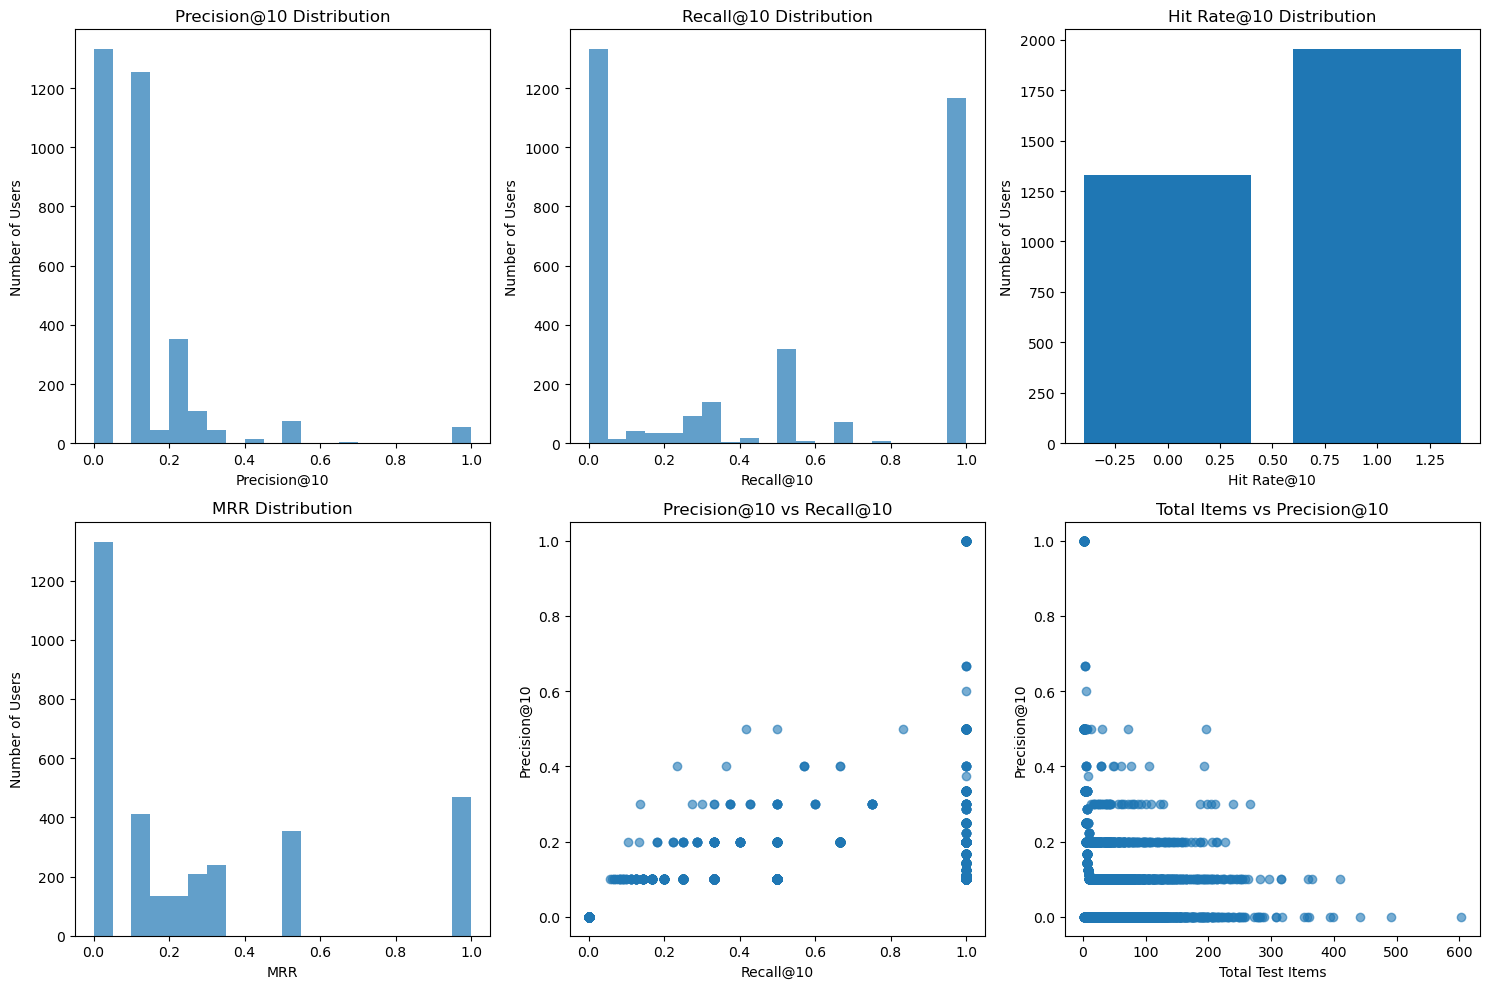


User case analysis completed! (k=10)
Analyzed 4 representative users out of 3286 total users


In [22]:
#User Case Analysis (k=10 version)
import matplotlib.pyplot as plt
import numpy as np
from collections import Counter

def select_representative_users(all_scores, all_labels, all_users, user2idx, k=5):
    """
    Select representative users for case analysis
    """
    user_metrics = {}
    
    for u in np.unique(all_users):
        idx = (all_users == u)
        sc = all_scores[idx]
        lb = all_labels[idx]
        
        if len(sc) == 0:
            continue
            
        # Calculate metrics for this user (using k=10 for selection)
        order = np.argsort(-sc)
        topk = order[:10]  # Changed to k=10
        rels = lb[topk]
        total_rels = lb.sum()
        
        precision = rels.sum() / len(topk)
        recall = rels.sum() / total_rels if total_rels > 0 else 0.0
        hit_rate = 1.0 if rels.sum() > 0 else 0.0
        
        # Calculate MRR
        ranks = np.where(rels == 1)[0]
        mrr = 1.0 / (ranks[0] + 1) if ranks.size > 0 else 0.0
        
        user_metrics[u] = {
            'precision': precision,
            'recall': recall,
            'hit_rate': hit_rate,
            'mrr': mrr,
            'total_items': len(sc),
            'positive_items': total_rels
        }
    
    # Select users with different characteristics
    selected_users = []
    
    # 1. High performer (high precision and recall)
    high_performers = [(u, m) for u, m in user_metrics.items() 
                      if m['precision'] > 0.3 and m['recall'] > 0.5]
    if high_performers:
        selected_users.append(max(high_performers, key=lambda x: x[1]['precision'])[0])
    
    # 2. Low performer (low precision)
    low_performers = [(u, m) for u, m in user_metrics.items() 
                     if m['precision'] < 0.1 and m['total_items'] > 10]
    if low_performers:
        selected_users.append(min(low_performers, key=lambda x: x[1]['precision'])[0])
    
    # 3. Active user (many interactions)
    active_users = [(u, m) for u, m in user_metrics.items() 
                   if m['total_items'] > 50]
    if active_users:
        selected_users.append(max(active_users, key=lambda x: x[1]['total_items'])[0])
    
    # 4. Inactive user (few interactions)
    inactive_users = [(u, m) for u, m in user_metrics.items() 
                     if m['total_items'] < 20]
    if inactive_users:
        selected_users.append(min(inactive_users, key=lambda x: x[1]['total_items'])[0])
    
    # 5. Balanced user (medium performance)
    balanced_users = [(u, m) for u, m in user_metrics.items() 
                     if 0.1 <= m['precision'] <= 0.3 and 10 <= m['total_items'] <= 50]
    if balanced_users:
        selected_users.append(balanced_users[len(balanced_users)//2][0])
    
    # Ensure we have unique users and limit to k
    selected_users = list(set(selected_users))[:k]
    
    return selected_users, user_metrics

def analyze_user_case(user_idx, all_scores, all_labels, all_users, user2idx, news2idx, test_behaviour_sub, k=10):
    """
    Analyze individual user case (k=10)
    """
    # Find user's original ID
    user_id = None
    for orig_id, idx in user2idx.items():
        if idx == user_idx:
            user_id = orig_id
            break
    
    if user_id is None:
        print(f"User index {user_idx} not found in user2idx")
        return
    
    # Get user's data
    idx = (all_users == user_idx)
    sc = all_scores[idx]
    lb = all_labels[idx]
    
    if len(sc) == 0:
        print(f"No data found for user {user_id}")
        return
    
    # Get user's behavior from test data
    user_test_data = test_behaviour_sub[test_behaviour_sub['User_ID'] == user_id]
    
    print(f"\n{'='*60}")
    print(f"User Case Analysis: {user_id}")
    print(f"{'='*60}")
    
    # User statistics
    print(f"User Statistics:")
    print(f"- Total test items: {len(sc)}")
    print(f"- Positive items: {lb.sum()}")
    print(f"- Negative items: {len(sc) - lb.sum()}")
    print(f"- Positive ratio: {lb.sum()/len(sc):.3f}")
    
    # Calculate metrics (k=10)
    order = np.argsort(-sc)
    topk = order[:k]
    rels = lb[topk]
    total_rels = lb.sum()
    
    precision = rels.sum() / len(topk)
    recall = rels.sum() / total_rels if total_rels > 0 else 0.0
    hit_rate = 1.0 if rels.sum() > 0 else 0.0
    
    # Calculate MRR
    ranks = np.where(rels == 1)[0]
    mrr = 1.0 / (ranks[0] + 1) if ranks.size > 0 else 0.0
    
    # Calculate NDCG
    dcg = np.sum((2**rels - 1) / np.log2(np.arange(len(rels)) + 2))
    ideal = np.sort(lb)[::-1][:k]
    idcg = np.sum((2**ideal - 1) / np.log2(np.arange(len(ideal)) + 2))
    ndcg = dcg / idcg if idcg > 0 else 0.0
    
    print(f"\nTop-{k} Recommendation Performance:")
    print(f"- Precision@{k}: {precision:.4f}")
    print(f"- Recall@{k}: {recall:.4f}")
    print(f"- HitRate@{k}: {hit_rate:.4f}")
    print(f"- MRR: {mrr:.4f}")
    print(f"- NDCG@{k}: {ndcg:.4f}")
    
    # Show top recommendations
    print(f"\nTop-{k} Recommendations:")
    print(f"{'Rank':<6} {'Score':<8} {'Label':<6} {'News_ID':<15}")
    print("-" * 40)
    
    for i, rank in enumerate(topk):
        score = sc[rank]
        label = lb[rank]
        # Find news_id from news2idx
        news_id = None
        for orig_id, idx in news2idx.items():
            if idx == rank:
                news_id = orig_id
                break
        print(f"{i+1:<6} {score:<8.4f} {label:<6} {news_id:<15}")
    
    # User behavior analysis
    if not user_test_data.empty:
        print(f"\nUser Behavior Analysis:")
        history = user_test_data.iloc[0]['History'] if 'History' in user_test_data.columns else []
        if isinstance(history, str):
            history = history.split()
        print(f"- Historical clicks: {len(history)} items")
        print(f"- Test impressions: {len(sc)} items")
    
    # Performance summary
    print(f"\nPerformance Summary:")
    if precision > 0.3:
        print("- High precision: Model performs well for this user")
    elif precision > 0.1:
        print("- Medium precision: Model has moderate performance")
    else:
        print("- Low precision: Model struggles with this user")
    
    if hit_rate == 1.0:
        print("- High hit rate: At least one relevant item in top recommendations")
    else:
        print("- Low hit rate: No relevant items in top recommendations")
    
    if mrr > 0.5:
        print("- Good ranking: Relevant items appear early in recommendations")
    elif mrr > 0.2:
        print("- Moderate ranking: Relevant items appear in middle positions")
    else:
        print("- Poor ranking: Relevant items appear late in recommendations")

# Select representative users
representative_users = select_representative_users(all_scores, all_labels, all_users, user2idx)

print("Selected representative users:")
for i, user_idx in enumerate(representative_users[0]):
    print(f"{i+1}. User index: {user_idx}")

# Analyze each representative user (k=10)
for user_idx in representative_users[0]:
    analyze_user_case(user_idx, all_scores, all_labels, all_users, user2idx, news2idx, test_behaviour_sub, k=10)

# Overall user performance distribution (k=10)
print(f"\n{'='*60}")
print("Overall User Performance Distribution (k=10)")
print(f"{'='*60}")

user_metrics = representative_users[1]
if user_metrics:
    precisions = [m['precision'] for m in user_metrics.values()]
    recalls = [m['recall'] for m in user_metrics.values()]
    hit_rates = [m['hit_rate'] for m in user_metrics.values()]
    mrrs = [m['mrr'] for m in user_metrics.values()]
    
    print(f"Precision@10 distribution:")
    print(f"- Mean: {np.mean(precisions):.4f}")
    print(f"- Std: {np.std(precisions):.4f}")
    print(f"- Min: {np.min(precisions):.4f}")
    print(f"- Max: {np.max(precisions):.4f}")
    
    print(f"\nRecall@10 distribution:")
    print(f"- Mean: {np.mean(recalls):.4f}")
    print(f"- Std: {np.std(recalls):.4f}")
    print(f"- Min: {np.min(recalls):.4f}")
    print(f"- Max: {np.max(recalls):.4f}")
    
    print(f"\nHit Rate@10 distribution:")
    print(f"- Mean: {np.mean(hit_rates):.4f}")
    print(f"- Std: {np.std(hit_rates):.4f}")
    
    print(f"\nMRR distribution:")
    print(f"- Mean: {np.mean(mrrs):.4f}")
    print(f"- Std: {np.std(mrrs):.4f}")
    print(f"- Min: {np.min(mrrs):.4f}")
    print(f"- Max: {np.max(mrrs):.4f}")

# Visualization (k=10)
plt.figure(figsize=(15, 10))

# Precision distribution
plt.subplot(2, 3, 1)
plt.hist([m['precision'] for m in user_metrics.values()], bins=20, alpha=0.7)
plt.title('Precision@10 Distribution')
plt.xlabel('Precision@10')
plt.ylabel('Number of Users')

# Recall distribution
plt.subplot(2, 3, 2)
plt.hist([m['recall'] for m in user_metrics.values()], bins=20, alpha=0.7)
plt.title('Recall@10 Distribution')
plt.xlabel('Recall@10')
plt.ylabel('Number of Users')

# Hit Rate distribution
plt.subplot(2, 3, 3)
hit_rate_counts = Counter([m['hit_rate'] for m in user_metrics.values()])
plt.bar(hit_rate_counts.keys(), hit_rate_counts.values())
plt.title('Hit Rate@10 Distribution')
plt.xlabel('Hit Rate@10')
plt.ylabel('Number of Users')

# MRR distribution
plt.subplot(2, 3, 4)
plt.hist([m['mrr'] for m in user_metrics.values()], bins=20, alpha=0.7)
plt.title('MRR Distribution')
plt.xlabel('MRR')
plt.ylabel('Number of Users')

# Precision vs Recall scatter
plt.subplot(2, 3, 5)
precisions = [m['precision'] for m in user_metrics.values()]
recalls = [m['recall'] for m in user_metrics.values()]
plt.scatter(recalls, precisions, alpha=0.6)
plt.title('Precision@10 vs Recall@10')
plt.xlabel('Recall@10')
plt.ylabel('Precision@10')

# Total items vs Precision
plt.subplot(2, 3, 6)
total_items = [m['total_items'] for m in user_metrics.values()]
plt.scatter(total_items, precisions, alpha=0.6)
plt.title('Total Items vs Precision@10')
plt.xlabel('Total Test Items')
plt.ylabel('Precision@10')

plt.tight_layout()
plt.show()

print(f"\nUser case analysis completed! (k=10)")
print(f"Analyzed {len(representative_users[0])} representative users out of {len(user_metrics)} total users")

Selected representative users:
1. User index: 0
2. User index: 17
3. User index: 939
4. User index: 4167

User Case Analysis: U50864
User Statistics:
- Total test items: 28
- Positive items: 0
- Negative items: 28
- Positive ratio: 0.000

Top-20 Recommendation Performance:
- Precision@20: 0.0000
- Recall@20: 0.0000
- HitRate@20: 0.0000
- MRR: 0.0000
- NDCG@20: 0.0000

Top-20 Recommendations:
Rank   Score    Label  News_ID        
----------------------------------------
1      0.9847   0      N9786          
2      0.6117   0      N43620         
3      0.5901   0      N41387         
4      0.5595   0      N3574          
5      0.4355   0      N47705         
6      0.2831   0      N57356         
7      0.1235   0      N53526         
8      0.1169   0      N37243         
9      0.0455   0      N9721          
10     0.0374   0      N18680         
11     0.0044   0      N60723         
12     0.0039   0      N59295         
13     0.0018   0      N59469         
14     0.0000   0 

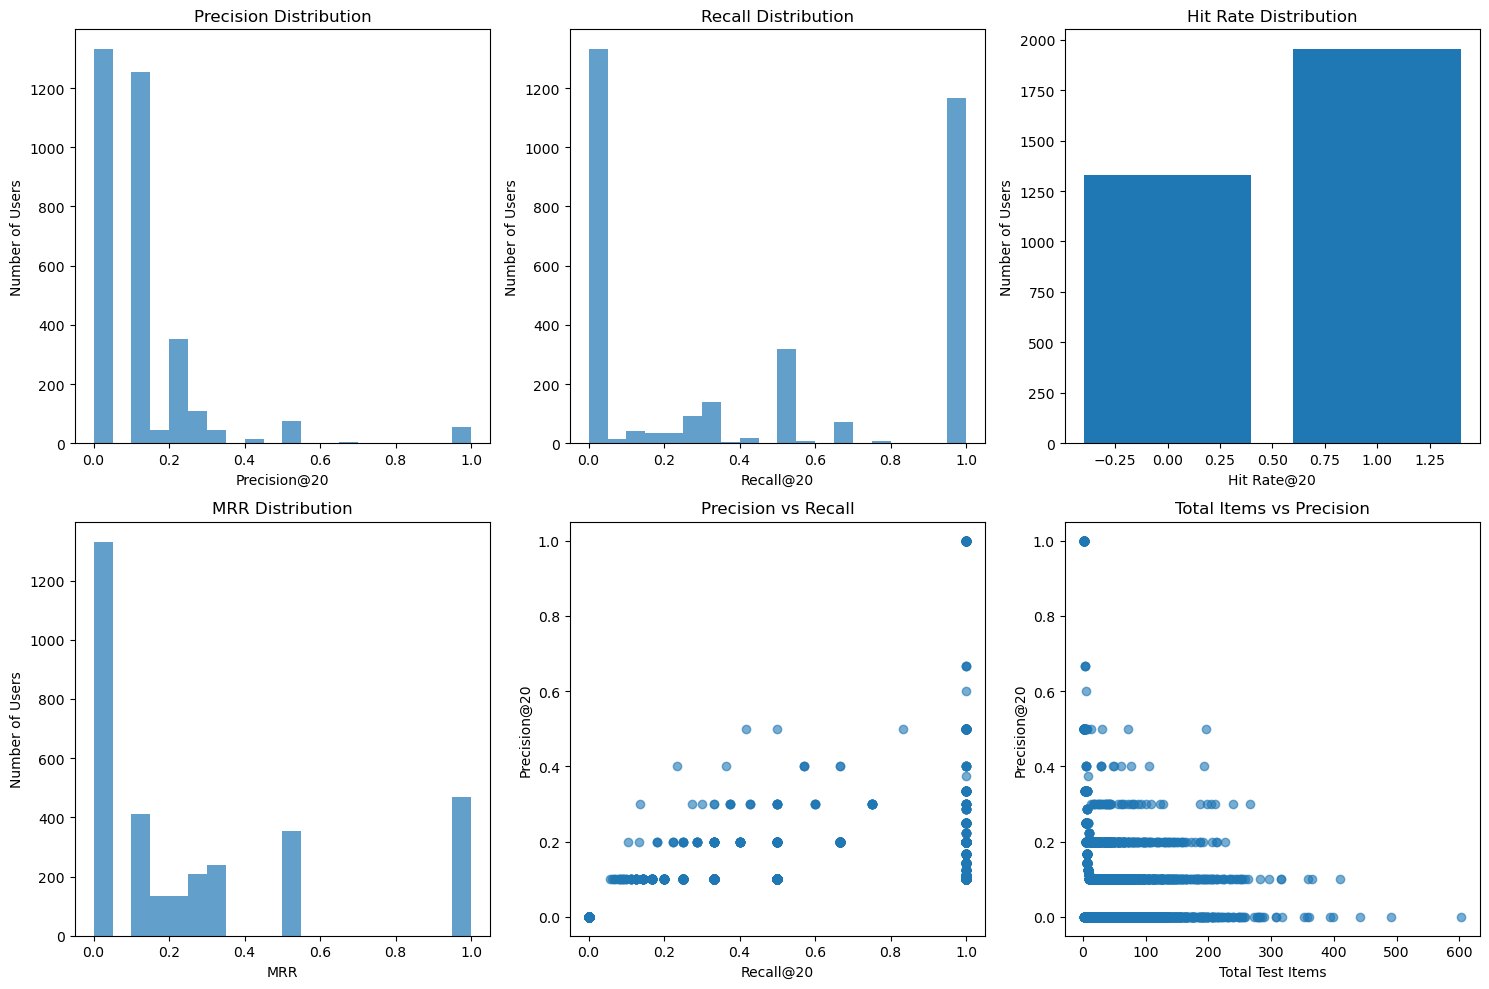


User case analysis completed!


In [23]:
# User Case Analysis(k=20 version)
# Select representative users
representative_users = select_representative_users(all_scores, all_labels, all_users, user2idx)

print("Selected representative users:")
for i, user_idx in enumerate(representative_users[0]):
    print(f"{i+1}. User index: {user_idx}")

# Analyze each representative user
for user_idx in representative_users[0]:
    analyze_user_case(user_idx, all_scores, all_labels, all_users, user2idx, news2idx, test_behaviour_sub, k=20)

# Overall user performance distribution
print(f"\n{'='*60}")
print("Overall User Performance Distribution")
print(f"{'='*60}")

user_metrics = representative_users[1]
if user_metrics:
    precisions = [m['precision'] for m in user_metrics.values()]
    recalls = [m['recall'] for m in user_metrics.values()]
    hit_rates = [m['hit_rate'] for m in user_metrics.values()]
    mrrs = [m['mrr'] for m in user_metrics.values()]
    
    print(f"Precision distribution:")
    print(f"- Mean: {np.mean(precisions):.4f}")
    print(f"- Std: {np.std(precisions):.4f}")
    print(f"- Min: {np.min(precisions):.4f}")
    print(f"- Max: {np.max(precisions):.4f}")
    
    print(f"\nRecall distribution:")
    print(f"- Mean: {np.mean(recalls):.4f}")
    print(f"- Std: {np.std(recalls):.4f}")
    print(f"- Min: {np.min(recalls):.4f}")
    print(f"- Max: {np.max(recalls):.4f}")
    
    print(f"\nHit Rate distribution:")
    print(f"- Mean: {np.mean(hit_rates):.4f}")
    print(f"- Std: {np.std(hit_rates):.4f}")
    
    print(f"\nMRR distribution:")
    print(f"- Mean: {np.mean(mrrs):.4f}")
    print(f"- Std: {np.std(mrrs):.4f}")
    print(f"- Min: {np.min(mrrs):.4f}")
    print(f"- Max: {np.max(mrrs):.4f}")

# Visualization
plt.figure(figsize=(15, 10))

# Precision distribution
plt.subplot(2, 3, 1)
plt.hist([m['precision'] for m in user_metrics.values()], bins=20, alpha=0.7)
plt.title('Precision Distribution')
plt.xlabel('Precision@20')
plt.ylabel('Number of Users')

# Recall distribution
plt.subplot(2, 3, 2)
plt.hist([m['recall'] for m in user_metrics.values()], bins=20, alpha=0.7)
plt.title('Recall Distribution')
plt.xlabel('Recall@20')
plt.ylabel('Number of Users')

# Hit Rate distribution
plt.subplot(2, 3, 3)
hit_rate_counts = Counter([m['hit_rate'] for m in user_metrics.values()])
plt.bar(hit_rate_counts.keys(), hit_rate_counts.values())
plt.title('Hit Rate Distribution')
plt.xlabel('Hit Rate@20')
plt.ylabel('Number of Users')

# MRR distribution
plt.subplot(2, 3, 4)
plt.hist([m['mrr'] for m in user_metrics.values()], bins=20, alpha=0.7)
plt.title('MRR Distribution')
plt.xlabel('MRR')
plt.ylabel('Number of Users')

# Precision vs Recall scatter
plt.subplot(2, 3, 5)
precisions = [m['precision'] for m in user_metrics.values()]
recalls = [m['recall'] for m in user_metrics.values()]
plt.scatter(recalls, precisions, alpha=0.6)
plt.title('Precision vs Recall')
plt.xlabel('Recall@20')
plt.ylabel('Precision@20')

# Total items vs Precision
plt.subplot(2, 3, 6)
total_items = [m['total_items'] for m in user_metrics.values()]
plt.scatter(total_items, precisions, alpha=0.6)
plt.title('Total Items vs Precision')
plt.xlabel('Total Test Items')
plt.ylabel('Precision@20')

plt.tight_layout()
plt.show()

print(f"\nUser case analysis completed!")


# Coldstart-study: Social-projection + top-popular

## Import data from cache

Load MIND topics and LUT between dbpedia and wikidata

In [24]:
import os
import ast
from collections import defaultdict
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm 
from collections import Counter


from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity, linear_kernel
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from scipy.sparse import csr_matrix
from sklearn.decomposition import TruncatedSVD
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error

from itertools import product
from tqdm.std import tqdm

In [25]:
import json, pathlib

cache = pathlib.Path("./data_cache/MIND_topics_cache.json")

with cache.open("r", encoding="utf-8") as f:
    qid_to_uri = json.load(f)
topicsLUT = qid_to_uri
qids          = list(qid_to_uri.keys())     
dbpedia_uris_loaded  = list(qid_to_uri.values())

print(f"loaded {len(qid_to_uri):,} DBpedia URIs")
print(dbpedia_uris_loaded[:10])                    


loaded 27,759 DBpedia URIs
['<http://dbpedia.org/resource/Dillsburg,_Pennsylvania>', '<http://dbpedia.org/resource/Duluth_City_Council>', '<http://dbpedia.org/resource/Cody_Whitehair>', '<http://dbpedia.org/resource/Intracoastal_Waterway>', '<http://dbpedia.org/resource/County_highway>', '<http://dbpedia.org/resource/Great_Lakes_Brewing_Company>', '<http://dbpedia.org/resource/Steny_Hoyer>', '<http://dbpedia.org/resource/Rhinebeck_(village),_New_York>', '<http://dbpedia.org/resource/Nissan_Pathfinder>', '<http://dbpedia.org/resource/Dolemite>']


In [26]:
DBPEDIA_PREFIX = "http://dbpedia.org/resource/"

def clean_uri(uri):
    if not uri:                             
        return None
    uri = uri.strip("<>").strip()
    if not uri:
        return None
    return uri[len(DBPEDIA_PREFIX):] if uri.startswith(DBPEDIA_PREFIX) else uri


# simplify the URIs and create a list of topics.
topicsLUT_stripped = {}
for qid, raw_uri in topicsLUT.items():
    short_lbl = clean_uri(raw_uri)
    if short_lbl:                           
        topicsLUT_stripped[qid] = short_lbl

topics_list = list(dict.fromkeys(topicsLUT_stripped.values()))

print(f"Stripped LUT size : {len(topicsLUT_stripped):,}")
print(f"Unique topics     : {len(topics_list):,}")
print("First 5 LUT pairs :", list(topicsLUT_stripped.items())[:5])
print("First 5 topics    :", topics_list[:5])


Stripped LUT size : 27,533
Unique topics     : 27,488
First 5 LUT pairs : [('Q335821', 'Dillsburg,_Pennsylvania'), ('Q5313500', 'Duluth_City_Council'), ('Q22097181', 'Cody_Whitehair'), ('Q756421', 'Intracoastal_Waterway'), ('Q800071', 'County_highway')]
First 5 topics    : ['Dillsburg,_Pennsylvania', 'Duluth_City_Council', 'Cody_Whitehair', 'Intracoastal_Waterway', 'County_highway']


In [27]:
dbpedia_uris = dbpedia_uris_loaded


Load Behaviours

In [28]:
MIND_behaviour_df = pd.read_csv("./data_cache/behaviours_df.csv", encoding='utf-8')
MIND_behaviour_df.shape
MIND_behaviour_df.head()

,impression_id,user_id,time,history,impressions
0,1,U13740,11/11/2019 9:05:58 AM,N55189 N42782 N34694 N45794 N18445 N63302 N104...,N55689-1 N35729-0
1,2,U91836,11/12/2019 6:11:30 PM,N31739 N6072 N63045 N23979 N35656 N43353 N8129...,N20678-0 N39317-0 N58114-0 N20495-0 N42977-0 N...
2,3,U73700,11/14/2019 7:01:48 AM,N10732 N25792 N7563 N21087 N41087 N5445 N60384...,N50014-0 N23877-0 N35389-0 N49712-0 N16844-0 N...
3,4,U34670,11/11/2019 5:28:05 AM,N45729 N2203 N871 N53880 N41375 N43142 N33013 ...,N35729-0 N33632-0 N49685-1 N27581-0
4,5,U8125,11/12/2019 4:11:21 PM,N10078 N56514 N14904 N33740,N39985-0 N36050-0 N16096-0 N8400-1 N22407-0 N6...


Import TweetsKb data


In [29]:

tweetsKB_df = pd.read_csv(
    './data_cache/tweetsKB_nov2019.csv',
    encoding='utf-8'
)

print("Loaded TweetsKB with", len(tweetsKB_df), "records")

Loaded TweetsKB with 370975 records


## Create train/test splits from tweets data

In [30]:
DBPEDIA_PREFIX = "http://dbpedia.org/resource/"
def strip_dbpedia(uri_list):
    return [
        uri[len(DBPEDIA_PREFIX):] if uri.startswith(DBPEDIA_PREFIX) else uri
        for uri in uri_list
    ]
def add_dbpedia(label_list):
    return [
        lbl if lbl.startswith("http://") else f"{DBPEDIA_PREFIX}{lbl}"
        for lbl in label_list
    ]

In [31]:
split_date = '2019-11-14'

Create tweets train/test split

In [32]:


tweetsKB_df['time_dt'] = pd.to_datetime(tweetsKB_df['time_created'], errors='coerce')
split_date_pd = pd.Timestamp(split_date)

# before split date -> train
tweetsKB_train = tweetsKB_df[tweetsKB_df['time_dt'] < split_date_pd].copy()

# all else can be used in testing (in reality not used)
tweetsKB_test  = tweetsKB_df.copy()

# time information no longer needed.
tweetsKB_train.drop(columns='time_dt', inplace=True)
tweetsKB_test.drop(columns='time_dt', inplace=True)
print("TweetsKB train set:", len(tweetsKB_train), "records")
print("TweetsKB test set:", len(tweetsKB_test), "records")
tweetsKB_train.head()

TweetsKB train set: 162234 records
TweetsKB test set: 370975 records


,postid,userid,time_created,tweet_uris
0,f7624977c25324dc8a1438b9f6bda24b4b32445,648fbaccf58ac0e11fbae79a0f0312c1,2019-11-01T17:43:49,['http://dbpedia.org/resource/Twenty_One_Pilot...
1,f7624977c25324dc8a1438b9f6bda24b4b1951,3cdcb1b6866f111b9c6622ada976a635,2019-11-01T00:59:38,['http://dbpedia.org/resource/Harry_Styles']
2,f7624977c25324dc8a1438b9f6bda24b4b33617,b5d06e1a7dacc4328204310e12119647,2019-11-01T18:11:31,['http://dbpedia.org/resource/Offensive_coordi...
3,f7624977c25324dc8a1438b9f6bda24b4b15343,c22741b1e720be2f58bb10370b90ced3,2019-11-01T09:12:00,"['http://dbpedia.org/resource/Halloween', 'htt..."
4,f7624977c25324dc8a1438b9f6bda24b4b14851,33ca61d84dfc53d3e4b97b3c1f0b7bf1,2019-11-01T08:46:37,['http://dbpedia.org/resource/Jungkook']


In [33]:

def parse_uri_list(cell):
    if isinstance(cell, str) and cell.strip():
        try:
            return ast.literal_eval(cell)     
        except (SyntaxError, ValueError):
            return []
    return []                                 

# parse
tweetsKB_train["uri_list"] = tweetsKB_train["tweet_uris"].apply(parse_uri_list)

# aggregate by user
tweets_user_df = (
    tweetsKB_train.groupby("userid", sort=False)["uri_list"]
             .sum()                      
             .reset_index()
             .rename(columns={"userid": "user",
                              "uri_list": "train"})
)
tweets_user_df['train'] = tweets_user_df['train'].apply(strip_dbpedia)
tweets_user_df = tweets_user_df[tweets_user_df["train"].apply(len) > 2].reset_index(drop=True)
print(len(tweets_user_df), "users with more than one tweet URI")
tweets_user_df.tail()
tweetsKB_train_original = tweets_user_df.copy()

8698 users with more than one tweet URI


In [34]:
tweetsKB_train_original.head()

,user,train
0,648fbaccf58ac0e11fbae79a0f0312c1,"[Twenty_One_Pilots, Phonograph_record, Twitter]"
1,3cdcb1b6866f111b9c6622ada976a635,"[Harry_Styles, Harry_Styles, Harry_Styles]"
2,3ae2657a0b6e9f29e7b1bab36b4d5dc5,"[Ethiopia, Real_estate, Big_Boi, Epic_Records,..."
3,37af5b93b58730895ac8657d36083801,"[Halloween, Twitter, Twitter]"
4,2563d0df0ac240c83d61ca7500b0b4f3,"[2020_Summer_Olympics, Sega, Nintendo_Switch]"


## Eda of data

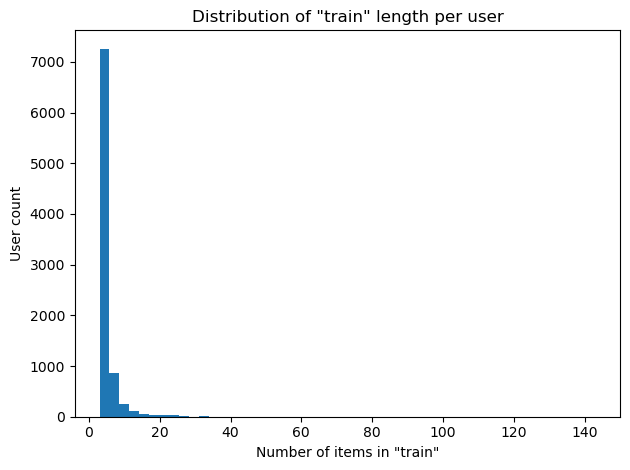

,entity,count
0,Twitter,2757
1,BTS,1728
2,Midfielder,999
3,Donald_Trump,729
4,Impeachment,684
5,YouTube,447
6,President_of_the_United_States,401
7,Jungkook,334
8,CNN,331
9,Racism,252


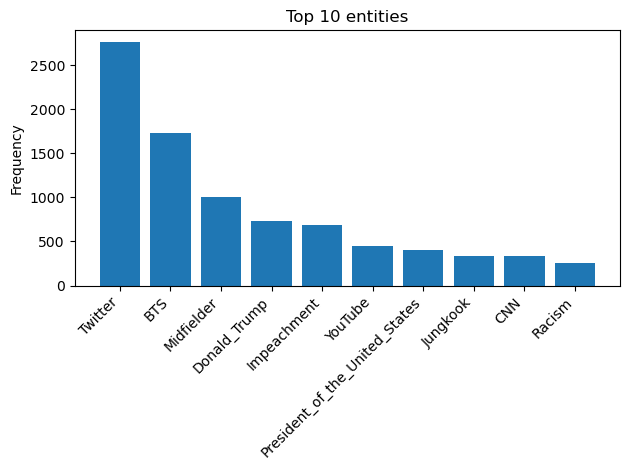

In [35]:

# --- config ---------------------------------------------------------
DF          = tweetsKB_train_original.copy()
TRAIN_COL   = "train"       
ENTITY_COL  = "train"    
TOP_K       = 10            # top entities
# -------------------------------------------------------------------

def _to_list(x):
    if x is None or (isinstance(x, float) and np.isnan(x)):
        return []
    if isinstance(x, list):
        return x
    if isinstance(x, str):
        s = x.strip()
        if s == "":
            return []
        try:
            v = ast.literal_eval(s)
            if isinstance(v, list):
                return v
        except Exception:
            pass
        return s.split()
    return list(x) if hasattr(x, "__iter__") else [x]

# plot distribution of items in "train" per user 
DF["_train_list"] = DF[TRAIN_COL].apply(_to_list)
train_lengths = DF["_train_list"].apply(len)

plt.figure()
plt.hist(train_lengths.values, bins=50)
plt.xlabel(f'Number of items in "{TRAIN_COL}"')
plt.ylabel("User count")
plt.title(f'Distribution of "{TRAIN_COL}" length per user')
plt.tight_layout()
plt.show()

# top entities
if ENTITY_COL not in DF.columns:
    raise KeyError(f'Column "{ENTITY_COL}" not found. Set ENTITY_COL to your entities column.')

DF["_entities_list"] = DF[ENTITY_COL].apply(_to_list)

cnt = Counter()
for ents in DF["_entities_list"]:
    cnt.update(ents)

top_entities = cnt.most_common(TOP_K)
top_entities_df = pd.DataFrame(top_entities, columns=["entity", "count"])
display(top_entities_df)

# Bar plot of top entities
labels = top_entities_df["entity"].astype(str).tolist()
counts = top_entities_df["count"].tolist()

plt.figure()
plt.bar(range(len(labels)), counts)
plt.xticks(range(len(labels)), labels, rotation=45, ha="right")
plt.ylabel("Frequency")
plt.title(f"Top {TOP_K} entities")
plt.tight_layout()
plt.show()


## Create MIND users train/test split

In [36]:
MIND_behaviour_df["time"] = pd.to_datetime(MIND_behaviour_df["time"], errors="coerce")

earliest = MIND_behaviour_df["time"].min()
latest   = MIND_behaviour_df["time"].max()

print(f"Earliest interaction : {earliest:%Y-%m-%d %H:%M:%S}")
print(f"Latest   interaction : {latest:%Y-%m-%d %H:%M:%S}")


Earliest interaction : 2019-11-09 00:00:19
Latest   interaction : 2019-11-14 23:59:13


In [37]:
def _collect_user(group):
    """for each user, history = train, impressions = test"""
    train_list = []     
    test_set  = set()     

    # Iterate over that user's sessions
    for hist, imps in zip(group['history'], group['impressions']):
        if len(train_list) == 0:
            train_list= hist.split()

        # Add only clicks
        for token in imps.split():
            if token.endswith("-1"):            
                news_id = token.split("-")[0]   
                test_set.add(news_id)

    return pd.Series({
        "train_topics": train_list,
        "test" : list(test_set)
    })

#create the per‑user dataframe
MIND_behaviour_df['history']     = MIND_behaviour_df['history'].fillna('')
MIND_behaviour_df['impressions'] = MIND_behaviour_df['impressions'].fillna('')
MIND_user_df = (
    MIND_behaviour_df.groupby('user_id', sort=False)  
      .apply(_collect_user)            
      .reset_index()                   
)
MIND_user_df_orig = MIND_user_df.copy() 
MIND_user_df_orig.head()

/tmp/ipykernel_4210/421763620.py:27: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(_collect_user)


,user_id,train_topics,test
0,U13740,"[N55189, N42782, N34694, N45794, N18445, N6330...","[N28910, N58133, N55689]"
1,U91836,"[N31739, N6072, N63045, N23979, N35656, N43353...","[N14029, N27601, N33212, N28820, N37190, N3388..."
2,U73700,"[N10732, N25792, N7563, N21087, N41087, N5445,...","[N47817, N34117, N23814]"
3,U34670,"[N45729, N2203, N871, N53880, N41375, N43142, ...","[N32544, N62360, N53585, N49685]"
4,U8125,"[N10078, N56514, N14904, N33740]",[N8400]


## Restrict dataset for cold-start study

In [38]:
def move_until_keep_n(df, N, train_col='train_topics', test_col='test', in_place=False):
    d = df.copy(deep=True)  # always work on a copy so the original is unchanged
    for idx in d.index:
        train = list(d.at[idx, train_col])  # copy lists so we don't mutate originals
        test  = list(d.at[idx, test_col])
        while len(train) > N:
            train.pop(0)  
            
        d.at[idx, train_col] = train
        d.at[idx, test_col]  = test
    return d

MIND_user_df_0 = move_until_keep_n(MIND_user_df_orig, 0, train_col='train_topics', test_col='test', in_place=False)
MIND_user_df_1 = move_until_keep_n(MIND_user_df_orig, 1, train_col='train_topics', test_col='test', in_place=False)
MIND_user_df_3 = move_until_keep_n(MIND_user_df_orig, 3, train_col='train_topics', test_col='test', in_place=False)
MIND_user_df_5 = move_until_keep_n(MIND_user_df_orig, 5, train_col='train_topics', test_col='test', in_place=False)
MIND_user_df_7 = move_until_keep_n(MIND_user_df_orig, 7, train_col='train_topics', test_col='test', in_place=False)
MIND_user_df_orig_copy = MIND_user_df_orig.copy()  
MIND_user_df_5.head()  #expect 5 train 5 test

,user_id,train_topics,test
0,U13740,"[N18445, N63302, N10414, N19347, N31801]","[N28910, N58133, N55689]"
1,U91836,"[N37509, N21773, N41011, N19041, N25785]","[N14029, N27601, N33212, N28820, N37190, N3388..."
2,U73700,"[N24233, N62058, N26378, N49475, N18870]","[N47817, N34117, N23814]"
3,U34670,"[N43142, N33013, N29757, N31825, N51891]","[N32544, N62360, N53585, N49685]"
4,U8125,"[N10078, N56514, N14904, N33740]",[N8400]


match news to entities

In [39]:
MIND_news_df = pd.read_csv("./data_cache/MIND_news_df.csv", encoding='utf-8')
MIND_news_df_inspect = MIND_news_df.copy()  # keep the original for later
MIND_news_df.head()
MIND_news_df["all_entity_ids"] = (
    MIND_news_df["all_entity_ids"]
      .fillna("[]")                          
      .apply(ast.literal_eval)               
)

topicsLUT_clean = {k: v.strip("<>") for k, v in topicsLUT.items() if v}
MIND_news_df["entity_uris"] = MIND_news_df["all_entity_ids"].apply(
    lambda qids: [topicsLUT_clean.get(qid, qid) for qid in qids]
)
MIND_news_df["entity_uris"] = MIND_news_df["entity_uris"].apply(strip_dbpedia)
MIND_news_df.head()

,news_id,all_entity_ids,entity_uris
0,N55528,"[Q80976, Q43274, Q9682]","[Prince_Philip,_Duke_of_Edinburgh, Charles_III..."
1,N19639,[Q193583],[Adipose_tissue]
2,N61837,[Q212],[Ukrainian_Soviet_Socialist_Republic]
3,N53526,[Q155223],[National_Basketball_Association]
4,N38324,"[Q3179593, Q371820, Q171171]","[Skin_tag, Reader's_Digest, Dermatology]"


convert a users' news into entity lists

In [40]:
def apply_news_topics(user_df, news_df):
    news2topics = dict(zip(news_df["news_id"], news_df["entity_uris"]))
    def news_ids_to_topics(news_id_list):
        topics = []
        for nid in news_id_list:
            topics.extend(news2topics.get(nid, []))
        return topics
    user_df["train"] = user_df["train_topics"].apply(news_ids_to_topics)
    user_df["train"] = user_df["train"].apply(strip_dbpedia)
    user_df.rename(columns={"user_id": "user"}, inplace=True)
    return user_df
MIND_user_df_0 = apply_news_topics(MIND_user_df_0, MIND_news_df)
MIND_user_df_1 = apply_news_topics(MIND_user_df_1, MIND_news_df)
MIND_user_df_3 = apply_news_topics(MIND_user_df_3, MIND_news_df)
MIND_user_df_5 = apply_news_topics(MIND_user_df_5, MIND_news_df)
MIND_user_df_7 = apply_news_topics(MIND_user_df_7, MIND_news_df)
MIND_user_df_orig_copy = apply_news_topics(MIND_user_df_orig_copy, MIND_news_df)
MIND_user_df_5.head()

,user,train_topics,test,train
0,U13740,"[N18445, N63302, N10414, N19347, N31801]","[N28910, N58133, N55689]","[Urban_Cowboy, Paramount_chief, Paramount_Pict..."
1,U91836,"[N37509, N21773, N41011, N19041, N25785]","[N14029, N27601, N33212, N28820, N37190, N3388...","[Hawaiian_Islands, Hilo,_Hawaii, Interstate_71..."
2,U73700,"[N24233, N62058, N26378, N49475, N18870]","[N47817, N34117, N23814]","[Billionaires'_Row_(Manhattan), Manhattan, Lam..."
3,U34670,"[N43142, N33013, N29757, N31825, N51891]","[N32544, N62360, N53585, N49685]","[Jim_Farmer, National_Basketball_Association, ..."
4,U8125,"[N10078, N56514, N14904, N33740]",[N8400],"[Second_Temple, Jerusalem, Roman_governor]"


## Train social-CF 

gridsearch for optimal values for latent state

In [41]:

from sklearn.decomposition import TruncatedSVD
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error
from scipy.sparse import csr_matrix

# ------------------------------------------------------------------
#  CONFIGURATION
# ------------------------------------------------------------------
candidate_k  = [100, 500, 1000]   # latent dims to try
n_splits     = 5                                # K‑fold CV
random_state = 42                               
# ------------------------------------------------------------------

#  explode tweets_user_df 
long_df = (
    tweets_user_df[["user", "train"]]
      .explode("train", ignore_index=True)
      .rename(columns={"train": "topic"})
)

#  count occurrences 
long_df["cnt"] = 1
freq_df = long_df.groupby(["user", "topic"], as_index=False)["cnt"].sum()

# integer‑encode users & topics
user_index  = {u: i for i, u in enumerate(freq_df["user"].unique())}
topic_index = {t: j for j, t in enumerate(topics_list)}  

rows  = freq_df["user"].map(user_index)
cols  = freq_df["topic"].map(topic_index)
data  = freq_df["cnt"].values

X = csr_matrix((data, (rows, cols)),
               shape=(len(user_index), len(topic_index)),
               dtype=float)


#  CROSS‑VALIDATION TO CHOOSE BEST n_components

kf = KFold(n_splits=n_splits, shuffle=True, random_state=random_state)
cv_rows = []

for k in tqdm(candidate_k, desc="CV n_components"):
    train_mses, test_mses = [], []
    for train_idx, test_idx in kf.split(X):
        svd = TruncatedSVD(n_components=k, random_state=random_state)
        svd.fit(X[train_idx])

        # reconstruct train / test folds
        X_train_rec = svd.inverse_transform(svd.transform(X[train_idx]))
        X_test_rec  = svd.inverse_transform(svd.transform(X[test_idx]))

        train_mses.append(
            mean_squared_error(X[train_idx].toarray(), X_train_rec)
        )
        test_mses.append(
            mean_squared_error(X[test_idx].toarray(),  X_test_rec)
        )

    cv_rows.append({
        "k": k,
        "train_mse": np.mean(train_mses),
        "test_mse":  np.mean(test_mses),
    })

cv_df  = pd.DataFrame(cv_rows).sort_values("k")
best_k = cv_df.loc[cv_df["test_mse"].idxmin(), "k"]

print("Cross-validation summary:")
display(cv_df)
print(f"Best latent dimension (lowest test MSE): k = {best_k}")



CV n_components: 100%|██████████| 3/3 [01:12<00:00, 24.13s/it]

Cross-validation summary:


,k,train_mse,test_mse
0,100,0.000107,0.000128
1,500,0.000044,0.000067
2,1000,0.000022,0.000046


Best latent dimension (lowest test MSE): k = 1000


run with optimised values

In [42]:


# ---------- CONFIG -------------------------------------------------
n_components = 1000          # latent dimension k 
random_state = 42
# -------------------------------------------------------------------

#  explode tweets_user_df
long_df = (
    tweets_user_df[["user", "train"]]
      .explode("train", ignore_index=True)
      .rename(columns={"train": "topic"})
)

#  count occurrences (duplicates → frequencies)
long_df["cnt"] = 1
freq_df = long_df.groupby(["user", "topic"], as_index=False)["cnt"].sum()

# integer‑encode users & topics
user_index   = {u: i for i, u in enumerate(freq_df["user"].unique())}
topic_index  = {t: j for j, t in enumerate(topics_list)}   # global vocab

rows   = freq_df["user"].map(user_index)
cols   = freq_df["topic"].map(topic_index)
data   = freq_df["cnt"].values

X = csr_matrix((data, (rows, cols)),
               shape=(len(user_index), len(topic_index)),
               dtype=float)

#fit truncated SVD
svd = TruncatedSVD(n_components=n_components, random_state=random_state)
svd.fit(X)

print(f"Training complete : {n_components} latent dims, "
      f"explained variance : {svd.explained_variance_ratio_.sum():.2%}")


Training complete : 1000 latent dims, explained variance : 92.27%


## Project User Preferences onto social-CF

In [43]:
from collections import Counter


def get_user_recs(                               
    uid,
    MIND_user_df,
    topic_index,
    topics_list,
    svd,                       
    N=10,
    topic_col="train",
    user_col="user",
):
    def get_interest_vector(uid, df, topic_index,
                            topic_col="train", user_col="user"):
        counter = Counter()
        row = df.loc[df[user_col] == uid]
        if not row.empty:
            counter.update(row.iloc[0][topic_col])   
        vec = np.zeros(len(topic_index), dtype=float)
        for t, f in counter.items():
            col = topic_index.get(t)
            if col is not None:
                vec[col] = f
        return vec, counter

    # build interest vector & original counts
    u_vec, orig_counts = get_interest_vector(uid, MIND_user_df, topic_index)

    # project through trained SVD to get predicted scores
    latent_u        = svd.transform(u_vec.reshape(1, -1))
    pred_scores_all = svd.inverse_transform(latent_u)[0]          

    topics_all = np.array(topics_list)
    top_idx_all      = np.argsort(pred_scores_all)[-N:][::-1]
    diverse_topics   = list(topics_all[top_idx_all])

    # recommended = top‑N unseen and top-N overall.
    seen_topics      = set(orig_counts)
    mask_unseen      = np.array([t not in seen_topics for t in topics_list])
    scores_unseen    = pred_scores_all[mask_unseen]
    topics_unseen    = topics_all[mask_unseen]
    top_idx_unseen   = np.argsort(scores_unseen)[-N:][::-1]
    recommended_topics = list(topics_unseen[top_idx_unseen])

    return recommended_topics, diverse_topics


def add_recommendations(
    MIND_users_df,
    topic_index,
    topics_list,
    svd,
    N=10,
    test_first_10=False,
    test_users=1000
):

    out_df = MIND_users_df.copy()

    # unique user IDs present in the DataFrame
    user_ids = out_df["user"].unique()
    if test_first_10:
        user_ids = user_ids[:test_users]

    # pre‑allocate empty columns
    out_df["recommended_topics"] = None
    out_df["diverse_topics"]     = None

    for uid in tqdm(user_ids, desc="Building recommendations"):
        div_topics, rec_topics = get_user_recs(
            uid, out_df, topic_index, topics_list, svd, N=N
        )

        # fill all rows that belong to this user (if duplicates exist)
        mask        = out_df["user"] == uid
        row_indices = out_df.index[mask]

        out_df.loc[row_indices, "recommended_topics"] = pd.Series(
            [rec_topics] * len(row_indices), index=row_indices, dtype=object
        )
        out_df.loc[row_indices, "diverse_topics"] = pd.Series(
            [div_topics] * len(row_indices), index=row_indices, dtype=object
        )


    return out_df


## From recommended topics, get top-N recommended news

In [44]:
top_n_articles = 10       
top_m_topics   = None       # None = use every recommended topic
test_first_10  = True       # for testing
random_state   = 42         

In [45]:
def recommend_news_by_topics(
    news_df,
    pred_df,
    top_n_articles=10,
    top_m_topics=None,
    test_first_10=True,
    random_state=42,
    topic_source="train",
    seen_col="train_topics",
    test_users=100,
):
    def _ensure_list(x):
        if isinstance(x, list): return x
        if isinstance(x, str):
            try: return ast.literal_eval(x)
            except Exception: return []
        if x is None or (isinstance(x, float) and pd.isna(x)): return []
        return list(x)

    rng = np.random.default_rng(random_state) if random_state is not None else None

    news_df = news_df.copy()
    news_ids = news_df["news_id"].to_numpy()
    news_entsets = news_df["entity_uris"].apply(_ensure_list).apply(set).to_numpy()

    work_df = pred_df.copy()
    if test_first_10:
        first_users = work_df["user"].unique()[:test_users]
        work_df = work_df[work_df["user"].isin(first_users)].reset_index(drop=True)

    # Use all topics if source is 'train'; otherwise respect top_m_topics
    eff_top_m = None if topic_source == "train" else top_m_topics

    def _score_story(rec_topics, ent_set):
        if not rec_topics:
            return 0.0
        if eff_top_m is not None:
            rec_topics = rec_topics[:eff_top_m]
        weights = {t: (len(rec_topics) - i) for i, t in enumerate(rec_topics)}
        return float(sum(weights[t] for t in ent_set if t in weights))

    results = []
    for row in tqdm(work_df.itertuples(index=False), total=len(work_df), desc="Scoring"):
        uid = row.user
        rec_topics = _ensure_list(getattr(row, topic_source, []))

        scores = np.fromiter((_score_story(rec_topics, es) for es in news_entsets),
                             dtype=float, count=len(news_entsets))

        seen_news = _ensure_list(getattr(row, seen_col, []))
        if seen_news:
            scores[np.isin(news_ids, seen_news)] = -np.inf

        if rng is not None:
            finite_mask = np.isfinite(scores)
            scores[finite_mask] = scores[finite_mask] + 1e-12 * rng.random(finite_mask.sum())

        pos_idx = np.where(scores > 0)[0]
        if pos_idx.size > 0:
            k = min(top_n_articles, pos_idx.size)
            top_idx = pos_idx[np.argpartition(-scores[pos_idx], k-1)[:k]]
            order = np.argsort(-scores[top_idx], kind="mergesort")
            sel = top_idx[order]
            rec_news_ids    = news_ids[sel].tolist()
            rec_news_scores = scores[sel].tolist()
        else:
            rec_news_ids, rec_news_scores = [], []

        results.append({
            "user": uid,
            "test": getattr(row, "test", None),
            "train": getattr(row, "train", None),
            "train_topics": getattr(row, "train_topics", None),
            "recommended_news": rec_news_ids,
            "news_scores": rec_news_scores,
        })

    return pd.DataFrame(results)

compile recommendations

In [46]:
MIND_prediction_df_test_1    = add_recommendations(MIND_user_df_1, topic_index, topics_list, svd,
                                  N=20, test_first_10=True, test_users=10000)
MIND_prediction_df_test_3    = add_recommendations(MIND_user_df_3, topic_index, topics_list, svd,
                                  N=20, test_first_10=True, test_users=10000)
MIND_prediction_df_test_5    = add_recommendations(MIND_user_df_5, topic_index, topics_list, svd,
                                  N=20, test_first_10=True, test_users=10000)
MIND_prediction_df_test_7    = add_recommendations(MIND_user_df_7, topic_index, topics_list, svd,
                                  N=20, test_first_10=True, test_users=10000)
MIND_prediction_df_test_orig = add_recommendations(MIND_user_df_orig_copy, topic_index, topics_list, svd,
                                  N=20, test_first_10=True, test_users=10000)

Building recommendations:   0%|          | 0/10000 [00:00<?, ?it/s]

Building recommendations: 100%|██████████| 10000/10000 [25:11<00:00,  6.62it/s]


## Create Metrics Functions

In [47]:
# helper fns
def _to_list(x):
    if isinstance(x, list): return x
    if isinstance(x, str):
        try: return ast.literal_eval(x)
        except Exception: return []
    if x is None or (isinstance(x, float) and pd.isna(x)): return []
    return list(x)

def _precision_at_k(hits):
    return hits.mean()  

def _recall_at_k(hits, num_relevant):
    return hits.sum() / num_relevant if num_relevant else np.nan

def _ndcg_at_k(hits, num_relevant):
    if num_relevant == 0:
        return np.nan
    discounts = 1 / np.log2(np.arange(2, len(hits) + 2))
    dcg  = (hits * discounts).sum()
    ideal_len = int(min(len(hits), num_relevant))
    idcg = (np.ones(ideal_len) * discounts[:ideal_len]).sum()
    return dcg / idcg if idcg else np.nan

def _hit_rate_at_k(hits, num_relevant):
    return float(hits.sum() > 0) if num_relevant else np.nan

def _mrr_at_k(hits, num_relevant):
    if num_relevant == 0:
        return np.nan
    idx = np.where(hits == 1)[0]
    return 1.0 / (idx[0] + 1) if idx.size else 0.0

def _auc_at_k(hits):
    m = int(hits.sum())
    n = len(hits) - m
    if m == 0 or n == 0:
        return np.nan
    ranks = np.arange(1, len(hits) + 1)              
    sum_pos = ranks[hits == 1].sum()
    return (sum_pos - m * (m + 1) / 2) / (m * n)

# main metrics function
def add_topN_metrics(df, N):
    precs, recs, ndcgs, hitrs, mrrs, aucs = [], [], [], [], [], []

    for _, row in df.iterrows():
        gt  = _to_list(row["test"])                     
        rec = _to_list(row["recommended_news"])[:N]     

        gt_set = set(gt)
        hits   = np.zeros(N, dtype=float)
        for i, r in enumerate(rec):
            if r in gt_set:
                hits[i] = 1.0

        num_rel = len(gt_set)

        precs.append(_precision_at_k(hits))
        recs.append(_recall_at_k(hits, num_rel))
        ndcgs.append(_ndcg_at_k(hits, num_rel))
        hitrs.append(_hit_rate_at_k(hits, num_rel))
        mrrs.append(_mrr_at_k(hits, num_rel))
        aucs.append(_auc_at_k(hits))

    df["precision@N"] = precs
    df["recall@N"]    = recs
    df["MRR@N"]       = mrrs
    df["hit_rate@N"]  = hitrs
    df["NDCG@N"]      = ndcgs
    df["AUC@N"]       = aucs
    return df



## Run Model on various cold-start scenarios

In [48]:
top_n_articles = 10          
top_m_topics_list   = [10]          # None = use every recommended topic
topic_source_list = ["train",  "diverse_topics", "recommended_topics"]  


results = []
N = top_n_articles 
metric_cols = ["hit_rate@N", "precision@N", "recall@N", "MRR@N", "NDCG@N", "AUC@N"]

combos = list(product(topic_source_list, top_m_topics_list))

for topic_source, top_m_topics in tqdm(combos, total=len(combos), desc="Evaluating settings"):
    user_news_df = recommend_news_by_topics(
        MIND_news_df, MIND_prediction_df_test_orig,
        top_n_articles=top_n_articles, top_m_topics=top_m_topics,
        test_first_10=True, random_state=42,
        topic_source=topic_source, test_users=10000
    )
    user_news_df = add_topN_metrics(user_news_df, N=N)
    m = user_news_df[metric_cols].mean(numeric_only=True)

    row = {"top_m_topics": top_m_topics, "topic_source": topic_source, "users": len(user_news_df)}
    row.update({c: m[c] for c in metric_cols})
    results.append(row)
# Remap topic_source labels for the final display


print(f"Gridsearch results (@N where N={N}), not coldstart")
summary_df_orig = (pd.DataFrame(results)
                  .sort_values(by="NDCG@N", ascending=False)
                  .reset_index(drop=True))
label_map = {
    "train":              "baseline-entity-based",
    "diverse_topics":     "social-aware: exploratory-topics",
    "recommended_topics": "hybrid",
}

summary_df_orig = summary_df_orig.copy()
summary_df_orig["topic_source"] = summary_df_orig["topic_source"].replace(label_map)

display(summary_df_orig)

Evaluating settings: 100%|██████████| 3/3 [38:34<00:00, 771.65s/it]

Gridsearch results (@N where N=10), not coldstart


,top_m_topics,topic_source,users,hit_rate@N,precision@N,recall@N,MRR@N,NDCG@N,AUC@N
0,10,baseline-entity-based,10000,0.0074,0.00077,0.001175,0.002246,0.001040,0.512481
1,10,social-aware: exploratory-topics,10000,0.0055,0.00055,0.000788,0.001998,0.000788,0.432323
2,10,hybrid,10000,0.0040,0.00041,0.000476,0.001383,0.000535,0.441146


In [49]:
top_n_articles = 10          
top_m_topics_list   = [20]         
topic_source_list = ["train",  "diverse_topics", "recommended_topics"]  


results = []
N = top_n_articles 
metric_cols = ["hit_rate@N", "precision@N", "recall@N", "MRR@N", "NDCG@N", "AUC@N"]

combos = list(product(topic_source_list, top_m_topics_list))
for topic_source, top_m_topics in tqdm(combos, total=len(combos), desc="Evaluating settings"):
    user_news_df = recommend_news_by_topics(
        MIND_news_df, MIND_prediction_df_test_1,
        top_n_articles=top_n_articles, top_m_topics=top_m_topics,
        test_first_10=True, random_state=42,
        topic_source=topic_source, test_users=10000
    )
    user_news_df = add_topN_metrics(user_news_df, N=N)
    m = user_news_df[metric_cols].mean(numeric_only=True)

    row = {"top_m_topics": top_m_topics, "topic_source": topic_source, "users": len(user_news_df)}
    row.update({c: m[c] for c in metric_cols})
    results.append(row)
# Remap topic_source labels for the final display


print(f"Gridsearch results (@N where N={N}), Coldstart: only 1 news per user")
summary_df_7 = (pd.DataFrame(results)
                  .sort_values(by="NDCG@N", ascending=False)
                  .reset_index(drop=True))
label_map = {
    "train":              "baseline-entity-based",
    "diverse_topics":     "social-aware: exploratory-topics",
    "recommended_topics": "hybrid",
}

summary_df_7 = summary_df_7.copy()
summary_df_7["topic_source"] = summary_df_7["topic_source"].replace(label_map)

display(summary_df_7)


Evaluating settings: 100%|██████████| 3/3 [22:33<00:00, 451.20s/it]

Gridsearch results (@N where N=10), Coldstart: only 1 news per user


,top_m_topics,topic_source,users,hit_rate@N,precision@N,recall@N,MRR@N,NDCG@N,AUC@N
0,20,baseline-entity-based,10000,0.0065,0.00068,0.000758,0.002422,0.000962,0.412821
1,20,hybrid,10000,0.0049,0.00050,0.000782,0.001635,0.000778,0.435516
2,20,social-aware: exploratory-topics,10000,0.0024,0.00025,0.000427,0.000912,0.000442,0.450810


In [50]:
top_n_articles = 10         
top_m_topics_list   = [20]          
topic_source_list = ["train",  "diverse_topics", "recommended_topics"]  


results = []
N = top_n_articles  
metric_cols = ["hit_rate@N", "precision@N", "recall@N", "MRR@N", "NDCG@N", "AUC@N"]


combos = list(product(topic_source_list, top_m_topics_list))
for topic_source, top_m_topics in tqdm(combos, total=len(combos), desc="Evaluating settings"):
    user_news_df = recommend_news_by_topics(
        MIND_news_df, MIND_prediction_df_test_3,
        top_n_articles=top_n_articles, top_m_topics=top_m_topics,
        test_first_10=True, random_state=42,
        topic_source=topic_source, test_users=10000
    )
    user_news_df = add_topN_metrics(user_news_df, N=N)
    m = user_news_df[metric_cols].mean(numeric_only=True)

    row = {"top_m_topics": top_m_topics, "topic_source": topic_source, "users": len(user_news_df)}
    row.update({c: m[c] for c in metric_cols})
    results.append(row)
# Remap topic_source labels for the final display

print(f"Gridsearch results (@N where N={N}), Coldstart: only 3 news per user")
summary_df_7 = (pd.DataFrame(results)
                  .sort_values(by="NDCG@N", ascending=False)
                  .reset_index(drop=True))
label_map = {
    "train":              "baseline-entity-based",
    "diverse_topics":     "social-aware: exploratory-topics",
    "recommended_topics": "hybrid",
}

summary_df_7 = summary_df_7.copy()
summary_df_7["topic_source"] = summary_df_7["topic_source"].replace(label_map)

display(summary_df_7)

Evaluating settings: 100%|██████████| 3/3 [24:44<00:00, 494.68s/it]

Gridsearch results (@N where N=10), Coldstart: only 3 news per user


,top_m_topics,topic_source,users,hit_rate@N,precision@N,recall@N,MRR@N,NDCG@N,AUC@N
0,20,baseline-entity-based,10000,0.0116,0.00119,0.001751,0.004385,0.001884,0.428281
1,20,hybrid,10000,0.0063,0.00063,0.001074,0.002130,0.000950,0.486772
2,20,social-aware: exploratory-topics,10000,0.0026,0.00027,0.000310,0.001166,0.000413,0.416132


In [51]:
top_n_articles = 10          
top_m_topics_list   = [20]         
topic_source_list = ["train",  "diverse_topics", "recommended_topics"]  


results = []
N = top_n_articles  
metric_cols = ["hit_rate@N", "precision@N", "recall@N", "MRR@N", "NDCG@N", "AUC@N"]


combos = list(product(topic_source_list, top_m_topics_list))
for topic_source, top_m_topics in tqdm(combos, total=len(combos), desc="Evaluating settings"):
    user_news_df = recommend_news_by_topics(
        MIND_news_df, MIND_prediction_df_test_5,
        top_n_articles=top_n_articles, top_m_topics=top_m_topics,
        test_first_10=True, random_state=42,
        topic_source=topic_source, test_users=10000
    )
    user_news_df = add_topN_metrics(user_news_df, N=N)
    m = user_news_df[metric_cols].mean(numeric_only=True)

    row = {"top_m_topics": top_m_topics, "topic_source": topic_source, "users": len(user_news_df)}
    row.update({c: m[c] for c in metric_cols})
    results.append(row)
# Remap topic_source labels for the final display

print(f"Gridsearch results (@N where N={N}), Coldstart: only 5 news per user")
summary_df_7 = (pd.DataFrame(results)
                  .sort_values(by="NDCG@N", ascending=False)
                  .reset_index(drop=True))
label_map = {
    "train":              "baseline-entity-based",
    "diverse_topics":     "social-aware: exploratory-topics",
    "recommended_topics": "hybrid",
}

summary_df_7 = summary_df_7.copy()
summary_df_7["topic_source"] = summary_df_7["topic_source"].replace(label_map)

display(summary_df_7)

Evaluating settings: 100%|██████████| 3/3 [26:18<00:00, 526.19s/it]

Gridsearch results (@N where N=10), Coldstart: only 5 news per user


,top_m_topics,topic_source,users,hit_rate@N,precision@N,recall@N,MRR@N,NDCG@N,AUC@N
0,20,baseline-entity-based,10000,0.0135,0.00139,0.002140,0.004729,0.002127,0.419496
1,20,hybrid,10000,0.0067,0.00068,0.000774,0.002021,0.000838,0.481447
2,20,social-aware: exploratory-topics,10000,0.0041,0.00042,0.000442,0.001513,0.000556,0.454776


In [52]:
top_n_articles = 10          
top_m_topics_list   = [20]          
topic_source_list = ["train",  "diverse_topics", "recommended_topics"]  

results = []
N = top_n_articles
metric_cols = ["hit_rate@N", "precision@N", "recall@N", "MRR@N", "NDCG@N", "AUC@N"]


combos = list(product(topic_source_list, top_m_topics_list))
for topic_source, top_m_topics in tqdm(combos, total=len(combos), desc="Evaluating settings"):
    user_news_df = recommend_news_by_topics(
        MIND_news_df, MIND_prediction_df_test_7,
        top_n_articles=top_n_articles, top_m_topics=top_m_topics,
        test_first_10=True, random_state=42,
        topic_source=topic_source, test_users=10000
    )
    user_news_df = add_topN_metrics(user_news_df, N=N)
    m = user_news_df[metric_cols].mean(numeric_only=True)

    row = {"top_m_topics": top_m_topics, "topic_source": topic_source, "users": len(user_news_df)}
    row.update({c: m[c] for c in metric_cols})
    results.append(row)
# Remap topic_source labels for the final display

print(f"Gridsearch results (@N where N={N}), Coldstart: only 7 news per user")
summary_df_7 = (pd.DataFrame(results)
                  .sort_values(by="NDCG@N", ascending=False)
                  .reset_index(drop=True))
label_map = {
    "train":              "baseline-entity-based",
    "diverse_topics":     "social-aware: exploratory-topics",
    "recommended_topics": "hybrid",
}

summary_df_7 = summary_df_7.copy()
summary_df_7["topic_source"] = summary_df_7["topic_source"].replace(label_map)

display(summary_df_7)

Evaluating settings: 100%|██████████| 3/3 [28:29<00:00, 569.86s/it]

Gridsearch results (@N where N=10), Coldstart: only 7 news per user


,top_m_topics,topic_source,users,hit_rate@N,precision@N,recall@N,MRR@N,NDCG@N,AUC@N
0,20,baseline-entity-based,10000,0.0127,0.00132,0.001793,0.003844,0.001691,0.486478
1,20,social-aware: exploratory-topics,10000,0.0058,0.00058,0.000701,0.001856,0.000749,0.446360
2,20,hybrid,10000,0.0056,0.00058,0.000662,0.001735,0.000736,0.459945


## Coldstart - Top Popular study

Create train-test split specific to top-pop

In [53]:
MIND_cold_train_1_df = MIND_user_df_1.sample(n=40000, random_state=42)
MIND_cold_test_1_df  = MIND_user_df_1.drop(MIND_cold_train_1_df.index).copy()
MIND_cold_train_3_df = MIND_user_df_3.sample(n=40000, random_state=42)
MIND_cold_test_3_df  = MIND_user_df_3.drop(MIND_cold_train_3_df.index).copy()
MIND_cold_train_5_df = MIND_user_df_5.sample(n=40000, random_state=42)
MIND_cold_test_5_df  = MIND_user_df_5.drop(MIND_cold_train_5_df.index).copy()
MIND_cold_train_7_df = MIND_user_df_7.sample(n=40000, random_state=42)
MIND_cold_test_7_df  = MIND_user_df_7.drop(MIND_cold_train_7_df.index).copy()
# random split by count
MIND_cold_train_orig_df = MIND_user_df_orig_copy.sample(n=40000, random_state=42)
MIND_cold_test_orig_df  = MIND_user_df_orig_copy.drop(MIND_cold_train_orig_df.index).copy()


get top-popular news items

In [54]:
from collections import Counter

top_n = 10
cnt = Counter()
for ids in MIND_cold_train_orig_df['train_topics']:
    cnt.update(ids)
top_popular = [nid for nid, _ in cnt.most_common(top_n)]
top_popular_orig = top_popular.copy()
MIND_cold_test_orig_df['recommended_news'] = [top_popular] * len(MIND_cold_test_orig_df)


In [55]:
metric_N   = 10
user_news_df = add_topN_metrics(MIND_cold_test_orig_df, N=metric_N)

print(f"Mean metrics over {len(user_news_df)} users (@N where N={metric_N}):")
display(
    user_news_df[["hit_rate@N", "precision@N", "recall@N", "MRR@N", "NDCG@N", "AUC@N"]]
        .mean(numeric_only=True)
        .to_frame("mean")
        .T
)


Mean metrics over 10000 users (@N where N=10):


,hit_rate@N,precision@N,recall@N,MRR@N,NDCG@N,AUC@N
mean,0.0143,0.00143,0.003524,0.001788,0.001699,0.777778


In [56]:
# Build a dataframe of the top popular news articles and their frequency
popular_freq_df = pd.DataFrame(cnt.most_common(top_n), columns=["news_id", "frequency"])
popular_freq_df.insert(0, "rank", range(1, len(popular_freq_df) + 1))

display(popular_freq_df)


,rank,news_id,frequency
0,1,N306,3824
1,2,N42620,3241
2,3,N45794,2662
3,4,N31801,2605
4,5,N55189,2464
5,6,N43142,2376
6,7,N29177,2344
7,8,N47020,2306
8,9,N871,2274
9,10,N16715,2219


Study into Entity based top-popular

In [57]:
from collections import Counter

top_n = 10  
top_n_articles=10
top_m_topics = 10
topic_source = "recommended_topics"  # or "recommended_topics", "diverse_topics"
cnt = Counter()
for ids in MIND_user_df_orig_copy['train']:
    cnt.update(ids)
top_popular = [nid for nid, _ in cnt.most_common(top_n)]

MIND_user_df_orig_copy['recommended_topics'] = [top_popular] * len(MIND_user_df_orig_copy)
MIND_user_top_pop_enitity = MIND_user_df_orig_copy.copy()
user_news_df = recommend_news_by_topics(
        MIND_news_df, MIND_user_top_pop_enitity,
        top_n_articles=top_n_articles, top_m_topics=top_m_topics,
        test_first_10=True, random_state=42,
        topic_source=topic_source, test_users=10000
    )
user_news_df = add_topN_metrics(user_news_df, N=top_n)

print(f"Mean metrics over {len(user_news_df)} users @10 using top popular, coldstart: only 7 news per user:")
display(
    user_news_df[["hit_rate@N", "precision@N", "recall@N", "MRR@N", "NDCG@N", "AUC@N"]]
        .mean(numeric_only=True)
        .to_frame("mean")
        .T
)

Scoring: 100%|██████████| 10000/10000 [09:26<00:00, 17.64it/s]


Mean metrics over 10000 users @10 using top popular, coldstart: only 7 news per user:


,hit_rate@N,precision@N,recall@N,MRR@N,NDCG@N,AUC@N
mean,0.0014,0.00014,0.000134,0.000458,0.000172,0.301587
